In [1]:
import numpy as np
from typing import Tuple, Optional, List, Dict

class LinearSIP:
    """
    Linear State-Informed Prediction (L-SIP) algorithm implementation.
    
    This algorithm uses double exponential weighted moving average (dEWMA) filtering
    to estimate state (value and rate of change) and performs linear extrapolation
    to predict future values. Events are detected when the difference between 
    predicted and estimated values exceeds a threshold.
    """
    def __init__(self, alpha: float = 0.3, beta: float = 0.1, threshold: float = 0.1):
        """
        Initialize the L-SIP algorithm.
        
        Args:
            alpha: Smoothing factor for the value estimate (0 < alpha < 1)
            beta: Smoothing factor for the rate of change estimate (0 < beta < 1)
            threshold: Threshold for event detection (epsilon)
        """
        # Parameters
        self.alpha = alpha
        self.beta = beta
        self.threshold = threshold
        
        # State variables
        self.x1 = 0.0  # Value estimate
        self.x2 = 0.0  # Rate of change estimate
        self.last_time = None  # Last update time
        self.sink_time = None  # Last sink time
        self.sink_value = None  # Last sink value (y_sink)
        self.eventful = False  # Event detection flag
        
        # History for debugging/analysis
        self.history = []
    
    def update(self, z: float, current_time: float, 
               sink_time: Optional[float] = None, 
               sink_value: Optional[float] = None) -> Dict:
        """
        Update the state estimates and perform prediction.
        
        Args:
            z: Current measurement value
            current_time: Current time
            sink_time: Time of the sink state (optional)
            sink_value: Value of the sink state (optional)
            
        Returns:
            Dict containing state estimates, prediction, and event detection results
        """
        # Initialize if this is the first update
        if self.last_time is None:
            self.last_time = current_time
            self.x1 = z
            self.x2 = 0.0
            
            if sink_time is not None and sink_value is not None:
                self.sink_time = sink_time
                self.sink_value = sink_value
            else:
                self.sink_time = current_time
                self.sink_value = z
                
            return self._create_result(z, prediction=z, is_eventful=False)
        
        # Calculate time interval
        dt = current_time - self.last_time
        if dt <= 0:
            raise ValueError("Time must be strictly increasing")
        
        # Update sink state if provided
        if sink_time is not None and sink_value is not None:
            self.sink_time = sink_time
            self.sink_value = sink_value
        
        # dEWMA filtering
        # x1 ← αz + (1 − α)(x1 + x2t)
        predicted_x1 = self.x1 + self.x2 * dt
        self.x1 = self.alpha * z + (1 - self.alpha) * predicted_x1
        
        # x2 ← β(x1 − x1_prev)/t + (1 − β)x2
        # where x1_prev = x1 before the update, which is (x1 - αz - (1-α)x2t)/(1-α)
        x1_prev = predicted_x1
        self.x2 = self.beta * (self.x1 - x1_prev) / dt + (1 - self.beta) * self.x2
        
        # Predict sink state (linear extrapolation)
        if self.sink_time is not None:
            dt_to_sink = self.sink_time - current_time
            y1_predicted = self.x1 + self.x2 * dt_to_sink
        else:
            y1_predicted = self.x1  # No extrapolation if sink time not available
        
        # Simplify (in this case, no simplification per the algorithm description)
        y1 = self.x1
        
        # Event detection
        self.eventful = abs(y1_predicted - y1) > self.threshold
        
        # Update last time
        self.last_time = current_time
        
        # Create and store result
        result = self._create_result(z, prediction=y1_predicted, is_eventful=self.eventful)
        self.history.append(result)
        
        return result
    
    def _create_result(self, measurement: float, prediction: float, is_eventful: bool) -> Dict:
        """Create a dictionary with the current algorithm state and results."""
        return {
            "time": self.last_time,
            "measurement": measurement,
            "x1": self.x1,  # Value estimate
            "x2": self.x2,  # Rate of change estimate
            "prediction": prediction,
            "eventful": is_eventful,
            "threshold": self.threshold,
            "sink_time": self.sink_time,
            "sink_value": self.sink_value
        }
    
    def reset(self):
        """Reset the algorithm state."""
        self.x1 = 0.0
        self.x2 = 0.0
        self.last_time = None
        self.sink_time = None
        self.sink_value = None
        self.eventful = False
        self.history = []


# Example usage
def example_usage():
    """Demonstrate the use of the LinearSIP algorithm with sample data."""
    # Create a LinearSIP instance
    lsip = LinearSIP(alpha=0.3, beta=0.1, threshold=0.5)
    
    # Generate some sample data (time, measurement)
    times = np.arange(0, 10, 0.1)
    # Simulating a signal with gradual change and a sudden jump
    measurements = np.sin(times) + 0.1 * np.random.randn(len(times))
    measurements[50:] += 1.0  # Add a step change
    
    # Process the data
    results = []
    for i, (t, z) in enumerate(zip(times, measurements)):
        # For this example, we'll use a simple rule to set the sink state
        # In a real application, this would depend on the specific use case
        if i > 0 and lsip.eventful:
            sink_time = t
            sink_value = z
        else:
            sink_time = None
            sink_value = None
        
        result = lsip.update(z, t, sink_time, sink_value)
        results.append(result)
    
    return results


if __name__ == "__main__":
    results = example_usage()
    
    # Print a summary of the results
    eventful_count = sum(1 for r in results if r["eventful"])
    print(f"Processed {len(results)} samples, detected {eventful_count} events")
    
    # You could plot the results here using matplotlib
    # This is left as an exercise for the reader

Processed 100 samples, detected 6 events


Dataset loaded with shape: (50000, 31)
Found 30 node columns
Running simulation...

=== CSMA Network Simulation Results ===
Total time steps: 50000
Total events detected: 172447
Successful transmissions: 158347
Collisions: 9009
Transmission efficiency: 0.92

Top 5 most active nodes (by events detected):
  node17: 5949 events detected
  node25: 5941 events detected
  node12: 5898 events detected
  node3: 5897 events detected
  node28: 5886 events detected

Top 5 most active nodes (by successful transmissions):
  node17: 5484 successful transmissions
  node12: 5447 successful transmissions
  node28: 5412 successful transmissions
  node25: 5403 successful transmissions
  node5: 5394 successful transmissions

Testing different values of M (max concurrent transmissions)...
M=1: Efficiency=0.499, Collisions=248
M=3: Efficiency=0.809, Collisions=141
M=5: Efficiency=0.902, Collisions=106
M=10: Efficiency=0.955, Collisions=76
M=15: Efficiency=0.969, Collisions=58


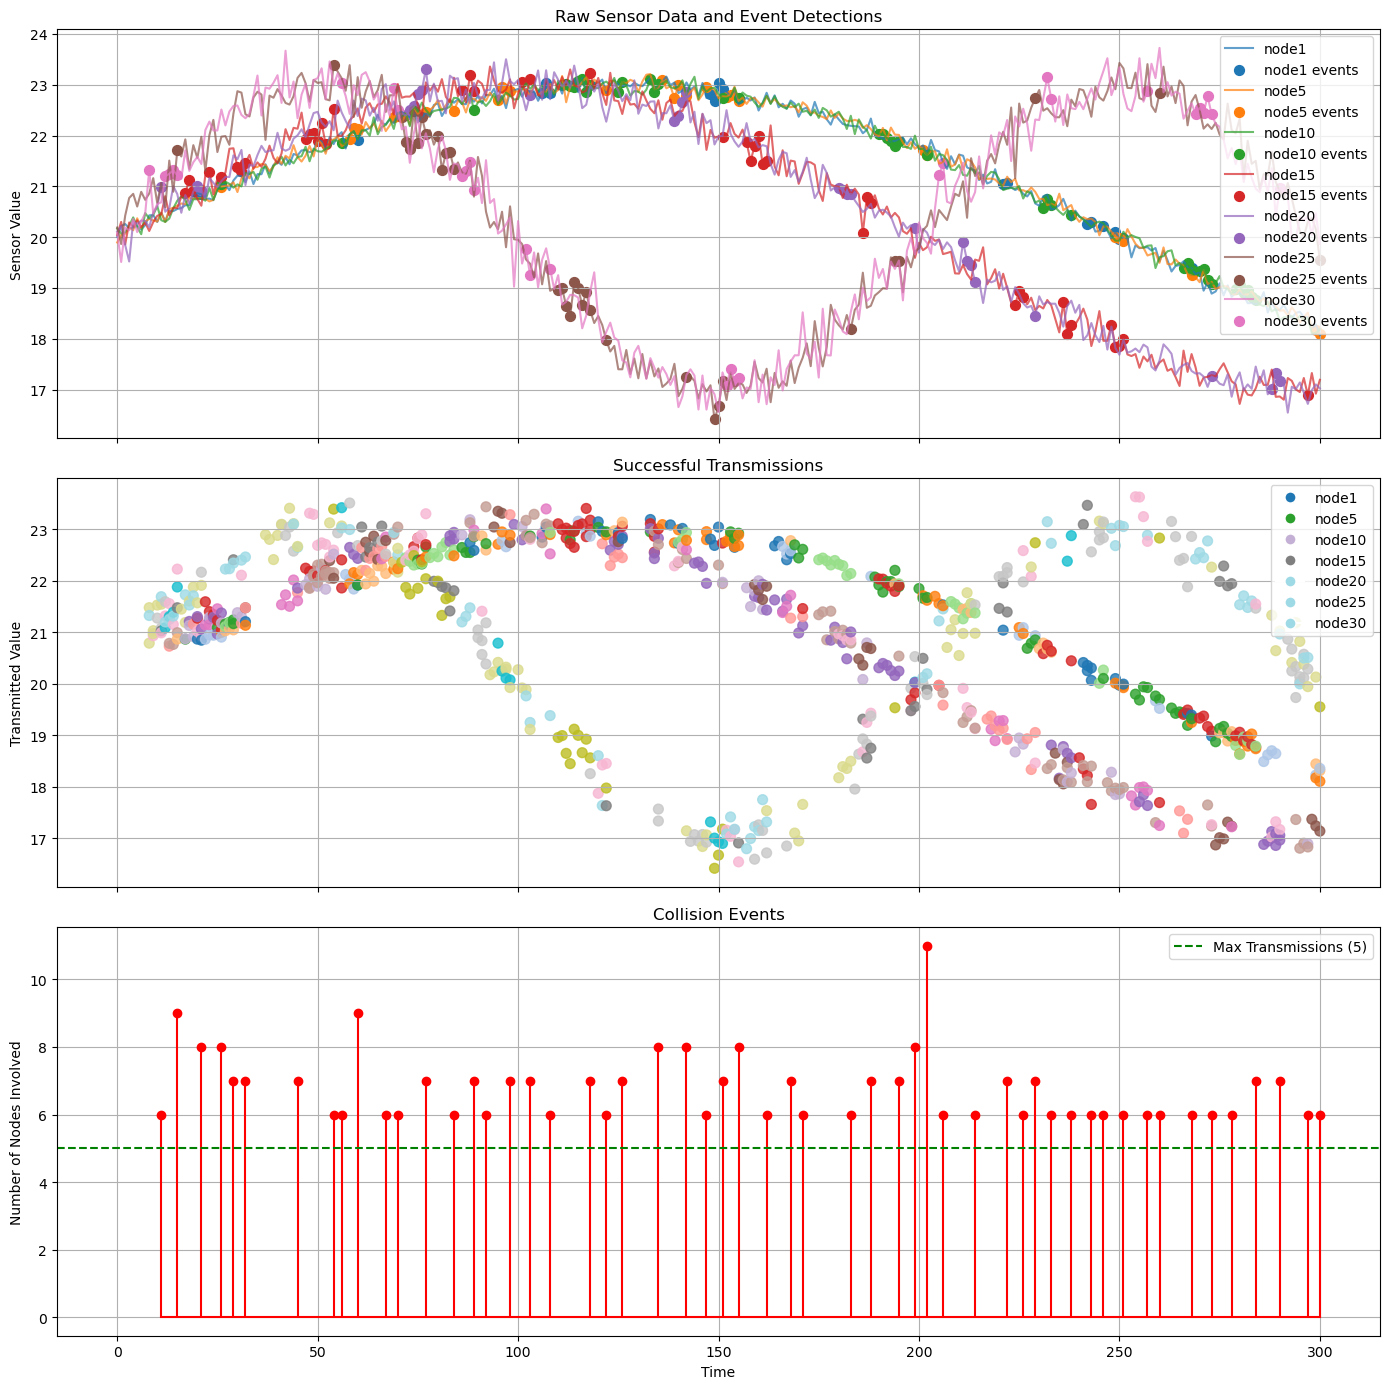

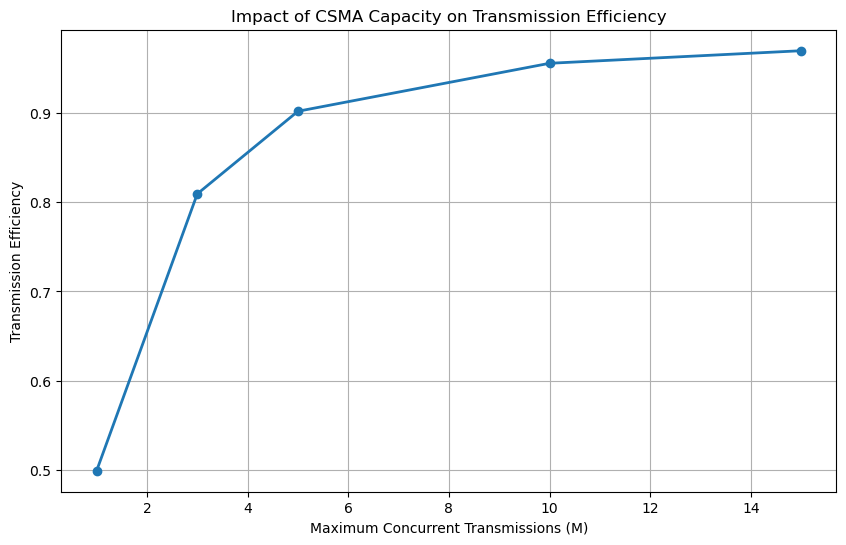

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import List, Dict, Tuple, Optional, Set
import time

# Copy the LinearSIP and CSMANetworkSimulator classes here directly
# No need for an import from a separate module

class LinearSIP:
    """
    Linear State-Informed Prediction (L-SIP) algorithm implementation.
    """
    def __init__(self, alpha: float = 0.3, beta: float = 0.1, threshold: float = 0.1):
        # Parameters
        self.alpha = alpha
        self.beta = beta
        self.threshold = threshold
        
        # State variables
        self.x1 = 0.0  # Value estimate
        self.x2 = 0.0  # Rate of change estimate
        self.last_time = None  # Last update time
        self.sink_time = None  # Last sink time
        self.sink_value = None  # Last sink value (y_sink)
        self.eventful = False  # Event detection flag
        
        # History for debugging/analysis
        self.history = []
    
    def update(self, z: float, current_time: float, 
               sink_time: Optional[float] = None, 
               sink_value: Optional[float] = None) -> Dict:
        """
        Update the state estimates and perform prediction.
        """
        # Initialize if this is the first update
        if self.last_time is None:
            self.last_time = current_time
            self.x1 = z
            self.x2 = 0.0
            
            if sink_time is not None and sink_value is not None:
                self.sink_time = sink_time
                self.sink_value = sink_value
            else:
                self.sink_time = current_time
                self.sink_value = z
                
            return self._create_result(z, prediction=z, is_eventful=False)
        
        # Calculate time interval
        dt = current_time - self.last_time
        if dt <= 0:
            dt = 0.001  # Avoid division by zero
        
        # Update sink state if provided
        if sink_time is not None and sink_value is not None:
            self.sink_time = sink_time
            self.sink_value = sink_value
        
        # dEWMA filtering
        # x1 ← αz + (1 − α)(x1 + x2t)
        predicted_x1 = self.x1 + self.x2 * dt
        self.x1 = self.alpha * z + (1 - self.alpha) * predicted_x1
        
        # x2 ← β(x1 − x1_prev)/t + (1 − β)x2
        x1_prev = predicted_x1
        self.x2 = self.beta * (self.x1 - x1_prev) / dt + (1 - self.beta) * self.x2
        
        # Predict sink state (linear extrapolation)
        if self.sink_time is not None:
            dt_to_sink = self.sink_time - current_time
            y1_predicted = self.x1 + self.x2 * dt_to_sink
        else:
            y1_predicted = self.x1  # No extrapolation if sink time not available
        
        # Simplify (in this case, no simplification per the algorithm description)
        y1 = self.x1
        
        # Event detection
        self.eventful = abs(y1_predicted - y1) > self.threshold
        
        # Update last time
        self.last_time = current_time
        
        # Create and store result
        result = self._create_result(z, prediction=y1_predicted, is_eventful=self.eventful)
        self.history.append(result)
        
        return result
    
    def _create_result(self, measurement: float, prediction: float, is_eventful: bool) -> Dict:
        """Create a dictionary with the current algorithm state and results."""
        return {
            "time": self.last_time,
            "measurement": measurement,
            "x1": self.x1,  # Value estimate
            "x2": self.x2,  # Rate of change estimate
            "prediction": prediction,
            "eventful": is_eventful,
            "threshold": self.threshold,
            "sink_time": self.sink_time,
            "sink_value": self.sink_value
        }
    
    def reset(self):
        """Reset the algorithm state."""
        self.x1 = 0.0
        self.x2 = 0.0
        self.last_time = None
        self.sink_time = None
        self.sink_value = None
        self.eventful = False
        self.history = []


class CSMANetworkSimulator:
    """
    Simulates a network of sensors using CSMA-like protocol for transmissions
    where only M out of N sensors can transmit at a given time.
    """
    def __init__(self, 
                 data: pd.DataFrame, 
                 time_column: str,
                 node_columns: List[str],
                 max_transmissions: int,
                 backoff_min: int = 1,
                 backoff_max: int = 5,
                 alpha: float = 0.3,
                 beta: float = 0.1,
                 threshold: float = 0.5):
        """
        Initialize the CSMA network simulator.
        
        Args:
            data: DataFrame containing sensor data
            time_column: Column name for time values
            node_columns: List of column names for node data
            max_transmissions: Maximum number of concurrent transmissions (M)
            backoff_min: Minimum backoff time (in time steps)
            backoff_max: Maximum backoff time (in time steps)
            alpha: Smoothing factor for L-SIP algorithm
            beta: Smoothing factor for rate of change in L-SIP
            threshold: Event detection threshold for L-SIP
        """
        self.data = data
        self.time_column = time_column
        self.node_columns = node_columns
        self.max_transmissions = max_transmissions
        self.backoff_min = backoff_min
        self.backoff_max = backoff_max
        
        # Create L-SIP instances for each node
        self.lsip_instances = {
            node: LinearSIP(alpha=alpha, beta=beta, threshold=threshold)
            for node in node_columns
        }
        
        # Track backoff times for each node
        self.backoff_counters = {node: 0 for node in node_columns}
        
        # Results storage
        self.transmission_history = []
        self.collision_history = []
        self.event_history = {node: [] for node in node_columns}
        
        # Transmission counters
        self.total_events = 0
        self.successful_transmissions = 0
        self.collisions = 0
        
        # Simulation statistics
        self.simulation_stats = {}
    
    def run_simulation(self):
        """Run the simulation through all time steps."""
        time_values = self.data[self.time_column].values
        
        for i, current_time in enumerate(time_values):
            # Get sensor readings for this time step
            readings = {node: self.data[node].iloc[i] for node in self.node_columns}
            
            # Process each node with L-SIP and gather events
            events_detected = []
            
            for node, reading in readings.items():
                # Skip if node is in backoff
                if self.backoff_counters[node] > 0:
                    self.backoff_counters[node] -= 1
                    continue
                
                # Update L-SIP
                result = self.lsip_instances[node].update(reading, current_time)
                
                # If eventful, add to events detected
                if result["eventful"]:
                    events_detected.append(node)
                    self.event_history[node].append((current_time, reading))
                    self.total_events += 1
            
            # CSMA protocol implementation
            if events_detected:
                # If events <= max_transmissions, all can transmit
                if len(events_detected) <= self.max_transmissions:
                    for node in events_detected:
                        self.transmission_history.append((current_time, node, readings[node]))
                    self.successful_transmissions += len(events_detected)
                else:
                    # Collision occurred - more events than allowed transmissions
                    self.collisions += 1
                    self.collision_history.append((current_time, len(events_detected)))
                    
                    # Randomly select M out of N events to transmit (prioritization)
                    transmitting_nodes = random.sample(events_detected, self.max_transmissions)
                    
                    # Process successful transmissions
                    for node in transmitting_nodes:
                        self.transmission_history.append((current_time, node, readings[node]))
                    self.successful_transmissions += len(transmitting_nodes)
                    
                    # Apply backoff to all nodes involved in collision
                    for node in events_detected:
                        # Apply exponential backoff (more collisions = longer wait)
                        collision_count = sum(1 for t, count in self.collision_history 
                                             if t >= current_time - 10 and node in events_detected)
                        max_backoff = min(self.backoff_max * (2 ** min(collision_count, 3)), 50)
                        self.backoff_counters[node] = random.randint(self.backoff_min, max_backoff)
        
        # Compile simulation statistics
        self.simulation_stats = {
            "total_time_steps": len(time_values),
            "total_events_detected": self.total_events,
            "successful_transmissions": self.successful_transmissions,
            "collisions": self.collisions,
            "transmission_efficiency": self.successful_transmissions / max(1, self.total_events),
            "events_per_node": {node: len(events) for node, events in self.event_history.items()},
            "transmission_count_per_node": self.count_transmissions_per_node()
        }
    
    def count_transmissions_per_node(self):
        """Count the number of successful transmissions per node."""
        counts = {node: 0 for node in self.node_columns}
        for _, node, _ in self.transmission_history:
            counts[node] += 1
        return counts
    
    def visualize_results(self, sample_nodes=None, time_range=None):
        """
        Visualize the simulation results.
        
        Args:
            sample_nodes: List of nodes to visualize (default: first 5 nodes)
            time_range: Tuple of (start, end) time values to visualize
            
        Returns:
            Dictionary with simulation statistics
        """
        if sample_nodes is None:
            sample_nodes = self.node_columns[:5]
        
        # Filter data based on time range
        data_to_plot = self.data
        if time_range is not None:
            start, end = time_range
            data_to_plot = self.data[(self.data[self.time_column] >= start) & 
                                     (self.data[self.time_column] <= end)]
        
        # Create figure with multiple subplots
        fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
        
        # 1. Raw data and event detections
        for node in sample_nodes:
            axes[0].plot(data_to_plot[self.time_column], data_to_plot[node], 
                         label=node, alpha=0.7)
            
            # Add markers for events
            events = [(t, v) for t, v in self.event_history[node] 
                     if time_range is None or (t >= time_range[0] and t <= time_range[1])]
            if events:
                event_times, event_values = zip(*events)
                axes[0].scatter(event_times, event_values, marker='o', s=50, 
                               label=f"{node} events")
        
        axes[0].set_title("Raw Sensor Data and Event Detections")
        axes[0].set_ylabel("Sensor Value")
        axes[0].legend(loc='upper right')
        axes[0].grid(True)
        
        # 2. Successful transmissions
        transmission_data = [(t, node, v) for t, node, v in self.transmission_history 
                            if time_range is None or (t >= time_range[0] and t <= time_range[1])]
        
        if transmission_data:
            trans_times, trans_nodes, trans_values = zip(*transmission_data)
            
            # Create a categorical colormap for nodes
            node_to_idx = {node: i for i, node in enumerate(self.node_columns)}
            colors = [node_to_idx[node] for node in trans_nodes]
            
            scatter = axes[1].scatter(trans_times, trans_values, c=colors, cmap='tab20', 
                                     s=50, alpha=0.8)
            
            # Add legend for node colors (but limit to sample nodes to avoid clutter)
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab20(node_to_idx[node]/20), 
                      label=node, markersize=8)
                for node in sample_nodes
            ]
            axes[1].legend(handles=legend_elements, loc='upper right')
        
        axes[1].set_title("Successful Transmissions")
        axes[1].set_ylabel("Transmitted Value")
        axes[1].grid(True)
        
        # 3. Collision events over time
        collision_data = [(t, count) for t, count in self.collision_history 
                         if time_range is None or (t >= time_range[0] and t <= time_range[1])]
        
        if collision_data:
            coll_times, coll_counts = zip(*collision_data)
            axes[2].stem(coll_times, coll_counts, linefmt='r-', markerfmt='ro', basefmt='r-')
            
            # Add a line for max_transmissions
            axes[2].axhline(y=self.max_transmissions, color='g', linestyle='--', 
                           label=f'Max Transmissions ({self.max_transmissions})')
        
        axes[2].set_title("Collision Events")
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("Number of Nodes Involved")
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        
        # Additional plot: Transmission count per node
        plt.figure(figsize=(12, 6))
        counts = self.simulation_stats["transmission_count_per_node"]
        nodes = list(counts.keys())
        values = list(counts.values())
        
        # Sort by transmission count
        sorted_indices = np.argsort(values)[::-1]
        sorted_nodes = [nodes[i] for i in sorted_indices]
        sorted_values = [values[i] for i in sorted_indices]
        
        # Plot only top 30 nodes for clarity if there are many
        top_n = min(30, len(sorted_nodes))
        plt.bar(range(top_n), sorted_values[:top_n])
        plt.xticks(range(top_n), sorted_nodes[:top_n], rotation=90)
        plt.title("Top Nodes by Successful Transmissions")
        plt.xlabel("Node")
        plt.ylabel("Transmissions")
        plt.tight_layout()
        
        return self.simulation_stats
    
    def print_stats(self):
        """Print simulation statistics to console."""
        print("\n=== CSMA Network Simulation Results ===")
        print(f"Total time steps: {self.simulation_stats['total_time_steps']}")
        print(f"Total events detected: {self.simulation_stats['total_events_detected']}")
        print(f"Successful transmissions: {self.simulation_stats['successful_transmissions']}")
        print(f"Collisions: {self.simulation_stats['collisions']}")
        print(f"Transmission efficiency: {self.simulation_stats['transmission_efficiency']:.2f}")
        
        print("\nTop 5 most active nodes (by events detected):")
        events_per_node = self.simulation_stats["events_per_node"]
        sorted_events = sorted(events_per_node.items(), key=lambda x: x[1], reverse=True)
        for node, count in sorted_events[:5]:
            print(f"  {node}: {count} events detected")
        
        print("\nTop 5 most active nodes (by successful transmissions):")
        trans_per_node = self.simulation_stats["transmission_count_per_node"]
        sorted_trans = sorted(trans_per_node.items(), key=lambda x: x[1], reverse=True)
        for node, count in sorted_trans[:5]:
            print(f"  {node}: {count} successful transmissions")


# Main script - this is the actual usage example
if __name__ == "__main__":
    # Step 1: Load the dataset as in your example
    pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Step 2: Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")

    # Step 3: Set simulation parameters
    M = 5  # Maximum concurrent transmissions allowed
    alpha = 0.3  # L-SIP value smoothing parameter
    beta = 0.15  # L-SIP rate of change smoothing parameter
    threshold = 0.5  # Event detection threshold

    # Step 4: Create and run the CSMA simulator
    simulator = CSMANetworkSimulator(
        data=pivot_df,
        time_column=time_column,
        node_columns=node_columns,
        max_transmissions=M,
        backoff_min=1,
        backoff_max=10,
        alpha=alpha,
        beta=beta,
        threshold=threshold
    )

    print("Running simulation...")
    simulator.run_simulation()

    # Step 5: Analyze results
    simulator.print_stats()

    # Step 6: Generate visualizations
    # Create visualization for a subset of nodes
    sample_nodes = ['node1', 'node5', 'node10', 'node15', 'node20', 'node25', 'node30']
    simulator.visualize_results(sample_nodes=sample_nodes, time_range=(0, 300))
    plt.savefig('csma_simulation_results.png', dpi=300)
    plt.close()

    # Step 7: Optional - Compare different M values
    # This can be used to find the optimal M for your network
    print("\nTesting different values of M (max concurrent transmissions)...")
    M_values = [1, 3, 5, 10, 15]
    efficiencies = []

    for test_m in M_values:
        test_sim = CSMANetworkSimulator(
            data=pivot_df.iloc[:500],  # Use subset for faster testing
            time_column=time_column,
            node_columns=node_columns,
            max_transmissions=test_m,
            alpha=alpha,
            beta=beta,
            threshold=threshold
        )
        test_sim.run_simulation()
        efficiency = test_sim.successful_transmissions / max(1, test_sim.total_events)
        efficiencies.append(efficiency)
        print(f"M={test_m}: Efficiency={efficiency:.3f}, Collisions={test_sim.collisions}")

    # Plot efficiency vs M
    plt.figure(figsize=(10, 6))
    plt.plot(M_values, efficiencies, 'o-', linewidth=2)
    plt.xlabel('Maximum Concurrent Transmissions (M)')
    plt.ylabel('Transmission Efficiency')
    plt.title('Impact of CSMA Capacity on Transmission Efficiency')
    plt.grid(True)
    plt.savefig('efficiency_vs_capacity.png')

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import List, Dict, Tuple, Optional, Set
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error


class LinearSIP:
    """
    Linear State-Informed Prediction (L-SIP) algorithm implementation.
    """
    def __init__(self, alpha: float = 0.1, beta: float = 0.01, threshold: float = 0.5):
        # Parameters
        self.alpha = alpha
        self.beta = beta
        self.threshold = threshold
        
        # State variables
        self.x1 = 0.0  # Value estimate
        self.x2 = 0.0  # Rate of change estimate
        self.last_time = None  # Last update time
        self.sink_time = None  # Last sink time
        self.sink_value = None  # Last sink value (y_sink)
        self.eventful = False  # Event detection flag
        
        # History for debugging/analysis
        self.history = []
    
    def update(self, z: float, current_time: float, 
               sink_time: Optional[float] = None, 
               sink_value: Optional[float] = None) -> Dict:
        """
        Update the state estimates and perform prediction.
        """
        # Initialize if this is the first update
        if self.last_time is None:
            self.last_time = current_time
            self.x1 = z
            self.x2 = 0.0
            
            if sink_time is not None and sink_value is not None:
                self.sink_time = sink_time
                self.sink_value = sink_value
            else:
                self.sink_time = current_time
                self.sink_value = z
                
            return self._create_result(z, prediction=z, is_eventful=False)
        
        # Calculate time interval
        dt = current_time - self.last_time
        if dt <= 0:
            dt = 0.001  # Avoid division by zero
        
        # Update sink state if provided
        if sink_time is not None and sink_value is not None:
            self.sink_time = sink_time
            self.sink_value = sink_value
        
        # dEWMA filtering
        # x1 ← αz + (1 − α)(x1 + x2t)
        predicted_x1 = self.x1 + self.x2 * dt
        self.x1 = self.alpha * z + (1 - self.alpha) * predicted_x1
        
        # x2 ← β(x1 − x1_prev)/t + (1 − β)x2
        x1_prev = predicted_x1
        self.x2 = self.beta * (self.x1 - x1_prev) / dt + (1 - self.beta) * self.x2
        
        # Predict sink state (linear extrapolation)
        if self.sink_time is not None:
            dt_to_sink = self.sink_time - current_time
            y1_predicted = self.x1 + self.x2 * dt_to_sink
        else:
            y1_predicted = self.x1  # No extrapolation if sink time not available
        
        # Simplify (in this case, no simplification per the algorithm description)
        y1 = self.x1
        
        # Event detection
        self.eventful = abs(y1_predicted - y1) > self.threshold
        
        # Update last time
        self.last_time = current_time
        
        # Create and store result
        result = self._create_result(z, prediction=y1_predicted, is_eventful=self.eventful)
        self.history.append(result)
        
        return result
    
    def _create_result(self, measurement: float, prediction: float, is_eventful: bool) -> Dict:
        """Create a dictionary with the current algorithm state and results."""
        return {
            "time": self.last_time,
            "measurement": measurement,
            "x1": self.x1,  # Value estimate
            "x2": self.x2,  # Rate of change estimate
            "prediction": prediction,
            "eventful": is_eventful,
            "threshold": self.threshold,
            "sink_time": self.sink_time,
            "sink_value": self.sink_value
        }
    
    def reset(self):
        """Reset the algorithm state."""
        self.x1 = 0.0
        self.x2 = 0.0
        self.last_time = None
        self.sink_time = None
        self.sink_value = None
        self.eventful = False
        self.history = []


class CSMANetworkSimulator:
    """
    Simulates a network of sensors using CSMA-like protocol for transmissions
    where only M out of N sensors can transmit at a given time.
    """
    def __init__(self, 
                 data: pd.DataFrame, 
                 time_column: str,
                 node_columns: List[str],
                 max_transmissions: int = 5,
                 backoff_min: int = 1,
                 backoff_max: int = 5,
                 alpha: float = 0.3,
                 beta: float = 0.1,
                 threshold: float = 0.5):
        """
        Initialize the CSMA network simulator.
        
        Args:
            data: DataFrame containing sensor data
            time_column: Column name for time values
            node_columns: List of column names for node data
            max_transmissions: Maximum number of concurrent transmissions (M)
            backoff_min: Minimum backoff time (in time steps)
            backoff_max: Maximum backoff time (in time steps)
            alpha: Smoothing factor for L-SIP algorithm
            beta: Smoothing factor for rate of change in L-SIP
            threshold: Event detection threshold for L-SIP
        """
        self.data = data
        self.time_column = time_column
        self.node_columns = node_columns
        self.max_transmissions = max_transmissions
        self.backoff_min = backoff_min
        self.backoff_max = backoff_max
        
        # Create L-SIP instances for each node
        self.lsip_instances = {
            node: LinearSIP(alpha=alpha, beta=beta, threshold=threshold)
            for node in node_columns
        }
        
        # Track backoff times for each node
        self.backoff_counters = {node: 0 for node in node_columns}
        
        # Results storage
        self.transmission_history = []
        self.collision_history = []
        self.event_history = {node: [] for node in node_columns}
        
        # Reconstruction data
        self.reconstructed_values = {node: [] for node in node_columns}
        self.reconstruction_times = {node: [] for node in node_columns}
        
        # Transmission counters
        self.total_events = 0
        self.successful_transmissions = 0
        self.collisions = 0
        
        # Simulation statistics
        self.simulation_stats = {}
    
    def run_simulation(self):
        """Run the simulation through all time steps."""
        time_values = self.data[self.time_column].values
        num_time_steps = len(time_values)
        
        # Initialize reconstruction with first values
        for node in self.node_columns:
            self.reconstructed_values[node] = [self.data[node].iloc[0]] * num_time_steps
            self.reconstruction_times[node] = [time_values[0]]
        
        for i, current_time in enumerate(time_values):
            # Get sensor readings for this time step
            readings = {node: self.data[node].iloc[i] for node in self.node_columns}
            
            # Process each node with L-SIP and gather events
            events_detected = []
            
            for node, reading in readings.items():
                # Skip if node is in backoff
                if self.backoff_counters[node] > 0:
                    self.backoff_counters[node] -= 1
                    continue
                
                # Update L-SIP
                result = self.lsip_instances[node].update(reading, current_time)
                
                # If eventful, add to events detected
                if result["eventful"]:
                    events_detected.append(node)
                    self.event_history[node].append((current_time, reading))
                    self.total_events += 1
            
            # CSMA protocol implementation
            if events_detected:
                # If events <= max_transmissions, all can transmit
                if len(events_detected) <= self.max_transmissions:
                    for node in events_detected:
                        self._process_transmission(current_time, node, readings[node])
                else:
                    # Collision occurred - more events than allowed transmissions
                    self.collisions += 1
                    self.collision_history.append((current_time, len(events_detected)))
                    
                    # Randomly select M out of N events to transmit (prioritization)
                    transmitting_nodes = random.sample(events_detected, self.max_transmissions)
                    
                    # Process successful transmissions
                    for node in transmitting_nodes:
                        self._process_transmission(current_time, node, readings[node])
                    
                    # Apply backoff to all nodes involved in collision
                    for node in events_detected:
                        # Apply exponential backoff (more collisions = longer wait)
                        collision_count = sum(1 for t, count in self.collision_history 
                                             if t >= current_time - 10 and node in events_detected)
                        max_backoff = min(self.backoff_max * (2 ** min(collision_count, 3)), 50)
                        self.backoff_counters[node] = random.randint(self.backoff_min, max_backoff)
            
            # Update reconstructed values for this time step
            for node in self.node_columns:
                # Keep track of last transmitted value
                if i > 0:
                    # Use the previous reconstruction if no new transmission
                    self.reconstructed_values[node][i] = self.reconstructed_values[node][i-1]
        
        # Calculate reconstruction error
        self._calculate_reconstruction_error()
    
    def _process_transmission(self, time_val, node, value):
        """Process a successful transmission and update reconstruction."""
        self.transmission_history.append((time_val, node, value))
        self.successful_transmissions += 1
        
        # Update reconstructed value at current time
        time_idx = np.where(self.data[self.time_column].values == time_val)[0][0]
        self.reconstructed_values[node][time_idx] = value
        self.reconstruction_times[node].append(time_val)
    
    def _calculate_reconstruction_error(self):
        """Calculate reconstruction error metrics."""
        # Prepare containers for error metrics
        mse_per_node = {}
        mae_per_node = {}
        max_error_per_node = {}
        
        # Calculate error per node
        for node in self.node_columns:
            actual = self.data[node].values
            reconstructed = np.array(self.reconstructed_values[node])
            
            # Calculate error metrics
            mse_per_node[node] = mean_squared_error(actual, reconstructed)
            mae_per_node[node] = mean_absolute_error(actual, reconstructed)
            max_error_per_node[node] = np.max(np.abs(actual - reconstructed))
        
        # Overall errors
        all_actual = np.concatenate([self.data[node].values for node in self.node_columns])
        all_reconstructed = np.concatenate([self.reconstructed_values[node] for node in self.node_columns])
        
        overall_mse = mean_squared_error(all_actual, all_reconstructed)
        overall_mae = mean_absolute_error(all_actual, all_reconstructed)
        overall_max_error = np.max(np.abs(all_actual - all_reconstructed))
        
        # Store error metrics in simulation stats
        self.reconstruction_error = {
            "per_node": {
                "mse": mse_per_node,
                "mae": mae_per_node,
                "max_error": max_error_per_node
            },
            "overall": {
                "mse": overall_mse,
                "mae": overall_mae,
                "max_error": overall_max_error
            }
        }
        
        # Compile simulation statistics
        self.simulation_stats = {
            "total_time_steps": len(self.data),
            "total_events_detected": self.total_events,
            "successful_transmissions": self.successful_transmissions,
            "collisions": self.collisions,
            "transmission_efficiency": self.successful_transmissions / max(1, self.total_events),
            "events_per_node": {node: len(events) for node, events in self.event_history.items()},
            "transmission_count_per_node": self.count_transmissions_per_node(),
            "reconstruction_error": self.reconstruction_error
        }
    
    def count_transmissions_per_node(self):
        """Count the number of successful transmissions per node."""
        counts = {node: 0 for node in self.node_columns}
        for _, node, _ in self.transmission_history:
            counts[node] += 1
        return counts
    
    def visualize_reconstruction(self, sample_nodes=None, time_range=None):
        """
        Visualize the reconstruction error.
        
        Args:
            sample_nodes: List of nodes to visualize (default: first 5 nodes)
            time_range: Tuple of (start, end) time values to visualize
        """
        if sample_nodes is None:
            sample_nodes = self.node_columns[:5]
        
        # Filter data based on time range
        time_values = self.data[self.time_column].values
        if time_range is not None:
            start, end = time_range
            mask = (time_values >= start) & (time_values <= end)
            time_values = time_values[mask]
        else:
            mask = np.ones(len(time_values), dtype=bool)
        
        # Create multi-panel figure
        fig, axes = plt.subplots(len(sample_nodes), 1, figsize=(14, 4*len(sample_nodes)), sharex=True)
        
        # If only one node is selected, axes is not an array
        if len(sample_nodes) == 1:
            axes = [axes]
        
        # Plot each node's actual vs reconstructed data
        for i, node in enumerate(sample_nodes):
            actual = self.data[node].values[mask]
            reconstructed = np.array(self.reconstructed_values[node])[mask]
            
            # Plot actual values
            axes[i].plot(time_values, actual, 'b-', label='Actual', linewidth=2, alpha=0.7)
            
            # Plot reconstructed values
            axes[i].plot(time_values, reconstructed, 'r--', label='Reconstructed', linewidth=2)
            
            # Add markers for transmissions
            trans_times = []
            trans_values = []
            for t, n, v in self.transmission_history:
                if n == node and (time_range is None or (t >= start and t <= end)):
                    trans_times.append(t)
                    trans_values.append(v)
            
            if trans_times:
                axes[i].scatter(trans_times, trans_values, color='g', s=50, 
                               label='Transmissions', zorder=3)
            
            # Calculate and show error for this node
            node_mse = self.reconstruction_error["per_node"]["mse"][node]
            node_mae = self.reconstruction_error["per_node"]["mae"][node]
            
            axes[i].set_title(f"{node}: MSE={node_mse:.4f}, MAE={node_mae:.4f}")
            axes[i].set_ylabel("Value")
            axes[i].legend(loc='upper right')
            axes[i].grid(True)
        
        # Add overall title and adjust layout
        plt.xlabel("Time")
        plt.suptitle("Actual vs Reconstructed Sensor Data", fontsize=16)
        plt.tight_layout()
        
        # Create error heatmap
        plt.figure(figsize=(12, 8))
        
        # Extract MSE values
        mse_values = [self.reconstruction_error["per_node"]["mse"][node] for node in self.node_columns]
        cmap = plt.cm.YlOrRd
        
        # Create sorted bar chart of MSE values
        sorted_indices = np.argsort(mse_values)
        sorted_nodes = [self.node_columns[i] for i in sorted_indices]
        sorted_mse = [mse_values[i] for i in sorted_indices]
        
        # Plot bars
        bars = plt.bar(range(len(sorted_nodes)), sorted_mse, color=cmap(np.array(sorted_mse)/max(sorted_mse)))
        
        # Format plot
        plt.xticks(range(len(sorted_nodes)), sorted_nodes, rotation=90)
        plt.ylabel("Mean Squared Error (MSE)")
        plt.title("Reconstruction Error by Node")
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Normalized Error")
        plt.tight_layout()
        
        # Create a plot showing relationship between transmissions and error
        plt.figure(figsize=(10, 8))
        
        # Get transmission counts
        trans_counts = list(self.simulation_stats["transmission_count_per_node"].values())
        
        # Scatter plot of transmission count vs MSE
        plt.scatter(trans_counts, mse_values, alpha=0.7, s=80, c=range(len(mse_values)), cmap='viridis')
        
        # Add node labels to points
        for i, node in enumerate(self.node_columns):
            plt.annotate(node, (trans_counts[i], mse_values[i]), fontsize=8)
        
        # Add trend line
        z = np.polyfit(trans_counts, mse_values, 1)
        p = np.poly1d(z)
        plt.plot(np.unique(trans_counts), p(np.unique(trans_counts)), "r--", alpha=0.7)
        
        plt.xlabel("Number of Transmissions")
        plt.ylabel("Reconstruction Error (MSE)")
        plt.title("Relationship Between Transmission Count and Reconstruction Error")
        plt.grid(True)
        plt.tight_layout()
    
    def print_reconstruction_stats(self):
        """Print reconstruction error statistics."""
        print("\n=== Reconstruction Error Statistics ===")
        print(f"Overall MSE: {self.reconstruction_error['overall']['mse']:.6f}")
        print(f"Overall MAE: {self.reconstruction_error['overall']['mae']:.6f}")
        print(f"Overall Maximum Error: {self.reconstruction_error['overall']['max_error']:.6f}")
        
        print("\nTop 5 nodes with highest reconstruction error (MSE):")
        mse_per_node = self.reconstruction_error["per_node"]["mse"]
        sorted_mse = sorted(mse_per_node.items(), key=lambda x: x[1], reverse=True)
        for node, mse in sorted_mse[:5]:
            transmissions = self.simulation_stats["transmission_count_per_node"][node]
            print(f"  {node}: MSE={mse:.6f}, Transmissions={transmissions}")
        
        print("\nTop 5 nodes with lowest reconstruction error (MSE):")
        for node, mse in sorted_mse[-5:]:
            transmissions = self.simulation_stats["transmission_count_per_node"][node]
            print(f"  {node}: MSE={mse:.6f}, Transmissions={transmissions}")
        
        # Calculate compression ratio
        total_possible = len(self.data) * len(self.node_columns)
        total_transmissions = self.successful_transmissions
        compression_ratio = 1 - (total_transmissions / total_possible)
        
        print(f"\nCompression ratio: {compression_ratio:.2%}")
        print(f"  (Transmitted {total_transmissions} values out of {total_possible} possible)")


# Main script - this is the actual usage example
if __name__ == "__main__":
    # Load the dataset
    pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")

    # Set fixed parameters for the simulation (as requested)
    M = 5  # Fixed maximum concurrent transmissions
    threshold = 0.5  # Fixed event detection threshold
    
    # Create and run the CSMA simulator
    simulator = CSMANetworkSimulator(
        data=pivot_df,
        time_column=time_column,
        node_columns=node_columns,
        max_transmissions=M,
        backoff_min=1,
        backoff_max=10,
        alpha=0.1,
        beta=0.01,
        threshold=threshold
    )

    print(f"Running simulation with fixed parameters: M={M}, threshold={threshold}...")
    start_time = time.time()
    simulator.run_simulation()
    elapsed = time.time() - start_time
    print(f"Simulation completed in {elapsed:.2f} seconds")

    # Print reconstruction statistics
    simulator.print_reconstruction_stats()

    # Visualize reconstruction for sample nodes
    sample_nodes = ['node1', 'node5', 'node10', 'node15', 'node20', 'node25', 'node30']
    print("Generating reconstruction visualizations...")
    simulator.visualize_reconstruction(sample_nodes=sample_nodes, time_range=(0, 300))
    plt.savefig('reconstruction_comparison.png', dpi=300)
    plt.close()
    
    plt.savefig('error_by_node.png', dpi=300)
    plt.close()
    
    plt.savefig('error_vs_transmissions.png', dpi=300)
    plt.close()
    
    print("Visualization completed. Results saved as PNG files.")

Dataset loaded with shape: (50000, 31)
Found 30 node columns
Running simulation with fixed parameters: M=5, threshold=0.5...
Simulation completed in 26.94 seconds

=== Reconstruction Error Statistics ===
Overall MSE: 4.589457
Overall MAE: 1.919371
Overall Maximum Error: 4.564199

Top 5 nodes with highest reconstruction error (MSE):
  node14: MSE=4.805785, Transmissions=5192
  node23: MSE=4.731181, Transmissions=5465
  node26: MSE=4.678660, Transmissions=5280
  node11: MSE=4.661795, Transmissions=5242
  node22: MSE=4.657533, Transmissions=5223

Top 5 nodes with lowest reconstruction error (MSE):
  node6: MSE=4.519992, Transmissions=5363
  node2: MSE=4.519319, Transmissions=5057
  node3: MSE=4.518361, Transmissions=5334
  node1: MSE=4.509266, Transmissions=5419
  node7: MSE=4.507830, Transmissions=5418

Compression ratio: 89.47%
  (Transmitted 157937 values out of 1500000 possible)
Generating reconstruction visualizations...


C:\Users\jonahs\AppData\Local\Temp\ipykernel_23388\2939923793.py:399: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Normalized Error")


Visualization completed. Results saved as PNG files.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import List, Dict, Tuple, Optional, Set
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.interpolate import CubicSpline


class LinearSIP:
    """
    Linear State-Informed Prediction (L-SIP) algorithm implementation.
    """
    def __init__(self, alpha: float = 0.3, beta: float = 0.1, threshold: float = 0.5):
        # Parameters
        self.alpha = alpha
        self.beta = beta
        self.threshold = threshold
        
        # State variables
        self.x1 = 0.0  # Value estimate
        self.x2 = 0.0  # Rate of change estimate
        self.last_time = None  # Last update time
        self.sink_time = None  # Last sink time
        self.sink_value = None  # Last sink value (y_sink)
        self.eventful = False  # Event detection flag
        
        # History for debugging/analysis
        self.history = []
    
    def update(self, z: float, current_time: float, 
               sink_time: Optional[float] = None, 
               sink_value: Optional[float] = None) -> Dict:
        """
        Update the state estimates and perform prediction.
        """
        # Initialize if this is the first update
        if self.last_time is None:
            self.last_time = current_time
            self.x1 = z
            self.x2 = 0.0
            
            if sink_time is not None and sink_value is not None:
                self.sink_time = sink_time
                self.sink_value = sink_value
            else:
                self.sink_time = current_time
                self.sink_value = z
                
            return self._create_result(z, prediction=z, is_eventful=False)
        
        # Calculate time interval
        dt = current_time - self.last_time
        if dt <= 0:
            dt = 0.001  # Avoid division by zero
        
        # Update sink state if provided
        if sink_time is not None and sink_value is not None:
            self.sink_time = sink_time
            self.sink_value = sink_value
        
        # dEWMA filtering
        # x1 ← αz + (1 − α)(x1 + x2t)
        predicted_x1 = self.x1 + self.x2 * dt
        self.x1 = self.alpha * z + (1 - self.alpha) * predicted_x1
        
        # x2 ← β(x1 − x1_prev)/t + (1 − β)x2
        x1_prev = predicted_x1
        self.x2 = self.beta * (self.x1 - x1_prev) / dt + (1 - self.beta) * self.x2
        
        # Predict sink state (linear extrapolation)
        if self.sink_time is not None:
            dt_to_sink = self.sink_time - current_time
            y1_predicted = self.x1 + self.x2 * dt_to_sink
        else:
            y1_predicted = self.x1  # No extrapolation if sink time not available
        
        # Simplify (in this case, no simplification per the algorithm description)
        y1 = self.x1
        
        # Event detection
        self.eventful = abs(y1_predicted - y1) > self.threshold
        
        # Update last time
        self.last_time = current_time
        
        # Create and store result
        result = self._create_result(z, prediction=y1_predicted, is_eventful=self.eventful)
        self.history.append(result)
        
        return result
    
    def _create_result(self, measurement: float, prediction: float, is_eventful: bool) -> Dict:
        """Create a dictionary with the current algorithm state and results."""
        return {
            "time": self.last_time,
            "measurement": measurement,
            "x1": self.x1,  # Value estimate
            "x2": self.x2,  # Rate of change estimate
            "prediction": prediction,
            "eventful": is_eventful,
            "threshold": self.threshold,
            "sink_time": self.sink_time,
            "sink_value": self.sink_value
        }
    
    def reset(self):
        """Reset the algorithm state."""
        self.x1 = 0.0
        self.x2 = 0.0
        self.last_time = None
        self.sink_time = None
        self.sink_value = None
        self.eventful = False
        self.history = []


class CSMANetworkSimulator:
    """
    Simulates a network of sensors using CSMA-like protocol for transmissions
    where only M out of N sensors can transmit at a given time.
    """
    def __init__(self, 
                 data: pd.DataFrame, 
                 time_column: str,
                 node_columns: List[str],
                 max_transmissions: int = 5,
                 backoff_min: int = 1,
                 backoff_max: int = 5,
                 alpha: float = 0.3,
                 beta: float = 0.1,
                 threshold: float = 0.5):
        """
        Initialize the CSMA network simulator.
        
        Args:
            data: DataFrame containing sensor data
            time_column: Column name for time values
            node_columns: List of column names for node data
            max_transmissions: Maximum number of concurrent transmissions (M)
            backoff_min: Minimum backoff time (in time steps)
            backoff_max: Maximum backoff time (in time steps)
            alpha: Smoothing factor for L-SIP algorithm
            beta: Smoothing factor for rate of change in L-SIP
            threshold: Event detection threshold for L-SIP
        """
        self.data = data
        self.time_column = time_column
        self.node_columns = node_columns
        self.max_transmissions = max_transmissions
        self.backoff_min = backoff_min
        self.backoff_max = backoff_max
        
        # Create L-SIP instances for each node
        self.lsip_instances = {
            node: LinearSIP(alpha=alpha, beta=beta, threshold=threshold)
            for node in node_columns
        }
        
        # Track backoff times for each node
        self.backoff_counters = {node: 0 for node in node_columns}
        
        # Results storage
        self.transmission_history = []
        self.collision_history = []
        self.event_history = {node: [] for node in node_columns}
        
        # Reconstruction data
        self.reconstructed_values = {node: [] for node in node_columns}
        self.reconstruction_times = {node: [] for node in node_columns}
        
        # Transmission counters
        self.total_events = 0
        self.successful_transmissions = 0
        self.collisions = 0
        
        # Simulation statistics
        self.simulation_stats = {}
    
    def run_simulation(self):
        """Run the simulation through all time steps."""
        time_values = self.data[self.time_column].values
        num_time_steps = len(time_values)
        
        # Initialize transmission tracking
        for node in self.node_columns:
            # Will be populated with successful transmissions
            self.reconstruction_times[node] = []
            
        # Initial transmission for each node at time 0
        initial_time = time_values[0]
        for node in self.node_columns:
            initial_value = self.data[node].iloc[0]
            # Initialize L-SIP with first value
            self.lsip_instances[node].update(initial_value, initial_time)
            # Process initial transmission (all nodes send their initial state)
            self._process_transmission(initial_time, node, initial_value)
        
        for i, current_time in enumerate(time_values):
            # Get sensor readings for this time step
            readings = {node: self.data[node].iloc[i] for node in self.node_columns}
            
            # Process each node with L-SIP and gather events
            events_detected = []
            
            for node, reading in readings.items():
                # Skip if node is in backoff
                if self.backoff_counters[node] > 0:
                    self.backoff_counters[node] -= 1
                    continue
                
                # Update L-SIP
                result = self.lsip_instances[node].update(reading, current_time)
                
                # If eventful, add to events detected
                if result["eventful"]:
                    events_detected.append(node)
                    self.event_history[node].append((current_time, reading))
                    self.total_events += 1
            
            # CSMA protocol implementation
            if events_detected:
                # If events <= max_transmissions, all can transmit
                if len(events_detected) <= self.max_transmissions:
                    for node in events_detected:
                        self._process_transmission(current_time, node, readings[node])
                else:
                    # Collision occurred - more events than allowed transmissions
                    self.collisions += 1
                    self.collision_history.append((current_time, len(events_detected)))
                    
                    # Randomly select M out of N events to transmit (prioritization)
                    transmitting_nodes = random.sample(events_detected, self.max_transmissions)
                    
                    # Process successful transmissions
                    for node in transmitting_nodes:
                        self._process_transmission(current_time, node, readings[node])
                    
                    # Apply backoff to all nodes involved in collision
                    for node in events_detected:
                        # Apply exponential backoff (more collisions = longer wait)
                        collision_count = sum(1 for t, count in self.collision_history 
                                             if t >= current_time - 10 and node in events_detected)
                        max_backoff = min(self.backoff_max * (2 ** min(collision_count, 3)), 50)
                        self.backoff_counters[node] = random.randint(self.backoff_min, max_backoff)
            
            # We'll build the full reconstruction after all transmissions are processed
        
        # Calculate reconstruction error
        self._calculate_reconstruction_error()
    
    def _process_transmission(self, time_val, node, value):
        """
        Process a successful transmission and store it for reconstruction.
        
        In L-SIP, a packet contains the smoothed value (x1) and rate of change (x2),
        which will be used for cubic spline reconstruction at the sink.
        """
        # Get the current L-SIP state (smoothed value and rate of change)
        lsip_state = self.lsip_instances[node]
        x1 = lsip_state.x1  # Smoothed value
        x2 = lsip_state.x2  # Rate of change
        
        # Store transmission details including x1 and x2
        self.transmission_history.append((time_val, node, x1, x2))
        self.successful_transmissions += 1
        
        # Track the time of this transmission for this node
        time_index = np.where(self.data[self.time_column].values == time_val)[0][0]
        self.reconstruction_times[node].append((time_index, x1, x2))
    
    def _calculate_reconstruction_error(self):
        """
        Calculate reconstruction error metrics using cubic spline reconstruction.
        
        The reconstruction uses only the successfully transmitted points (x1, x2)
        to create a cubic spline, which is compared with the original signal.
        """
        # Prepare space for reconstructed values
        time_values = self.data[self.time_column].values
        all_time_indices = np.arange(len(time_values))
        
        # Initialize storage for reconstructed signals
        for node in self.node_columns:
            self.reconstructed_values[node] = np.zeros(len(time_values))
        
        # Storage for reconstruction details
        reconstruction_results = {}
        
        # Process each node to create cubic spline reconstruction
        for node in self.node_columns:
            # Get the transmission points for this node
            transmission_points = self.reconstruction_times[node]
            
            if len(transmission_points) < 4:  # Cubic spline needs at least 4 points for good results
                print(f"Warning: Node {node} has only {len(transmission_points)} transmissions - cubic spline may not be accurate")
            
            # Extract time indices and values for spline construction
            if transmission_points:
                time_indices, values, rates = zip(*transmission_points)
                time_indices = np.array(time_indices)
                values = np.array(values)
                
                try:
                    # Create cubic spline using only the transmitted points (x1 values)
                    cs = CubicSpline(time_indices, values)
                    
                    # Reconstruct the full signal using the spline
                    self.reconstructed_values[node] = cs(all_time_indices)
                    
                    # Store reconstruction data for visualization
                    reconstruction_results[node] = {
                        'time_indices': time_indices,
                        'values': values,
                        'rates': rates
                    }
                except Exception as e:
                    print(f"Error creating cubic spline for {node}: {e}")
                    # Fall back to simpler interpolation if cubic spline fails
                    if len(transmission_points) >= 2:
                        try:
                            # Try linear interpolation as fallback
                            from scipy.interpolate import interp1d
                            linear_interp = interp1d(time_indices, values, 
                                                    bounds_error=False, 
                                                    fill_value=(values[0], values[-1]))
                            self.reconstructed_values[node] = linear_interp(all_time_indices)
                            print(f"  Falling back to linear interpolation for {node}")
                        except Exception as e2:
                            print(f"  Linear interpolation also failed: {e2}")
                            # Use nearest value as last resort
                            self.reconstructed_values[node] = np.full_like(time_values, np.mean(values), dtype=float)
                    else:
                        # If only one point, use constant value
                        self.reconstructed_values[node] = np.full_like(time_values, values[0], dtype=float)
            else:
                # This case shouldn't happen as we always send initial value
                print(f"Error: No transmissions for {node}")
                self.reconstructed_values[node] = np.zeros_like(time_values)
        
        # Store the reconstruction data for visualization
        self.reconstruction_details = reconstruction_results
        
        # Calculate error metrics comparing original signal to reconstruction
        # Prepare containers for error metrics
        mse_per_node = {}
        mae_per_node = {}
        rmse_per_node = {}
        max_error_per_node = {}
        
        # Calculate error per node
        for node in self.node_columns:
            # Get original values from the dataset
            actual = self.data[node].values  
            # Get reconstructed values from our cubic spline
            reconstructed = np.array(self.reconstructed_values[node])
            
            # Handle any problematic values
            mask = np.isfinite(actual) & np.isfinite(reconstructed)
            if not np.all(mask):
                print(f"Warning: Node {node} has {np.sum(~mask)} non-finite values excluded from error calculation")
                actual = actual[mask]
                reconstructed = reconstructed[mask]
            
            if len(actual) == 0 or len(reconstructed) == 0:
                print(f"Warning: No valid data for {node} error calculation")
                mse = float('inf')
                mae = float('inf')
                rmse = float('inf')
                max_error = float('inf')
            else:
                # Calculate error metrics
                mse = mean_squared_error(actual, reconstructed)
                mae = mean_absolute_error(actual, reconstructed)
                rmse = np.sqrt(mse)
                max_error = np.max(np.abs(actual - reconstructed))
            
            mse_per_node[node] = mse
            mae_per_node[node] = mae
            rmse_per_node[node] = rmse
            max_error_per_node[node] = max_error
        
        # Calculate overall metrics across all nodes
        all_actual = []
        all_reconstructed = []
        
        for node in self.node_columns:
            actual = self.data[node].values
            reconstructed = np.array(self.reconstructed_values[node])
            
            # Handle any NaN values
            mask = np.isfinite(actual) & np.isfinite(reconstructed)
            if not np.all(mask):
                actual = actual[mask]
                reconstructed = reconstructed[mask]
            
            if len(actual) > 0 and len(reconstructed) > 0:
                all_actual.extend(actual)
                all_reconstructed.extend(reconstructed)
        
        if len(all_actual) == 0 or len(all_reconstructed) == 0:
            print("Warning: No valid data for overall error calculation")
            overall_mse = float('inf')
            overall_mae = float('inf')
            overall_rmse = float('inf')
            overall_max_error = float('inf')
        else:
            all_actual = np.array(all_actual)
            all_reconstructed = np.array(all_reconstructed)
            
            overall_mse = mean_squared_error(all_actual, all_reconstructed)
            overall_mae = mean_absolute_error(all_actual, all_reconstructed)
            overall_rmse = np.sqrt(overall_mse)
            overall_max_error = np.max(np.abs(all_actual - all_reconstructed))
        
        # Store error metrics in simulation stats
        self.reconstruction_error = {
            "per_node": {
                "mse": mse_per_node,
                "mae": mae_per_node,
                "rmse": rmse_per_node,
                "max_error": max_error_per_node
            },
            "overall": {
                "mse": overall_mse,
                "mae": overall_mae,
                "rmse": overall_rmse,
                "max_error": overall_max_error
            }
        }
        
        # Compile simulation statistics
        self.simulation_stats = {
            "total_time_steps": len(self.data),
            "total_events_detected": self.total_events,
            "successful_transmissions": self.successful_transmissions,
            "collisions": self.collisions,
            "transmission_efficiency": self.successful_transmissions / max(1, self.total_events),
            "events_per_node": {node: len(events) for node, events in self.event_history.items()},
            "transmission_count_per_node": self.count_transmissions_per_node(),
            "reconstruction_error": self.reconstruction_error
        }
    
    def count_transmissions_per_node(self):
        """Count the number of successful transmissions per node."""
        counts = {node: 0 for node in self.node_columns}
        for tx in self.transmission_history:
            # Unpack tuple (time_val, node, x1, x2)
            _, node, _, _ = tx
            counts[node] += 1
        return counts
    
    def visualize_reconstruction(self, sample_nodes=None, time_range=None):
        """
        Visualize the reconstruction error.
        
        Args:
            sample_nodes: List of nodes to visualize (default: first 5 nodes)
            time_range: Tuple of (start, end) time values to visualize
        """
        if sample_nodes is None:
            sample_nodes = self.node_columns[:5]
        
        # Filter data based on time range
        time_values = self.data[self.time_column].values
        if time_range is not None:
            start, end = time_range
            mask = (time_values >= start) & (time_values <= end)
            time_values = time_values[mask]
        else:
            mask = np.ones(len(time_values), dtype=bool)
        
        # Create multi-panel figure
        fig, axes = plt.subplots(len(sample_nodes), 1, figsize=(14, 4*len(sample_nodes)), sharex=True)
        
        # If only one node is selected, axes is not an array
        if len(sample_nodes) == 1:
            axes = [axes]
        
        # Plot each node's actual vs reconstructed data
        for i, node in enumerate(sample_nodes):
            actual = self.data[node].values[mask]
            reconstructed = np.array(self.reconstructed_values[node])[mask]
            
            # Plot actual values
            axes[i].plot(time_values, actual, 'b-', label='Actual', linewidth=2, alpha=0.7)
            
            # Plot reconstructed values
            axes[i].plot(time_values, reconstructed, 'r--', label='Reconstructed', linewidth=2)
            
            # Add markers for transmissions
            trans_times = []
            trans_values = []
            for tx in self.transmission_history:
                t, n, x1, x2 = tx  # time, node, smoothed value, rate of change
                if n == node and (time_range is None or (t >= start and t <= end)):
                    trans_times.append(t)
                    trans_values.append(x1)  # Plot the smoothed value
            
            if trans_times:
                axes[i].scatter(trans_times, trans_values, color='g', s=50, 
                               label='Transmissions', zorder=3)
            
            # Calculate and show error for this node
            node_mse = self.reconstruction_error["per_node"]["mse"][node]
            node_mae = self.reconstruction_error["per_node"]["mae"][node]
            
            axes[i].set_title(f"{node}: MSE={node_mse:.4f}, MAE={node_mae:.4f}")
            axes[i].set_ylabel("Value")
            axes[i].legend(loc='upper right')
            axes[i].grid(True)
        
        # Add overall title and adjust layout
        plt.xlabel("Time")
        plt.suptitle("Actual vs Reconstructed Sensor Data", fontsize=16)
        plt.tight_layout()
        
        # Create error heatmap
        plt.figure(figsize=(12, 8))
        
        # Extract RMSE values (more interpretable than MSE)
        rmse_values = [self.reconstruction_error["per_node"]["rmse"][node] for node in self.node_columns]
        cmap = plt.cm.YlOrRd
        
        # Create sorted bar chart of RMSE values
        sorted_indices = np.argsort(rmse_values)
        sorted_nodes = [self.node_columns[i] for i in sorted_indices]
        sorted_rmse = [rmse_values[i] for i in sorted_indices]
        
        # Plot bars
        bars = plt.bar(range(len(sorted_nodes)), sorted_rmse, color=cmap(np.array(sorted_rmse)/max(sorted_rmse)))
        
        # Format plot
        plt.xticks(range(len(sorted_nodes)), sorted_nodes, rotation=90)
        plt.ylabel("Root Mean Squared Error (RMSE)")
        plt.title("Reconstruction Error by Node")
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Normalized Error")
        plt.tight_layout()
        
        # Create a plot showing relationship between transmissions and error
        plt.figure(figsize=(10, 8))
        
        # Get transmission counts
        trans_counts = list(self.simulation_stats["transmission_count_per_node"].values())
        
        # Scatter plot of transmission count vs RMSE
        plt.scatter(trans_counts, rmse_values, alpha=0.7, s=80, c=range(len(rmse_values)), cmap='viridis')
        
        # Add node labels to points
        for i, node in enumerate(self.node_columns):
            plt.annotate(node, (trans_counts[i], rmse_values[i]), fontsize=8)
        
        # Add trend line
        z = np.polyfit(trans_counts, rmse_values, 1)
        p = np.poly1d(z)
        plt.plot(np.unique(trans_counts), p(np.unique(trans_counts)), "r--", alpha=0.7)
        
        plt.xlabel("Number of Transmissions")
        plt.ylabel("Reconstruction Error (RMSE)")
        plt.title("Relationship Between Transmission Count and Reconstruction Error")
        plt.grid(True)
        plt.tight_layout()
    
    def print_reconstruction_stats(self):
        """Print reconstruction error statistics."""
        print("\n=== Reconstruction Error Statistics ===")
        print(f"Overall RMSE: {self.reconstruction_error['overall']['rmse']:.6f}")
        print(f"Overall MSE: {self.reconstruction_error['overall']['mse']:.6f}")
        print(f"Overall MAE: {self.reconstruction_error['overall']['mae']:.6f}")
        print(f"Overall Maximum Error: {self.reconstruction_error['overall']['max_error']:.6f}")
        
        print("\nTop 5 nodes with highest reconstruction error (RMSE):")
        rmse_per_node = self.reconstruction_error["per_node"]["rmse"]
        sorted_rmse = sorted(rmse_per_node.items(), key=lambda x: x[1], reverse=True)
        for node, rmse in sorted_rmse[:5]:
            transmissions = self.simulation_stats["transmission_count_per_node"][node]
            print(f"  {node}: RMSE={rmse:.6f}, Transmissions={transmissions}")
        
        print("\nTop 5 nodes with lowest reconstruction error (RMSE):")
        for node, rmse in sorted_rmse[-5:]:
            transmissions = self.simulation_stats["transmission_count_per_node"][node]
            print(f"  {node}: RMSE={rmse:.6f}, Transmissions={transmissions}")
        
        # Calculate compression ratio
        total_possible = len(self.data) * len(self.node_columns)
        total_transmissions = self.successful_transmissions
        compression_ratio = 1 - (total_transmissions / total_possible)
        
        print(f"\nCompression ratio: {compression_ratio:.2%}")
        print(f"  (Transmitted {total_transmissions} values out of {total_possible} possible)")


# Main script - this is the actual usage example
if __name__ == "__main__":
    # Load the dataset
    pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")

    # Set fixed parameters for the simulation (as requested)
    M = 5  # Fixed maximum concurrent transmissions
    threshold = 0.5  # Fixed event detection threshold
    
    # Create and run the CSMA simulator
    simulator = CSMANetworkSimulator(
        data=pivot_df,
        time_column=time_column,
        node_columns=node_columns,
        max_transmissions=M,
        backoff_min=1,
        backoff_max=10,
        alpha=0.8,
        beta=0.01,
        threshold=threshold
    )

    print(f"Running simulation with fixed parameters: M={M}, threshold={threshold}...")
    start_time = time.time()
    simulator.run_simulation()
    elapsed = time.time() - start_time
    print(f"Simulation completed in {elapsed:.2f} seconds")

    # Print reconstruction statistics
    simulator.print_reconstruction_stats()

    # Visualize reconstruction for sample nodes
    sample_nodes = ['node1', 'node5', 'node10', 'node15', 'node20', 'node25', 'node30']
    print("Generating reconstruction visualizations...")
    simulator.visualize_reconstruction(sample_nodes=sample_nodes, time_range=(0, 300))
    plt.savefig('reconstruction_comparison.png', dpi=300)
    plt.close()
    
    plt.savefig('error_by_node.png', dpi=300)
    plt.close()
    
    plt.savefig('error_vs_transmissions.png', dpi=300)
    plt.close()
    
    print("Visualization completed. Results saved as PNG files.")

Dataset loaded with shape: (50000, 31)
Found 30 node columns
Running simulation with fixed parameters: M=5, threshold=0.5...
Simulation completed in 26.91 seconds

=== Reconstruction Error Statistics ===
Overall RMSE: 11.123968
Overall MSE: 123.742653
Overall MAE: 1.197212
Overall Maximum Error: 4200.125299

Top 5 nodes with highest reconstruction error (RMSE):
  node23: RMSE=37.921828, Transmissions=5227
  node12: RMSE=32.025548, Transmissions=5140
  node10: RMSE=17.584673, Transmissions=5170
  node8: RMSE=15.087683, Transmissions=5196
  node5: RMSE=14.571050, Transmissions=5344

Top 5 nodes with lowest reconstruction error (RMSE):
  node2: RMSE=1.024413, Transmissions=5244
  node6: RMSE=1.000367, Transmissions=5260
  node9: RMSE=0.951774, Transmissions=5383
  node3: RMSE=0.945704, Transmissions=5424
  node1: RMSE=0.900389, Transmissions=5215

Compression ratio: 89.45%
  (Transmitted 158250 values out of 1500000 possible)
Generating reconstruction visualizations...


C:\Users\jonahs\AppData\Local\Temp\ipykernel_23388\1284558615.py:538: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Normalized Error")


Visualization completed. Results saved as PNG files.


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import List, Dict, Tuple, Optional, Set
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.interpolate import CubicSpline


class LinearSIP:
    """
    Linear State-Informed Prediction (L-SIP) algorithm implementation.
    """
    def __init__(self, alpha: float = 0.3, beta: float = 0.1, threshold: float = 0.5):
        # Parameters
        self.alpha = alpha
        self.beta = beta
        self.threshold = threshold
        
        # State variables
        self.x1 = 0.0  # Value estimate
        self.x2 = 0.0  # Rate of change estimate
        self.last_time = None  # Last update time
        self.sink_time = None  # Last sink time
        self.sink_value = None  # Last sink value (y_sink)
        self.eventful = False  # Event detection flag
        
        # History for debugging/analysis
        self.history = []
    
    def update(self, z: float, current_time: float, 
               sink_time: Optional[float] = None, 
               sink_value: Optional[float] = None) -> Dict:
        """
        Update the state estimates and perform prediction.
        """
        # Initialize if this is the first update
        if self.last_time is None:
            self.last_time = current_time
            self.x1 = z
            self.x2 = 0.0
            
            if sink_time is not None and sink_value is not None:
                self.sink_time = sink_time
                self.sink_value = sink_value
            else:
                self.sink_time = current_time
                self.sink_value = z
                
            return self._create_result(z, prediction=z, is_eventful=False)
        
        # Calculate time interval
        dt = current_time - self.last_time
        if dt <= 0:
            dt = 0.001  # Avoid division by zero
        
        # Update sink state if provided
        if sink_time is not None and sink_value is not None:
            self.sink_time = sink_time
            self.sink_value = sink_value
        
        # dEWMA filtering
        # x1 ← αz + (1 − α)(x1 + x2t)
        predicted_x1 = self.x1 + self.x2 * dt
        self.x1 = self.alpha * z + (1 - self.alpha) * predicted_x1
        
        # x2 ← β(x1 − x1_prev)/t + (1 − β)x2
        x1_prev = predicted_x1
        self.x2 = self.beta * (self.x1 - x1_prev) / dt + (1 - self.beta) * self.x2
        
        # Predict sink state (linear extrapolation)
        if self.sink_time is not None:
            dt_to_sink = self.sink_time - current_time
            y1_predicted = self.x1 + self.x2 * dt_to_sink
        else:
            y1_predicted = self.x1  # No extrapolation if sink time not available
        
        # Simplify (in this case, no simplification per the algorithm description)
        y1 = self.x1
        
        # Event detection
        self.eventful = abs(y1_predicted - y1) > self.threshold
        
        # Update last time
        self.last_time = current_time
        
        # Create and store result
        result = self._create_result(z, prediction=y1_predicted, is_eventful=self.eventful)
        self.history.append(result)
        
        return result
    
    def _create_result(self, measurement: float, prediction: float, is_eventful: bool) -> Dict:
        """Create a dictionary with the current algorithm state and results."""
        return {
            "time": self.last_time,
            "measurement": measurement,
            "x1": self.x1,  # Value estimate
            "x2": self.x2,  # Rate of change estimate
            "prediction": prediction,
            "eventful": is_eventful,
            "threshold": self.threshold,
            "sink_time": self.sink_time,
            "sink_value": self.sink_value
        }
    
    def reset(self):
        """Reset the algorithm state."""
        self.x1 = 0.0
        self.x2 = 0.0
        self.last_time = None
        self.sink_time = None
        self.sink_value = None
        self.eventful = False
        self.history = []


class CSMANetworkSimulator:
    """
    Simulates a network of sensors using CSMA-like protocol for transmissions
    where only M out of N sensors can transmit at a given time.
    """
    def __init__(self, 
                 data: pd.DataFrame, 
                 time_column: str,
                 node_columns: List[str],
                 max_transmissions: int = 5,
                 backoff_min: int = 1,
                 backoff_max: int = 5,
                 alpha: float = 0.3,
                 beta: float = 0.1,
                 threshold: float = 0.5):
        """
        Initialize the CSMA network simulator.
        
        Args:
            data: DataFrame containing sensor data
            time_column: Column name for time values
            node_columns: List of column names for node data
            max_transmissions: Maximum number of concurrent transmissions (M)
            backoff_min: Minimum backoff time (in time steps)
            backoff_max: Maximum backoff time (in time steps)
            alpha: Smoothing factor for L-SIP algorithm
            beta: Smoothing factor for rate of change in L-SIP
            threshold: Event detection threshold for L-SIP
        """
        self.data = data
        self.time_column = time_column
        self.node_columns = node_columns
        self.max_transmissions = max_transmissions
        self.backoff_min = backoff_min
        self.backoff_max = backoff_max
        
        # Create L-SIP instances for each node
        self.lsip_instances = {
            node: LinearSIP(alpha=alpha, beta=beta, threshold=threshold)
            for node in node_columns
        }
        
        # Track backoff times for each node
        self.backoff_counters = {node: 0 for node in node_columns}
        
        # Results storage
        self.transmission_history = []
        self.collision_history = []
        self.event_history = {node: [] for node in node_columns}
        
        # Reconstruction data
        self.reconstructed_values = {node: [] for node in node_columns}
        self.reconstruction_times = {node: [] for node in node_columns}
        
        # Transmission counters
        self.total_events = 0
        self.successful_transmissions = 0
        self.collisions = 0
        
        # Simulation statistics
        self.simulation_stats = {}
    
    def run_simulation(self):
        """Run the simulation through all time steps."""
        time_values = self.data[self.time_column].values
        num_time_steps = len(time_values)
        
        # Initialize transmission tracking
        for node in self.node_columns:
            # Will be populated with successful transmissions
            self.reconstruction_times[node] = []
            
        # Initial transmission for each node at time 0
        initial_time = time_values[0]
        for node in self.node_columns:
            initial_value = self.data[node].iloc[0]
            # Initialize L-SIP with first value
            self.lsip_instances[node].update(initial_value, initial_time)
            # Process initial transmission (all nodes send their initial state)
            self._process_transmission(initial_time, node, initial_value)
        
        for i, current_time in enumerate(time_values):
            # Get sensor readings for this time step
            readings = {node: self.data[node].iloc[i] for node in self.node_columns}
            
            # Process each node with L-SIP and gather events
            events_detected = []
            
            for node, reading in readings.items():
                # Skip if node is in backoff
                if self.backoff_counters[node] > 0:
                    self.backoff_counters[node] -= 1
                    continue
                
                # Update L-SIP
                result = self.lsip_instances[node].update(reading, current_time)
                
                # If eventful, add to events detected
                if result["eventful"]:
                    events_detected.append(node)
                    self.event_history[node].append((current_time, reading))
                    self.total_events += 1
            
            # CSMA protocol implementation
            if events_detected:
                # If events <= max_transmissions, all can transmit
                if len(events_detected) <= self.max_transmissions:
                    for node in events_detected:
                        self._process_transmission(current_time, node, readings[node])
                else:
                    # Collision occurred - more events than allowed transmissions
                    self.collisions += 1
                    self.collision_history.append((current_time, len(events_detected)))
                    
                    # Randomly select M out of N events to transmit (prioritization)
                    transmitting_nodes = random.sample(events_detected, self.max_transmissions)
                    
                    # Process successful transmissions
                    for node in transmitting_nodes:
                        self._process_transmission(current_time, node, readings[node])
                    
                    # Apply backoff to all nodes involved in collision
                    for node in events_detected:
                        # Apply exponential backoff (more collisions = longer wait)
                        collision_count = sum(1 for t, count in self.collision_history 
                                             if t >= current_time - 10 and node in events_detected)
                        max_backoff = min(self.backoff_max * (2 ** min(collision_count, 3)), 50)
                        self.backoff_counters[node] = random.randint(self.backoff_min, max_backoff)
            
            # We'll build the full reconstruction after all transmissions are processed
        
        # Calculate reconstruction error
        self._calculate_reconstruction_error()
    
    def _process_transmission(self, time_val, node, value):
        """
        Process a successful transmission and store it for reconstruction.
        
        In L-SIP, a packet contains the smoothed value (x1) and rate of change (x2),
        which will be used for cubic spline reconstruction at the sink.
        """
        # Get the current L-SIP state (smoothed value and rate of change)
        lsip_state = self.lsip_instances[node]
        x1 = lsip_state.x1  # Smoothed value
        x2 = lsip_state.x2  # Rate of change
        
        # Store transmission details including x1 and x2
        self.transmission_history.append((time_val, node, x1, x2))
        self.successful_transmissions += 1
        
        # Track the time of this transmission for this node
        time_index = np.where(self.data[self.time_column].values == time_val)[0][0]
        self.reconstruction_times[node].append((time_index, x1, x2))
    
    def _calculate_reconstruction_error(self):
        """
        Calculate reconstruction error metrics using cubic spline reconstruction.
        
        The reconstruction uses only the successfully transmitted points (x1, x2)
        to create a cubic spline, which is compared with the original signal.
        """
        # Prepare space for reconstructed values
        time_values = self.data[self.time_column].values
        all_time_indices = np.arange(len(time_values))
        
        # Initialize storage for reconstructed signals
        for node in self.node_columns:
            self.reconstructed_values[node] = np.zeros(len(time_values))
        
        # Storage for reconstruction details
        reconstruction_results = {}
        
        # Process each node to create cubic spline reconstruction
        for node in self.node_columns:
            # Get the transmission points for this node
            transmission_points = self.reconstruction_times[node]
            
            if len(transmission_points) < 4:  # Cubic spline needs at least 4 points for good results
                print(f"Warning: Node {node} has only {len(transmission_points)} transmissions - cubic spline may not be accurate")
            
            # Extract time indices and values for spline construction
            if transmission_points:
                time_indices, values, rates = zip(*transmission_points)
                time_indices = np.array(time_indices)
                values = np.array(values)
                
                try:
                    # Create cubic spline using only the transmitted points (x1 values)
                    cs = CubicSpline(time_indices, values)
                    
                    # Reconstruct the full signal using the spline
                    self.reconstructed_values[node] = cs(all_time_indices)
                    
                    # Store reconstruction data for visualization
                    reconstruction_results[node] = {
                        'time_indices': time_indices,
                        'values': values,
                        'rates': rates
                    }
                except Exception as e:
                    print(f"Error creating cubic spline for {node}: {e}")
                    # Fall back to simpler interpolation if cubic spline fails
                    if len(transmission_points) >= 2:
                        try:
                            # Try linear interpolation as fallback
                            from scipy.interpolate import interp1d
                            linear_interp = interp1d(time_indices, values, 
                                                    bounds_error=False, 
                                                    fill_value=(values[0], values[-1]))
                            self.reconstructed_values[node] = linear_interp(all_time_indices)
                            print(f"  Falling back to linear interpolation for {node}")
                        except Exception as e2:
                            print(f"  Linear interpolation also failed: {e2}")
                            # Use nearest value as last resort
                            self.reconstructed_values[node] = np.full_like(time_values, np.mean(values), dtype=float)
                    else:
                        # If only one point, use constant value
                        self.reconstructed_values[node] = np.full_like(time_values, values[0], dtype=float)
            else:
                # This case shouldn't happen as we always send initial value
                print(f"Error: No transmissions for {node}")
                self.reconstructed_values[node] = np.zeros_like(time_values)
        
        # Store the reconstruction data for visualization
        self.reconstruction_details = reconstruction_results
        
        # Calculate error metrics comparing original signal to reconstruction
        # Prepare containers for error metrics
        mse_per_node = {}
        mae_per_node = {}
        rmse_per_node = {}
        max_error_per_node = {}
        
        # Calculate error per node
        for node in self.node_columns:
            # Get original values from the dataset
            actual = self.data[node].values  
            # Get reconstructed values from our cubic spline
            reconstructed = np.array(self.reconstructed_values[node])
            
            # Handle any problematic values
            mask = np.isfinite(actual) & np.isfinite(reconstructed)
            if not np.all(mask):
                print(f"Warning: Node {node} has {np.sum(~mask)} non-finite values excluded from error calculation")
                actual = actual[mask]
                reconstructed = reconstructed[mask]
            
            if len(actual) == 0 or len(reconstructed) == 0:
                print(f"Warning: No valid data for {node} error calculation")
                mse = float('inf')
                mae = float('inf')
                rmse = float('inf')
                max_error = float('inf')
            else:
                # Calculate error metrics
                mse = mean_squared_error(actual, reconstructed)
                mae = mean_absolute_error(actual, reconstructed)
                rmse = np.sqrt(mse)
                max_error = np.max(np.abs(actual - reconstructed))
            
            mse_per_node[node] = mse
            mae_per_node[node] = mae
            rmse_per_node[node] = rmse
            max_error_per_node[node] = max_error
        
        # Calculate overall metrics across all nodes
        all_actual = []
        all_reconstructed = []
        
        for node in self.node_columns:
            actual = self.data[node].values
            reconstructed = np.array(self.reconstructed_values[node])
            
            # Handle any NaN values
            mask = np.isfinite(actual) & np.isfinite(reconstructed)
            if not np.all(mask):
                actual = actual[mask]
                reconstructed = reconstructed[mask]
            
            if len(actual) > 0 and len(reconstructed) > 0:
                all_actual.extend(actual)
                all_reconstructed.extend(reconstructed)
        
        if len(all_actual) == 0 or len(all_reconstructed) == 0:
            print("Warning: No valid data for overall error calculation")
            overall_mse = float('inf')
            overall_mae = float('inf')
            overall_rmse = float('inf')
            overall_max_error = float('inf')
        else:
            all_actual = np.array(all_actual)
            all_reconstructed = np.array(all_reconstructed)
            
            overall_mse = mean_squared_error(all_actual, all_reconstructed)
            overall_mae = mean_absolute_error(all_actual, all_reconstructed)
            overall_rmse = np.sqrt(overall_mse)
            overall_max_error = np.max(np.abs(all_actual - all_reconstructed))
        
        # Store error metrics in simulation stats
        self.reconstruction_error = {
            "per_node": {
                "mse": mse_per_node,
                "mae": mae_per_node,
                "rmse": rmse_per_node,
                "max_error": max_error_per_node
            },
            "overall": {
                "mse": overall_mse,
                "mae": overall_mae,
                "rmse": overall_rmse,
                "max_error": overall_max_error
            }
        }
        
        # Compile simulation statistics
        self.simulation_stats = {
            "total_time_steps": len(self.data),
            "total_events_detected": self.total_events,
            "successful_transmissions": self.successful_transmissions,
            "collisions": self.collisions,
            "transmission_efficiency": self.successful_transmissions / max(1, self.total_events),
            "events_per_node": {node: len(events) for node, events in self.event_history.items()},
            "transmission_count_per_node": self.count_transmissions_per_node(),
            "reconstruction_error": self.reconstruction_error
        }
    
    def count_transmissions_per_node(self):
        """Count the number of successful transmissions per node."""
        counts = {node: 0 for node in self.node_columns}
        for tx in self.transmission_history:
            # Unpack tuple (time_val, node, x1, x2)
            _, node, _, _ = tx
            counts[node] += 1
        return counts
    
    def visualize_reconstruction(self, sample_nodes=None, time_range=None):
        """
        Visualize the reconstruction error.
        
        Args:
            sample_nodes: List of nodes to visualize (default: first 5 nodes)
            time_range: Tuple of (start, end) time values to visualize
        """
        if sample_nodes is None:
            sample_nodes = self.node_columns[:5]
        
        # Filter data based on time range
        time_values = self.data[self.time_column].values
        if time_range is not None:
            start, end = time_range
            mask = (time_values >= start) & (time_values <= end)
            time_values = time_values[mask]
        else:
            mask = np.ones(len(time_values), dtype=bool)
        
        # Create multi-panel figure
        fig, axes = plt.subplots(len(sample_nodes), 1, figsize=(14, 4*len(sample_nodes)), sharex=True)
        
        # If only one node is selected, axes is not an array
        if len(sample_nodes) == 1:
            axes = [axes]
        
        # Plot each node's actual vs reconstructed data
        for i, node in enumerate(sample_nodes):
            actual = self.data[node].values[mask]
            reconstructed = np.array(self.reconstructed_values[node])[mask]
            
            # Plot actual values
            axes[i].plot(time_values, actual, 'b-', label='Actual', linewidth=2, alpha=0.7)
            
            # Plot reconstructed values
            axes[i].plot(time_values, reconstructed, 'r--', label='Reconstructed', linewidth=2)
            
            # Add markers for transmissions
            trans_times = []
            trans_values = []
            for tx in self.transmission_history:
                t, n, x1, x2 = tx  # time, node, smoothed value, rate of change
                if n == node and (time_range is None or (t >= start and t <= end)):
                    trans_times.append(t)
                    trans_values.append(x1)  # Plot the smoothed value
            
            if trans_times:
                axes[i].scatter(trans_times, trans_values, color='g', s=50, 
                               label='Transmissions', zorder=3)
            
            # Calculate and show error for this node
            node_mse = self.reconstruction_error["per_node"]["mse"][node]
            node_mae = self.reconstruction_error["per_node"]["mae"][node]
            
            axes[i].set_title(f"{node}: MSE={node_mse:.4f}, MAE={node_mae:.4f}")
            axes[i].set_ylabel("Value")
            axes[i].legend(loc='upper right')
            axes[i].grid(True)
        
        # Add overall title and adjust layout
        plt.xlabel("Time")
        plt.suptitle("Actual vs Reconstructed Sensor Data", fontsize=16)
        plt.tight_layout()
        
        # Create error heatmap
        plt.figure(figsize=(12, 8))
        
        # Extract RMSE values (more interpretable than MSE)
        rmse_values = [self.reconstruction_error["per_node"]["rmse"][node] for node in self.node_columns]
        cmap = plt.cm.YlOrRd
        
        # Create sorted bar chart of RMSE values
        sorted_indices = np.argsort(rmse_values)
        sorted_nodes = [self.node_columns[i] for i in sorted_indices]
        sorted_rmse = [rmse_values[i] for i in sorted_indices]
        
        # Plot bars
        bars = plt.bar(range(len(sorted_nodes)), sorted_rmse, color=cmap(np.array(sorted_rmse)/max(sorted_rmse)))
        
        # Format plot
        plt.xticks(range(len(sorted_nodes)), sorted_nodes, rotation=90)
        plt.ylabel("Root Mean Squared Error (RMSE)")
        plt.title("Reconstruction Error by Node")
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Normalized Error")
        plt.tight_layout()
        
        # Create a plot showing relationship between transmissions and error
        plt.figure(figsize=(10, 8))
        
        # Get transmission counts
        trans_counts = list(self.simulation_stats["transmission_count_per_node"].values())
        
        # Scatter plot of transmission count vs RMSE
        plt.scatter(trans_counts, rmse_values, alpha=0.7, s=80, c=range(len(rmse_values)), cmap='viridis')
        
        # Add node labels to points
        for i, node in enumerate(self.node_columns):
            plt.annotate(node, (trans_counts[i], rmse_values[i]), fontsize=8)
        
        # Add trend line
        z = np.polyfit(trans_counts, rmse_values, 1)
        p = np.poly1d(z)
        plt.plot(np.unique(trans_counts), p(np.unique(trans_counts)), "r--", alpha=0.7)
        
        plt.xlabel("Number of Transmissions")
        plt.ylabel("Reconstruction Error (RMSE)")
        plt.title("Relationship Between Transmission Count and Reconstruction Error")
        plt.grid(True)
        plt.tight_layout()
    
    def print_reconstruction_stats(self):
        """Print reconstruction error statistics."""
        print("\n=== Reconstruction Error Statistics ===")
        print(f"Overall RMSE: {self.reconstruction_error['overall']['rmse']:.6f}")
        print(f"Overall MSE: {self.reconstruction_error['overall']['mse']:.6f}")
        print(f"Overall MAE: {self.reconstruction_error['overall']['mae']:.6f}")
        print(f"Overall Maximum Error: {self.reconstruction_error['overall']['max_error']:.6f}")
        
        print("\nTop 5 nodes with highest reconstruction error (RMSE):")
        rmse_per_node = self.reconstruction_error["per_node"]["rmse"]
        sorted_rmse = sorted(rmse_per_node.items(), key=lambda x: x[1], reverse=True)
        for node, rmse in sorted_rmse[:5]:
            transmissions = self.simulation_stats["transmission_count_per_node"][node]
            print(f"  {node}: RMSE={rmse:.6f}, Transmissions={transmissions}")
        
        print("\nTop 5 nodes with lowest reconstruction error (RMSE):")
        for node, rmse in sorted_rmse[-5:]:
            transmissions = self.simulation_stats["transmission_count_per_node"][node]
            print(f"  {node}: RMSE={rmse:.6f}, Transmissions={transmissions}")
        
        # Calculate compression ratio
        total_possible = len(self.data) * len(self.node_columns)
        total_transmissions = self.successful_transmissions
        compression_ratio = 1 - (total_transmissions / total_possible)
        
        print(f"\nCompression ratio: {compression_ratio:.2%}")
        print(f"  (Transmitted {total_transmissions} values out of {total_possible} possible)")


# Main script - this is the actual usage example
if __name__ == "__main__":
    # Load the dataset
    pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")

    # Set fixed parameters for the simulation (as requested)
    M = 5  # Fixed maximum concurrent transmissions
    threshold = 0.5  # Fixed event detection threshold
    
    # Create and run the CSMA simulator
    simulator = CSMANetworkSimulator(
        data=pivot_df,
        time_column=time_column,
        node_columns=node_columns,
        max_transmissions=M,
        backoff_min=1,
        backoff_max=10,
        alpha=0.8,
        beta=0.01,
        threshold=threshold
    )

    print(f"Running simulation with fixed parameters: M={M}, threshold={threshold}...")
    start_time = time.time()
    simulator.run_simulation()
    elapsed = time.time() - start_time
    print(f"Simulation completed in {elapsed:.2f} seconds")

    # Print reconstruction statistics
    simulator.print_reconstruction_stats()

    # Visualize reconstruction for sample nodes
    sample_nodes = ['node1', 'node5', 'node10', 'node15', 'node20', 'node25', 'node30']
    print("Generating reconstruction visualizations...")
    simulator.visualize_reconstruction(sample_nodes=sample_nodes, time_range=(0, 300))
    plt.savefig('reconstruction_comparison.png', dpi=300)
    plt.close()
    
    plt.savefig('error_by_node.png', dpi=300)
    plt.close()
    
    plt.savefig('error_vs_transmissions.png', dpi=300)
    plt.close()
    
    print("Visualization completed. Results saved as PNG files.")

Dataset loaded with shape: (50000, 31)
Found 30 node columns
Running simulation with fixed parameters: M=5, threshold=0.5...
Simulation completed in 27.65 seconds

=== Reconstruction Error Statistics ===
Overall RMSE: 67.141262
Overall MSE: 4507.949113
Overall MAE: 1.450667
Overall Maximum Error: 26111.298400

Top 5 nodes with highest reconstruction error (RMSE):
  node15: RMSE=363.752993, Transmissions=5375
  node9: RMSE=44.320310, Transmissions=5307
  node13: RMSE=17.665409, Transmissions=5092
  node17: RMSE=16.700225, Transmissions=5054
  node14: RMSE=11.785480, Transmissions=5271

Top 5 nodes with lowest reconstruction error (RMSE):
  node6: RMSE=1.063660, Transmissions=5182
  node4: RMSE=1.050431, Transmissions=5461
  node7: RMSE=0.984189, Transmissions=5071
  node10: RMSE=0.936450, Transmissions=5299
  node5: RMSE=0.923210, Transmissions=5387

Compression ratio: 89.48%
  (Transmitted 157857 values out of 1500000 possible)
Generating reconstruction visualizations...


C:\Users\jonahs\AppData\Local\Temp\ipykernel_30232\1284558615.py:538: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label="Normalized Error")


Visualization completed. Results saved as PNG files.


Dataset loaded with shape: (10000, 51)
Found 50 node columns

Running simulations with varying M values...

Results Summary:
--------------------------------------------------------------------------------
    M      |  Packets Sent   |  % of Max Possible   |       MSE      
--------------------------------------------------------------------------------
    1      |      9120       |         3.04         |     4.8865     
    2      |      13631      |         4.54         |     3.4535     
    3      |      16069      |         5.36         |     2.8275     
    5      |      18375      |         6.12         |     2.6574     
    10     |      20692      |         6.90         |     2.5420     
    15     |      21653      |         7.22         |     2.6563     
    20     |      22191      |         7.40         |     2.4221     
    25     |      22540      |         7.51         |     2.5214     
    30     |      22662      |         7.55         |     2.4990     
-------------

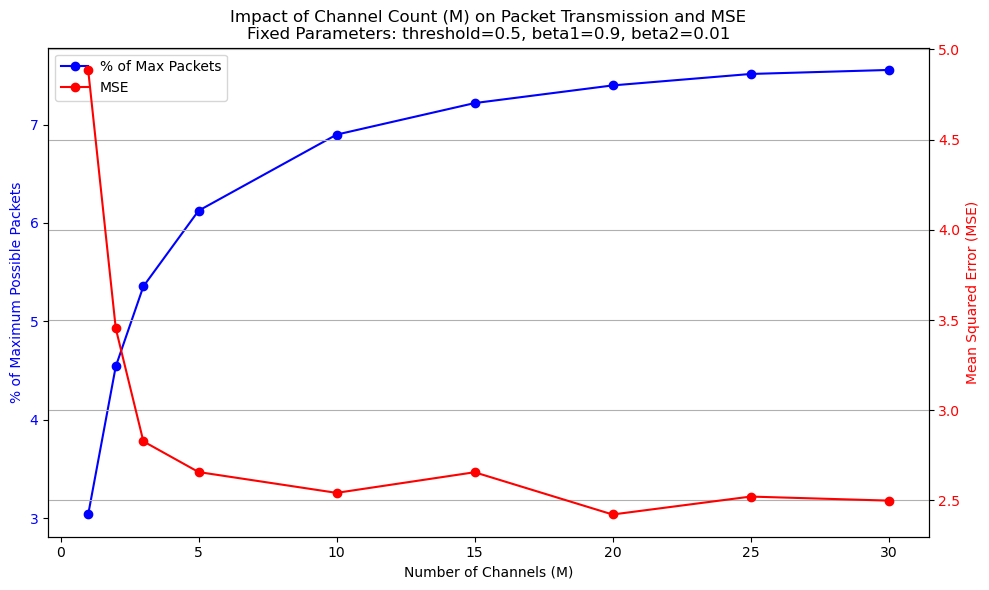

In [93]:
import numpy as np
import random
import matplotlib.pyplot as plt

def multi_node_push_based_system(N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_readings):
    """
    Simulates N nodes with M available channels using actual temperature readings.
    Implements a simple backoff mechanism for handling channel collisions.
    
    Args:
        N: Number of nodes
        M: Number of available channels
        time_steps: Total simulation time steps
        threshold: Threshold for determining when to transmit
        beta_1, beta_2: DEWMA parameters
        delta_t: Time difference between measurements
        temperature_readings: List of N arrays containing actual temperature readings for each node
        
    Returns:
        Dictionary with transmission statistics and node states
    """
    # Initialize nodes with starting values
    nodes = [{
        'last_state_value': temperature_readings[i][0],  # Start with first reading
        'last_rate_of_change': 0.0,
        'last_update_time': 0,
        'backoff_counter': 0,  # Initialize backoff counter
        'true_values': temperature_readings[i],  # Store true temperature values
        'transmitted_values': [temperature_readings[i][0]],  # Values that were transmitted
        'transmission_times': [0]  # Times when transmissions occurred
    } for i in range(N)]
    
    # Track statistics
    total_transmissions = 0
    failed_transmissions = 0
    channel_collisions = {m: 0 for m in range(M)}
    
    for t in range(1, time_steps):
        # Track which channels are successfully used in this time step
        channel_usage = set()
        
        for node_id in range(N):
            node = nodes[node_id]
            
            # Skip if node is in backoff period
            if node['backoff_counter'] > 0:
                node['backoff_counter'] -= 1
                continue
                
            # Get current temperature reading for this node
            measured_value = temperature_readings[node_id][t]
            
            # Update node state using DEWMA
            x1, x2 = update_node_state_dewma(
                measured_value, 
                node['last_state_value'], 
                node['last_rate_of_change'], 
                delta_t, 
                beta_1, 
                beta_2
            )
            
            # Calculate time since last update
            delta = t - node['last_update_time']
            
            # Determine if transmission is needed based on threshold
            if np.abs(x2 * delta) > threshold:
                # Attempt to transmit - randomly choose a channel
                chosen_channel = random.randint(0, M - 1)
                
                # Check for collision
                if chosen_channel in channel_usage:
                    # Collision occurred
                    failed_transmissions += 1
                    channel_collisions[chosen_channel] += 1
                    
                    # Apply backoff - random period between 1 and node_id+3
                    # This gives different backoff strategies to different nodes
                    node['backoff_counter'] = random.randint(1, node_id + 3)
                else:
                    # Successful transmission
                    channel_usage.add(chosen_channel)
                    total_transmissions += 1
                    
                    # Update node state
                    node['last_update_time'] = t
                    node['last_state_value'] = x1
                    node['last_rate_of_change'] = x2
                    
                    # Record transmitted value and time
                    node['transmitted_values'].append(x1)
                    node['transmission_times'].append(t)
    
    # Calculate transmission efficiency
    transmission_efficiency = total_transmissions / (total_transmissions + failed_transmissions) if (total_transmissions + failed_transmissions) > 0 else 0
    
    # Calculate MSE between true and estimated values for each node
    mse_values = []
    for node_id in range(N):
        node = nodes[node_id]
        true_values = node['true_values']
        
        # Create interpolated values based on transmissions
        estimated_values = np.zeros(time_steps)
        transmission_times = node['transmission_times']
        transmitted_values = node['transmitted_values']
        
        # Fill in with last known transmitted value
        current_idx = 0
        for t in range(time_steps):
            while current_idx < len(transmission_times) - 1 and t >= transmission_times[current_idx + 1]:
                current_idx += 1
            estimated_values[t] = transmitted_values[current_idx]
        
        # Calculate MSE for this node
        error = np.mean((true_values[:time_steps] - estimated_values) ** 2)
        mse_values.append(error)
    
    # Return comprehensive results
    return {
        'total_transmissions': total_transmissions,
        'failed_transmissions': failed_transmissions,
        'transmission_efficiency': transmission_efficiency,
        'avg_mse': np.mean(mse_values),
        'mse_per_node': mse_values,
        'channel_collisions': channel_collisions,
        'nodes': nodes
    }

def update_node_state_dewma(measured_value, last_state_value, last_rate_of_change, delta_t, beta_1, beta_2):
    """
    Updates node state using Double Exponentially Weighted Moving Average (DEWMA).
    
    Args:
        measured_value: Current temperature reading
        last_state_value: Previous state value
        last_rate_of_change: Previous rate of change
        delta_t: Time difference
        beta_1, beta_2: DEWMA parameters
        
    Returns:
        Updated state value and rate of change
    """
    x1 = beta_1 * measured_value + (1 - beta_1) * (last_state_value + last_rate_of_change * delta_t)
    x2 = beta_2 * (x1 - last_state_value) / delta_t + (1 - beta_2) * last_rate_of_change
    return x1, x2

def run_system_analysis(temperature_data, varying_m_values, time_steps=1000, threshold=0.5, beta_1=0.3, beta_2=0.1, delta_t=1.0):
    """
    Runs system analysis with varying numbers of channels.
    
    Args:
        temperature_data: Temperature readings for each node
        varying_m_values: List of M values to test
        time_steps, threshold, beta_1, beta_2, delta_t: Simulation parameters
        
    Returns:
        Results for each M value
    """
    N = len(temperature_data)  # Number of nodes is determined by temperature data
    results = {}
    
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_data
        )
        results[M] = result
        
    return results

def plot_system_performance(results, varying_m_values):
    """
    Plots system performance metrics for different M values.
    
    Args:
        results: Dictionary of results from run_system_analysis
        varying_m_values: List of M values tested
    """
    # Extract performance metrics
    transmission_efficiencies = [results[M]['transmission_efficiency'] * 100 for M in varying_m_values]
    avg_mse = [results[M]['avg_mse'] for M in varying_m_values]
    total_transmissions = [results[M]['total_transmissions'] for M in varying_m_values]
    failed_transmissions = [results[M]['failed_transmissions'] for M in varying_m_values]
    
    # Calculate collision ratio
    collision_ratios = [results[M]['failed_transmissions'] / 
                       (results[M]['total_transmissions'] + results[M]['failed_transmissions']) * 100 
                       if (results[M]['total_transmissions'] + results[M]['failed_transmissions']) > 0 
                       else 0 
                       for M in varying_m_values]
    
    # Create figure with subplots
    fig, axs = plt.subplots(3, 2, figsize=(14, 15))
    
    # Plot transmission efficiency
    axs[0, 0].plot(varying_m_values, transmission_efficiencies, 'o-', color='blue')
    axs[0, 0].set_xlabel('Number of Channels (M)')
    axs[0, 0].set_ylabel('Transmission Efficiency (%)')
    axs[0, 0].set_title('Transmission Efficiency vs. Number of Channels')
    axs[0, 0].grid(True)
    
    # Plot MSE
    axs[0, 1].plot(varying_m_values, avg_mse, 'o-', color='red')
    axs[0, 1].set_xlabel('Number of Channels (M)')
    axs[0, 1].set_ylabel('Average MSE')
    axs[0, 1].set_title('Average MSE vs. Number of Channels')
    axs[0, 1].grid(True)
    
    # Plot successful transmissions
    axs[1, 0].plot(varying_m_values, total_transmissions, 'o-', color='green')
    axs[1, 0].set_xlabel('Number of Channels (M)')
    axs[1, 0].set_ylabel('Successful Transmissions')
    axs[1, 0].set_title('Successful Transmissions vs. Number of Channels')
    axs[1, 0].grid(True)
    
    # Plot failed transmissions
    axs[1, 1].plot(varying_m_values, failed_transmissions, 'o-', color='orange')
    axs[1, 1].set_xlabel('Number of Channels (M)')
    axs[1, 1].set_ylabel('Failed Transmissions')
    axs[1, 1].set_title('Failed Transmissions vs. Number of Channels')
    axs[1, 1].grid(True)
    
    # Plot collision ratio
    axs[2, 0].plot(varying_m_values, collision_ratios, 'o-', color='purple')
    axs[2, 0].set_xlabel('Number of Channels (M)')
    axs[2, 0].set_ylabel('Collision Ratio (%)')
    axs[2, 0].set_title('Collision Ratio vs. Number of Channels')
    axs[2, 0].grid(True)
    
    # Plot MSE vs Transmission Efficiency (trade-off)
    axs[2, 1].scatter(transmission_efficiencies, avg_mse, c=varying_m_values, cmap='viridis', s=100)
    for i, M in enumerate(varying_m_values):
        axs[2, 1].annotate(f'M={M}', 
                         (transmission_efficiencies[i], avg_mse[i]),
                         textcoords="offset points", 
                         xytext=(0,10), 
                         ha='center')
    axs[2, 1].set_xlabel('Transmission Efficiency (%)')
    axs[2, 1].set_ylabel('Average MSE')
    axs[2, 1].set_title('Trade-off: MSE vs. Transmission Efficiency')
    axs[2, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage:
if __name__ == "__main__":
    import pandas as pd
    
    # Load the specific dataset
    #pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    pivot_df = pd.read_csv("top_fifty_motes_temperatures.csv")
    pivot_df = pivot_df.apply(lambda x: x.fillna(x.mean()), axis=0)  # Fill missing values
    pivot_df = pivot_df.head(10000) 
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('mote')]
    print(f"Found {len(node_columns)} node columns")
    
    # Extract temperature data for each node
    temperature_data = []
    for node_col in node_columns:
        temperature_data.append(pivot_df[node_col].values)
    
    # Get time steps from dataset
    time_steps = len(pivot_df)
    N = len(node_columns)  # Number of nodes
    
    # Use fixed parameters as requested
    fixed_threshold = 0.5
    fixed_beta_1 = 0.9
    fixed_beta_2 = 0.01
    delta_t = 1.0
    
    # Run analysis with varying M values
    varying_m_values = [1, 2, 3, 5, 10, 15, 20, 25, 30]
    
    # Dictionary to store results
    results = {}
    
    # Run simulations for each M value
    print("\nRunning simulations with varying M values...")
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N=N,
            M=M,
            time_steps=time_steps,
            threshold=fixed_threshold,
            beta_1=fixed_beta_1,
            beta_2=fixed_beta_2,
            delta_t=delta_t,
            temperature_readings=temperature_data
        )
        results[M] = result
        
    # Calculate the theoretical maximum number of packets if all nodes sent data at every timestep
    max_possible_packets = M * time_steps
    
    # Print results in a simple table format
    print("\nResults Summary:")
    print("-" * 80)
    print(f"{'M':^10} | {'Packets Sent':^15} | {'% of Max Possible':^20} | {'MSE':^15}")
    print("-" * 80)
    
    for M in varying_m_values:
        r = results[M]
        packets_sent = r['total_transmissions']
        percentage = (packets_sent / max_possible_packets) * 100
        mse = r['avg_mse']
        
        print(f"{M:^10} | {packets_sent:^15} | {percentage:^20.2f} | {mse:^15.4f}")
    
    print("-" * 80)
    print(f"Fixed parameters: threshold={fixed_threshold}, beta_1={fixed_beta_1}, beta_2={fixed_beta_2}")
    print(f"Maximum possible packets: {max_possible_packets}")
    
    # Create a simple plot showing the results
    plt.figure(figsize=(10, 6))
    
    # Line for percentage of packets sent
    ax1 = plt.gca()
    ax1.set_xlabel('Number of Channels (M)')
    ax1.set_ylabel('% of Maximum Possible Packets', color='blue')
    ax1.plot(varying_m_values, [(results[M]['total_transmissions'] / max_possible_packets) * 100 for M in varying_m_values], 
             'o-', color='blue', label='% of Max Packets')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Line for MSE on secondary y-axis
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Squared Error (MSE)', color='red')
    ax2.plot(varying_m_values, [results[M]['avg_mse'] for M in varying_m_values], 
             'o-', color='red', label='MSE')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title(f'Impact of Channel Count (M) on Packet Transmission and MSE\nFixed Parameters: threshold={fixed_threshold}, beta1={fixed_beta_1}, beta2={fixed_beta_2}')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    plt.tight_layout()
    plt.grid(True)
    plt.show()

Dataset loaded with shape: (10000, 51)
Found 50 node columns

Running simulations with varying M values...

Results Summary:
------------------------------------------------------------------------------------------------------------------------
  M   |  Successful  |    Failed    | Total Attempts  | % of Max Possible  |  % Collisions  |    MSE    
------------------------------------------------------------------------------------------------------------------------
  1   |     7872     |     7394     |      15266      |        3.05        |     48.43      |   4.6559  
  2   |    10010     |     3820     |      13830      |        2.77        |     27.62      |   4.1907  
  5   |    11507     |     1557     |      13064      |        2.61        |     11.92      |   3.9306  
 10   |    12015     |     787      |      12802      |        2.56        |      6.15      |   3.9733  
 15   |    12236     |     506      |      12742      |        2.55        |      3.97      |   3.9412  
 20

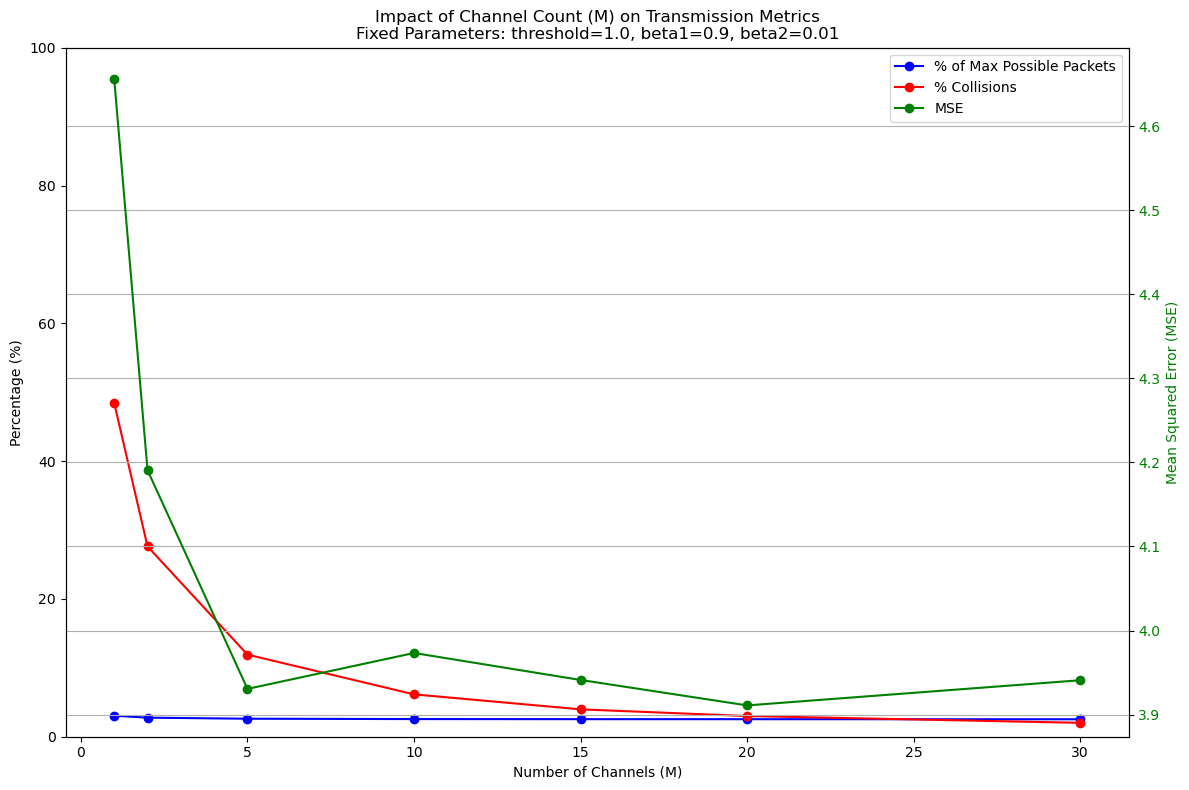

In [102]:
import numpy as np
import random
import matplotlib.pyplot as plt

def multi_node_push_based_system(N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_readings):
    """
    Simulates N nodes with M available channels using actual temperature readings.
    Implements a simple backoff mechanism for handling channel collisions.
    
    Args:
        N: Number of nodes
        M: Number of available channels
        time_steps: Total simulation time steps
        threshold: Threshold for determining when to transmit
        beta_1, beta_2: DEWMA parameters
        delta_t: Time difference between measurements
        temperature_readings: List of N arrays containing actual temperature readings for each node
        
    Returns:
        Dictionary with transmission statistics and node states
    """
    # Initialize nodes with starting values
    nodes = [{
        'last_state_value': temperature_readings[i][0],  # Start with first reading
        'last_rate_of_change': 0.0,
        'last_update_time': 0,
        'backoff_counter': 0,  # Initialize backoff counter
        'true_values': temperature_readings[i],  # Store true temperature values
        'transmitted_values': [temperature_readings[i][0]],  # Values that were transmitted
        'transmission_times': [0]  # Times when transmissions occurred
    } for i in range(N)]
    
    # Track statistics
    total_transmissions = 0
    failed_transmissions = 0
    channel_collisions = {m: 0 for m in range(M)}
    
    for t in range(1, time_steps):
        # Track which channels are successfully used in this time step
        channel_usage = set()
        
        for node_id in range(N):
            node = nodes[node_id]
            
            # Skip if node is in backoff period
            if node['backoff_counter'] > 0:
                node['backoff_counter'] -= 1
                continue
                
            # Get current temperature reading for this node
            measured_value = temperature_readings[node_id][t]
            
            # Update node state using DEWMA
            x1, x2 = update_node_state_dewma(
                measured_value, 
                node['last_state_value'], 
                node['last_rate_of_change'], 
                delta_t, 
                beta_1, 
                beta_2
            )
            
            # Calculate time since last update
            delta = t - node['last_update_time']
            
            # Determine if transmission is needed based on threshold
            if np.abs(x2 * delta) > threshold:
                # Attempt to transmit - randomly choose a channel
                chosen_channel = random.randint(0, M - 1)
                
                # Check for collision
                if chosen_channel in channel_usage:
                    # Collision occurred
                    failed_transmissions += 1
                    channel_collisions[chosen_channel] += 1
                    
                    # Apply backoff - random period between 1 and node_id+3
                    # This gives different backoff strategies to different nodes
                    node['backoff_counter'] = random.randint(1, node_id + 3)
                else:
                    # Successful transmission
                    channel_usage.add(chosen_channel)
                    total_transmissions += 1
                    
                    # Update node state
                    node['last_update_time'] = t
                    node['last_state_value'] = x1
                    node['last_rate_of_change'] = x2
                    
                    # Record transmitted value and time
                    node['transmitted_values'].append(x1)
                    node['transmission_times'].append(t)
    
    # Calculate transmission efficiency
    transmission_efficiency = total_transmissions / (total_transmissions + failed_transmissions) if (total_transmissions + failed_transmissions) > 0 else 0
    
    # Calculate MSE between true and estimated values for each node
    mse_values = []
    for node_id in range(N):
        node = nodes[node_id]
        true_values = node['true_values']
        
        # Create interpolated values based on transmissions
        estimated_values = np.zeros(time_steps)
        transmission_times = node['transmission_times']
        transmitted_values = node['transmitted_values']
        
        # Fill in with last known transmitted value
        current_idx = 0
        for t in range(time_steps):
            while current_idx < len(transmission_times) - 1 and t >= transmission_times[current_idx + 1]:
                current_idx += 1
            estimated_values[t] = transmitted_values[current_idx]
        
        # Calculate MSE for this node
        error = np.mean((true_values[:time_steps] - estimated_values) ** 2)
        mse_values.append(error)
    
    # Return comprehensive results
    return {
        'total_transmissions': total_transmissions,
        'failed_transmissions': failed_transmissions,
        'transmission_efficiency': transmission_efficiency,
        'avg_mse': np.mean(mse_values),
        'mse_per_node': mse_values,
        'channel_collisions': channel_collisions,
        'nodes': nodes
    }

def update_node_state_dewma(measured_value, last_state_value, last_rate_of_change, delta_t, beta_1, beta_2):
    """
    Updates node state using Double Exponentially Weighted Moving Average (DEWMA).
    
    Args:
        measured_value: Current temperature reading
        last_state_value: Previous state value
        last_rate_of_change: Previous rate of change
        delta_t: Time difference
        beta_1, beta_2: DEWMA parameters
        
    Returns:
        Updated state value and rate of change
    """
    x1 = beta_1 * measured_value + (1 - beta_1) * (last_state_value + last_rate_of_change * delta_t)
    x2 = beta_2 * (x1 - last_state_value) / delta_t + (1 - beta_2) * last_rate_of_change
    return x1, x2

def run_system_analysis(temperature_data, varying_m_values, time_steps=1000, threshold=0.5, beta_1=0.3, beta_2=0.1, delta_t=1.0):
    """
    Runs system analysis with varying numbers of channels.
    
    Args:
        temperature_data: Temperature readings for each node
        varying_m_values: List of M values to test
        time_steps, threshold, beta_1, beta_2, delta_t: Simulation parameters
        
    Returns:
        Results for each M value
    """
    N = len(temperature_data)  # Number of nodes is determined by temperature data
    results = {}
    
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_data
        )
        results[M] = result
        
    return results

def plot_system_performance(results, varying_m_values):
    """
    Plots system performance metrics for different M values.
    
    Args:
        results: Dictionary of results from run_system_analysis
        varying_m_values: List of M values tested
    """
    # Extract performance metrics
    transmission_efficiencies = [results[M]['transmission_efficiency'] * 100 for M in varying_m_values]
    avg_mse = [results[M]['avg_mse'] for M in varying_m_values]
    total_transmissions = [results[M]['total_transmissions'] for M in varying_m_values]
    failed_transmissions = [results[M]['failed_transmissions'] for M in varying_m_values]
    
    # Calculate collision ratio
    collision_ratios = [results[M]['failed_transmissions'] / 
                       (results[M]['total_transmissions'] + results[M]['failed_transmissions']) * 100 
                       if (results[M]['total_transmissions'] + results[M]['failed_transmissions']) > 0 
                       else 0 
                       for M in varying_m_values]
    
    # Create figure with subplots
    fig, axs = plt.subplots(3, 2, figsize=(14, 15))
    
    # Plot transmission efficiency
    axs[0, 0].plot(varying_m_values, transmission_efficiencies, 'o-', color='blue')
    axs[0, 0].set_xlabel('Number of Channels (M)')
    axs[0, 0].set_ylabel('Transmission Efficiency (%)')
    axs[0, 0].set_title('Transmission Efficiency vs. Number of Channels')
    axs[0, 0].grid(True)
    
    # Plot MSE
    axs[0, 1].plot(varying_m_values, avg_mse, 'o-', color='red')
    axs[0, 1].set_xlabel('Number of Channels (M)')
    axs[0, 1].set_ylabel('Average MSE')
    axs[0, 1].set_title('Average MSE vs. Number of Channels')
    axs[0, 1].grid(True)
    
    # Plot successful transmissions
    axs[1, 0].plot(varying_m_values, total_transmissions, 'o-', color='green')
    axs[1, 0].set_xlabel('Number of Channels (M)')
    axs[1, 0].set_ylabel('Successful Transmissions')
    axs[1, 0].set_title('Successful Transmissions vs. Number of Channels')
    axs[1, 0].grid(True)
    
    # Plot failed transmissions
    axs[1, 1].plot(varying_m_values, failed_transmissions, 'o-', color='orange')
    axs[1, 1].set_xlabel('Number of Channels (M)')
    axs[1, 1].set_ylabel('Failed Transmissions')
    axs[1, 1].set_title('Failed Transmissions vs. Number of Channels')
    axs[1, 1].grid(True)
    
    # Plot collision ratio
    axs[2, 0].plot(varying_m_values, collision_ratios, 'o-', color='purple')
    axs[2, 0].set_xlabel('Number of Channels (M)')
    axs[2, 0].set_ylabel('Collision Ratio (%)')
    axs[2, 0].set_title('Collision Ratio vs. Number of Channels')
    axs[2, 0].grid(True)
    
    # Plot MSE vs Transmission Efficiency (trade-off)
    axs[2, 1].scatter(transmission_efficiencies, avg_mse, c=varying_m_values, cmap='viridis', s=100)
    for i, M in enumerate(varying_m_values):
        axs[2, 1].annotate(f'M={M}', 
                         (transmission_efficiencies[i], avg_mse[i]),
                         textcoords="offset points", 
                         xytext=(0,10), 
                         ha='center')
    axs[2, 1].set_xlabel('Transmission Efficiency (%)')
    axs[2, 1].set_ylabel('Average MSE')
    axs[2, 1].set_title('Trade-off: MSE vs. Transmission Efficiency')
    axs[2, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage:
if __name__ == "__main__":
    import pandas as pd
    
    # Load the specific dataset
    #pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    pivot_df = pd.read_csv("top_fifty_motes_temperatures.csv")
    pivot_df = pivot_df.apply(lambda x: x.fillna(x.mean()), axis=0)  # Fill missing values
    pivot_df = pivot_df.head(10000) 
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('mote')]
    print(f"Found {len(node_columns)} node columns")
    
    # Extract temperature data for each node
    temperature_data = []
    for node_col in node_columns:
        temperature_data.append(pivot_df[node_col].values)
    
    # Get time steps from dataset
    time_steps = len(pivot_df)
    N = len(node_columns)  # Number of nodes
    
    # Use fixed parameters as requested
    fixed_threshold = 1.0
    fixed_beta_1 = 0.9
    fixed_beta_2 = 0.01
    delta_t = 1.0
    
    # Run analysis with varying M values
    varying_m_values = [1, 2, 5, 10, 15, 20, 30]
    
    # Dictionary to store results
    results = {}
    
    # Run simulations for each M value
    print("\nRunning simulations with varying M values...")
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N=N,
            M=M,
            time_steps=time_steps,
            threshold=fixed_threshold,
            beta_1=fixed_beta_1,
            beta_2=fixed_beta_2,
            delta_t=delta_t,
            temperature_readings=temperature_data
        )
        results[M] = result
        
    # Calculate the theoretical maximum number of packets if all nodes sent data at every timestep
    max_possible_packets = N * time_steps
    
    # Print results in a detailed table format with collision statistics
    print("\nResults Summary:")
    print("-" * 120)
    print(f"{'M':^5} | {'Successful':^12} | {'Failed':^12} | {'Total Attempts':^15} | {'% of Max Possible':^18} | {'% Collisions':^14} | {'MSE':^10}")
    print("-" * 120)
    
    for M in varying_m_values:
        r = results[M]
        successful = r['total_transmissions']
        failed = r['failed_transmissions']
        total_attempts = successful + failed
        
        # Calculate percentages
        percentage_of_max = (total_attempts / max_possible_packets) * 100
        percentage_collisions = (failed / total_attempts) * 100 if total_attempts > 0 else 0
        mse = r['avg_mse']
        
        print(f"{M:^5} | {successful:^12} | {failed:^12} | {total_attempts:^15} | {percentage_of_max:^18.2f} | {percentage_collisions:^14.2f} | {mse:^10.4f}")
    
    print("-" * 120)
    print(f"Fixed parameters: threshold={fixed_threshold}, beta_1={fixed_beta_1}, beta_2={fixed_beta_2}")
    print(f"Maximum possible packets: {max_possible_packets} (N nodes × time steps)")
    
    # Create a plot showing the metrics
    plt.figure(figsize=(12, 8))
    
    # Primary y-axis for percentages
    ax1 = plt.gca()
    ax1.set_xlabel('Number of Channels (M)')
    ax1.set_ylabel('Percentage (%)', color='black')
    
    # Plot percentage of maximum possible packets (total attempts)
    percentages_of_max = [(results[M]['total_transmissions'] + results[M]['failed_transmissions']) / max_possible_packets * 100 
                         for M in varying_m_values]
    ax1.plot(varying_m_values, percentages_of_max, 'o-', color='blue', label='% of Max Possible Packets')
    
    # Plot collision percentages
    collision_percentages = [results[M]['failed_transmissions'] / 
                            (results[M]['total_transmissions'] + results[M]['failed_transmissions']) * 100 
                            if (results[M]['total_transmissions'] + results[M]['failed_transmissions']) > 0 
                            else 0 
                            for M in varying_m_values]
    ax1.plot(varying_m_values, collision_percentages, 'o-', color='red', label='% Collisions')
    
    # Set y-axis limits for percentages
    ax1.set_ylim(0, 100)
    ax1.tick_params(axis='y')
    
    # Secondary y-axis for MSE
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Squared Error (MSE)', color='green')
    
    # Plot MSE
    mse_values = [results[M]['avg_mse'] for M in varying_m_values]
    ax2.plot(varying_m_values, mse_values, 'o-', color='green', label='MSE')
    ax2.tick_params(axis='y', labelcolor='green')
    
    # Set title
    plt.title(f'Impact of Channel Count (M) on Transmission Metrics\nFixed Parameters: threshold={fixed_threshold}, beta1={fixed_beta_1}, beta2={fixed_beta_2}')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    plt.tight_layout()
    plt.grid(True)
    plt.show()

Dataset loaded with shape: (50000, 31)
Found 30 node columns

Running simulations with varying M values...
Array length mismatch for node 0: true_values=49999, x1_values=50000
Array length mismatch for node 1: true_values=49999, x1_values=50000
Array length mismatch for node 2: true_values=49999, x1_values=50000
Array length mismatch for node 3: true_values=49999, x1_values=50000
Array length mismatch for node 4: true_values=49999, x1_values=50000
Array length mismatch for node 5: true_values=49999, x1_values=50000
Array length mismatch for node 6: true_values=49999, x1_values=50000
Array length mismatch for node 7: true_values=49999, x1_values=50000
Array length mismatch for node 8: true_values=49999, x1_values=50000
Array length mismatch for node 9: true_values=49999, x1_values=50000
Array length mismatch for node 10: true_values=49999, x1_values=50000
Array length mismatch for node 11: true_values=49999, x1_values=50000
Array length mismatch for node 12: true_values=49999, x1_values

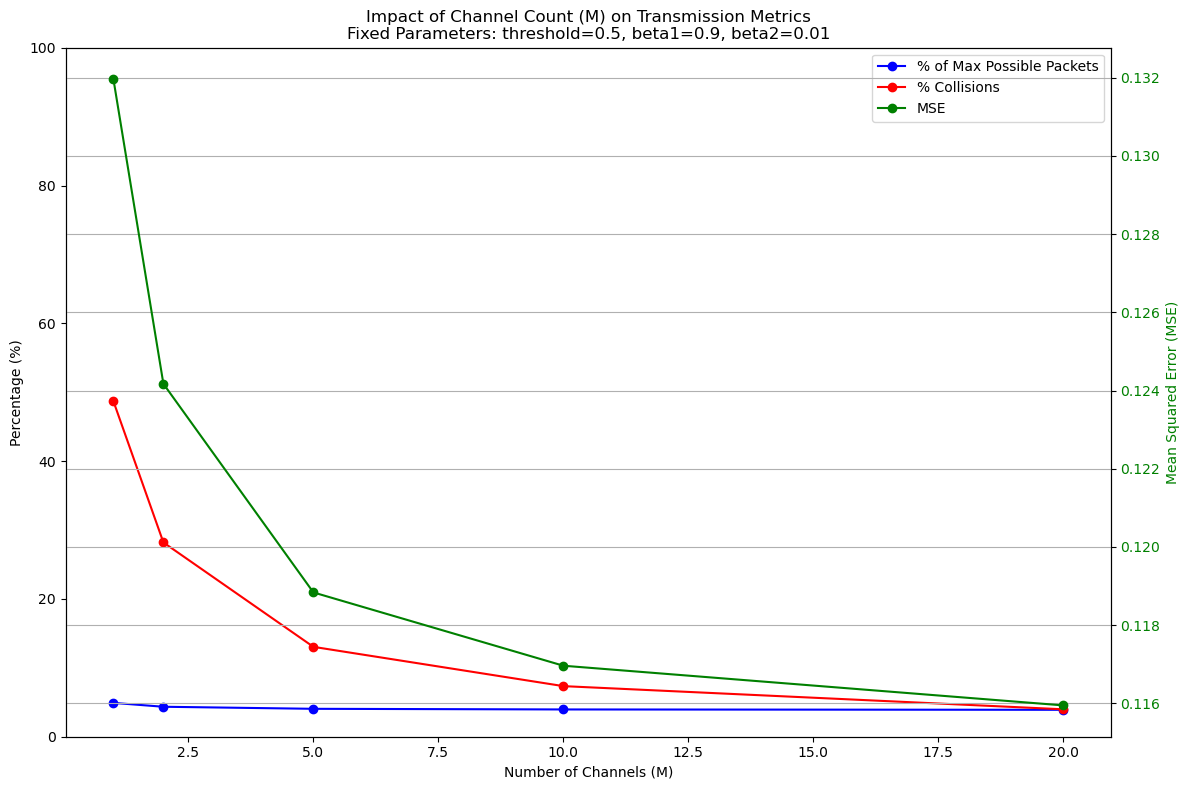

In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt

def multi_node_push_based_system(N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_readings):
    """
    Simulates N nodes with M available channels using actual temperature readings.
    Implements a simple backoff mechanism for handling channel collisions.
    
    Args:
        N: Number of nodes
        M: Number of available channels
        time_steps: Total simulation time steps
        threshold: Threshold for determining when to transmit
        beta_1, beta_2: DEWMA parameters
        delta_t: Time difference between measurements
        temperature_readings: List of N arrays containing actual temperature readings for each node
        
    Returns:
        Dictionary with transmission statistics and node states
    """
    # Initialize nodes with starting values
    nodes = [{
        'last_state_value': temperature_readings[i][0],  # Start with first reading
        'last_rate_of_change': 0.0,
        'last_update_time': 0,
        'backoff_counter': 0,  # Initialize backoff counter
        'true_values': temperature_readings[i],  # Store true temperature values
        'transmitted_values': [temperature_readings[i][0]],  # Values that were transmitted
        'transmission_times': [0],  # Times when transmissions occurred
        'all_x1_values': [temperature_readings[i][0]]  # Store all x1 values calculated at each time step
    } for i in range(N)]
    
    # Track statistics
    total_transmissions = 0
    failed_transmissions = 0
    channel_collisions = {m: 0 for m in range(M)}
    
    for t in range(1, time_steps):
        # Track which channels are successfully used in this time step
        channel_usage = set()
        
        for node_id in range(N):
            node = nodes[node_id]
            
            # Skip if node is in backoff period
            if node['backoff_counter'] > 0:
                node['backoff_counter'] -= 1
                
                # Even during backoff, we still calculate x1 (but don't use it for transmission)
                measured_value = temperature_readings[node_id][t]
                x1, _ = update_node_state_dewma(
                    measured_value, 
                    node['last_state_value'], 
                    node['last_rate_of_change'], 
                    delta_t, 
                    beta_1, 
                    beta_2
                )
                # Store x1 value regardless of transmission
                node['all_x1_values'].append(x1)
                continue
                
            # Get current temperature reading for this node
            measured_value = temperature_readings[node_id][t]
            
            # Update node state using DEWMA - this happens at every time step
            x1, x2 = update_node_state_dewma(
                measured_value, 
                node['last_state_value'], 
                node['last_rate_of_change'], 
                delta_t, 
                beta_1, 
                beta_2
            )
            
            # Store x1 value regardless of transmission
            node['all_x1_values'].append(x1)
            
            # Calculate time since last update
            delta = t - node['last_update_time']
            
            # Determine if transmission is needed based on threshold
            if np.abs(x2 * delta) > threshold:
                # Attempt to transmit - randomly choose a channel
                chosen_channel = random.randint(0, M - 1)
                
                # Check for collision
                if chosen_channel in channel_usage:
                    # Collision occurred
                    failed_transmissions += 1
                    channel_collisions[chosen_channel] += 1
                    
                    # Apply backoff - random period between 1 and node_id+3
                    # This gives different backoff strategies to different nodes
                    node['backoff_counter'] = random.randint(1, node_id + 3)
                else:
                    # Successful transmission
                    channel_usage.add(chosen_channel)
                    total_transmissions += 1
                    
                    # Update node state
                    node['last_update_time'] = t
                    node['last_state_value'] = x1
                    node['last_rate_of_change'] = x2
                    
                    # Record transmitted value and time
                    node['transmitted_values'].append(x1)
                    node['transmission_times'].append(t)
    
    # Calculate transmission efficiency
    transmission_efficiency = total_transmissions / (total_transmissions + failed_transmissions) if (total_transmissions + failed_transmissions) > 0 else 0
    
    # Calculate MSE between true temperature values and x1 values for each node
    mse_values = []
    for node_id in range(N):
        node = nodes[node_id]
        true_values = node['true_values'][1:time_steps]  # Skip first value as it's the initial state
        x1_values = node['all_x1_values']  # All x1 values calculated at each time step
        
        # Ensure arrays are of the same length before calculating MSE
        if len(true_values) != len(x1_values):
            # Debug information
            print(f"Array length mismatch for node {node_id}: true_values={len(true_values)}, x1_values={len(x1_values)}")
            # Use the minimum length to avoid broadcasting errors
            min_length = min(len(true_values), len(x1_values))
            true_values = true_values[:min_length]
            x1_values = x1_values[:min_length]
        
        # Calculate MSE for this node - comparing true values with x1 at each time step
        error = np.mean((true_values - x1_values) ** 2)
        mse_values.append(error)
    
    # Return comprehensive results
    return {
        'total_transmissions': total_transmissions,
        'failed_transmissions': failed_transmissions,
        'transmission_efficiency': transmission_efficiency,
        'avg_mse': np.mean(mse_values),
        'mse_per_node': mse_values,
        'channel_collisions': channel_collisions,
        'nodes': nodes
    }

def update_node_state_dewma(measured_value, last_state_value, last_rate_of_change, delta_t, beta_1, beta_2):
    """
    Updates node state using Double Exponentially Weighted Moving Average (DEWMA).
    
    Args:
        measured_value: Current temperature reading
        last_state_value: Previous state value
        last_rate_of_change: Previous rate of change
        delta_t: Time difference
        beta_1, beta_2: DEWMA parameters
        
    Returns:
        Updated state value and rate of change
    """
    x1 = beta_1 * measured_value + (1 - beta_1) * (last_state_value + last_rate_of_change * delta_t)
    x2 = beta_2 * (x1 - last_state_value) / delta_t + (1 - beta_2) * last_rate_of_change
    return x1, x2

def run_system_analysis(temperature_data, varying_m_values, time_steps=1000, threshold=0.5, beta_1=0.3, beta_2=0.1, delta_t=1.0):
    """
    Runs system analysis with varying numbers of channels.
    
    Args:
        temperature_data: Temperature readings for each node
        varying_m_values: List of M values to test
        time_steps, threshold, beta_1, beta_2, delta_t: Simulation parameters
        
    Returns:
        Results for each M value
    """
    N = len(temperature_data)  # Number of nodes is determined by temperature data
    results = {}
    
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_data
        )
        results[M] = result
        
    return results

def plot_system_performance(results, varying_m_values):
    """
    Plots system performance metrics for different M values.
    
    Args:
        results: Dictionary of results from run_system_analysis
        varying_m_values: List of M values tested
    """
    # Extract performance metrics
    transmission_efficiencies = [results[M]['transmission_efficiency'] * 100 for M in varying_m_values]
    avg_mse = [results[M]['avg_mse'] for M in varying_m_values]
    total_transmissions = [results[M]['total_transmissions'] for M in varying_m_values]
    failed_transmissions = [results[M]['failed_transmissions'] for M in varying_m_values]
    
    # Calculate collision ratio
    collision_ratios = [results[M]['failed_transmissions'] / 
                       (results[M]['total_transmissions'] + results[M]['failed_transmissions']) * 100 
                       if (results[M]['total_transmissions'] + results[M]['failed_transmissions']) > 0 
                       else 0 
                       for M in varying_m_values]
    
    # Create figure with subplots
    fig, axs = plt.subplots(3, 2, figsize=(14, 15))
    
    # Plot transmission efficiency
    axs[0, 0].plot(varying_m_values, transmission_efficiencies, 'o-', color='blue')
    axs[0, 0].set_xlabel('Number of Channels (M)')
    axs[0, 0].set_ylabel('Transmission Efficiency (%)')
    axs[0, 0].set_title('Transmission Efficiency vs. Number of Channels')
    axs[0, 0].grid(True)
    
    # Plot MSE
    axs[0, 1].plot(varying_m_values, avg_mse, 'o-', color='red')
    axs[0, 1].set_xlabel('Number of Channels (M)')
    axs[0, 1].set_ylabel('Average MSE')
    axs[0, 1].set_title('Average MSE vs. Number of Channels')
    axs[0, 1].grid(True)
    
    # Plot successful transmissions
    axs[1, 0].plot(varying_m_values, total_transmissions, 'o-', color='green')
    axs[1, 0].set_xlabel('Number of Channels (M)')
    axs[1, 0].set_ylabel('Successful Transmissions')
    axs[1, 0].set_title('Successful Transmissions vs. Number of Channels')
    axs[1, 0].grid(True)
    
    # Plot failed transmissions
    axs[1, 1].plot(varying_m_values, failed_transmissions, 'o-', color='orange')
    axs[1, 1].set_xlabel('Number of Channels (M)')
    axs[1, 1].set_ylabel('Failed Transmissions')
    axs[1, 1].set_title('Failed Transmissions vs. Number of Channels')
    axs[1, 1].grid(True)
    
    # Plot collision ratio
    axs[2, 0].plot(varying_m_values, collision_ratios, 'o-', color='purple')
    axs[2, 0].set_xlabel('Number of Channels (M)')
    axs[2, 0].set_ylabel('Collision Ratio (%)')
    axs[2, 0].set_title('Collision Ratio vs. Number of Channels')
    axs[2, 0].grid(True)
    
    # Plot MSE vs Transmission Efficiency (trade-off)
    axs[2, 1].scatter(transmission_efficiencies, avg_mse, c=varying_m_values, cmap='viridis', s=100)
    for i, M in enumerate(varying_m_values):
        axs[2, 1].annotate(f'M={M}', 
                         (transmission_efficiencies[i], avg_mse[i]),
                         textcoords="offset points", 
                         xytext=(0,10), 
                         ha='center')
    axs[2, 1].set_xlabel('Transmission Efficiency (%)')
    axs[2, 1].set_ylabel('Average MSE')
    axs[2, 1].set_title('Trade-off: MSE vs. Transmission Efficiency')
    axs[2, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage:
if __name__ == "__main__":
    import pandas as pd
    
    # Load the specific dataset
    pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")
    
    # Extract temperature data for each node
    temperature_data = []
    for node_col in node_columns:
        temperature_data.append(pivot_df[node_col].values)
    
    # Get time steps from dataset
    time_steps = len(pivot_df)
    N = len(node_columns)  # Number of nodes
    
    # Use fixed parameters as requested
    fixed_threshold = 0.5
    fixed_beta_1 = 0.9
    fixed_beta_2 = 0.01
    delta_t = 1.0
    
    # Run analysis with varying M values
    varying_m_values = [1, 2, 5, 10, 20]
    
    # Dictionary to store results
    results = {}
    
    # Run simulations for each M value
    print("\nRunning simulations with varying M values...")
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N=N,
            M=M,
            time_steps=time_steps,
            threshold=fixed_threshold,
            beta_1=fixed_beta_1,
            beta_2=fixed_beta_2,
            delta_t=delta_t,
            temperature_readings=temperature_data
        )
        results[M] = result
        
    # Calculate the theoretical maximum number of packets if all nodes sent data at every timestep
    max_possible_packets = N * time_steps
    
    # Print results in a detailed table format with collision statistics
    print("\nResults Summary:")
    print("-" * 120)
    print(f"{'M':^5} | {'Successful':^12} | {'Failed':^12} | {'Total Attempts':^15} | {'% of Max Possible':^18} | {'% Collisions':^14} | {'MSE':^10}")
    print("-" * 120)
    
    for M in varying_m_values:
        r = results[M]
        successful = r['total_transmissions']
        failed = r['failed_transmissions']
        #total_attempts = successful + failed
        total_attempts = successful 
        
        # Calculate percentages
        percentage_of_max = (total_attempts / max_possible_packets) * 100
        percentage_collisions = (failed / total_attempts) * 100 if total_attempts > 0 else 0
        mse = r['avg_mse']
        
        print(f"{M:^5} | {successful:^12} | {failed:^12} | {total_attempts:^15} | {percentage_of_max:^18.2f} | {percentage_collisions:^14.2f} | {mse:^10.4f}")
    
    print("-" * 120)
    print(f"Fixed parameters: threshold={fixed_threshold}, beta_1={fixed_beta_1}, beta_2={fixed_beta_2}")
    print(f"Maximum possible packets: {max_possible_packets} (N nodes × time steps)")
    
    # Create a plot showing the metrics
    plt.figure(figsize=(12, 8))
    
    # Primary y-axis for percentages
    ax1 = plt.gca()
    ax1.set_xlabel('Number of Channels (M)')
    ax1.set_ylabel('Percentage (%)', color='black')
    
    # Plot percentage of maximum possible packets (total attempts)
    percentages_of_max = [(results[M]['total_transmissions'] + results[M]['failed_transmissions']) / max_possible_packets * 100 
                         for M in varying_m_values]
    ax1.plot(varying_m_values, percentages_of_max, 'o-', color='blue', label='% of Max Possible Packets')
    
    # Plot collision percentages
    collision_percentages = [results[M]['failed_transmissions'] / 
                            (results[M]['total_transmissions'] + results[M]['failed_transmissions']) * 100 
                            if (results[M]['total_transmissions'] + results[M]['failed_transmissions']) > 0 
                            else 0 
                            for M in varying_m_values]
    ax1.plot(varying_m_values, collision_percentages, 'o-', color='red', label='% Collisions')
    
    # Set y-axis limits for percentages
    ax1.set_ylim(0, 100)
    ax1.tick_params(axis='y')
    
    # Secondary y-axis for MSE
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Squared Error (MSE)', color='green')
    
    # Plot MSE
    mse_values = [results[M]['avg_mse'] for M in varying_m_values]
    ax2.plot(varying_m_values, mse_values, 'o-', color='green', label='MSE')
    ax2.tick_params(axis='y', labelcolor='green')
    
    # Set title
    plt.title(f'Impact of Channel Count (M) on Transmission Metrics\nFixed Parameters: threshold={fixed_threshold}, beta1={fixed_beta_1}, beta2={fixed_beta_2}')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    plt.tight_layout()
    plt.grid(True)
    plt.show()

Dataset loaded with shape: (50000, 31)
Found 30 node columns

Running simulations with fixed M=5 and varying threshold values...
Array length mismatch for node 0: true_values=49999, x1_values=50000
Array length mismatch for node 1: true_values=49999, x1_values=50000
Array length mismatch for node 2: true_values=49999, x1_values=50000
Array length mismatch for node 3: true_values=49999, x1_values=50000
Array length mismatch for node 4: true_values=49999, x1_values=50000
Array length mismatch for node 5: true_values=49999, x1_values=50000
Array length mismatch for node 6: true_values=49999, x1_values=50000
Array length mismatch for node 7: true_values=49999, x1_values=50000
Array length mismatch for node 8: true_values=49999, x1_values=50000
Array length mismatch for node 9: true_values=49999, x1_values=50000
Array length mismatch for node 10: true_values=49999, x1_values=50000
Array length mismatch for node 11: true_values=49999, x1_values=50000
Array length mismatch for node 12: true_v

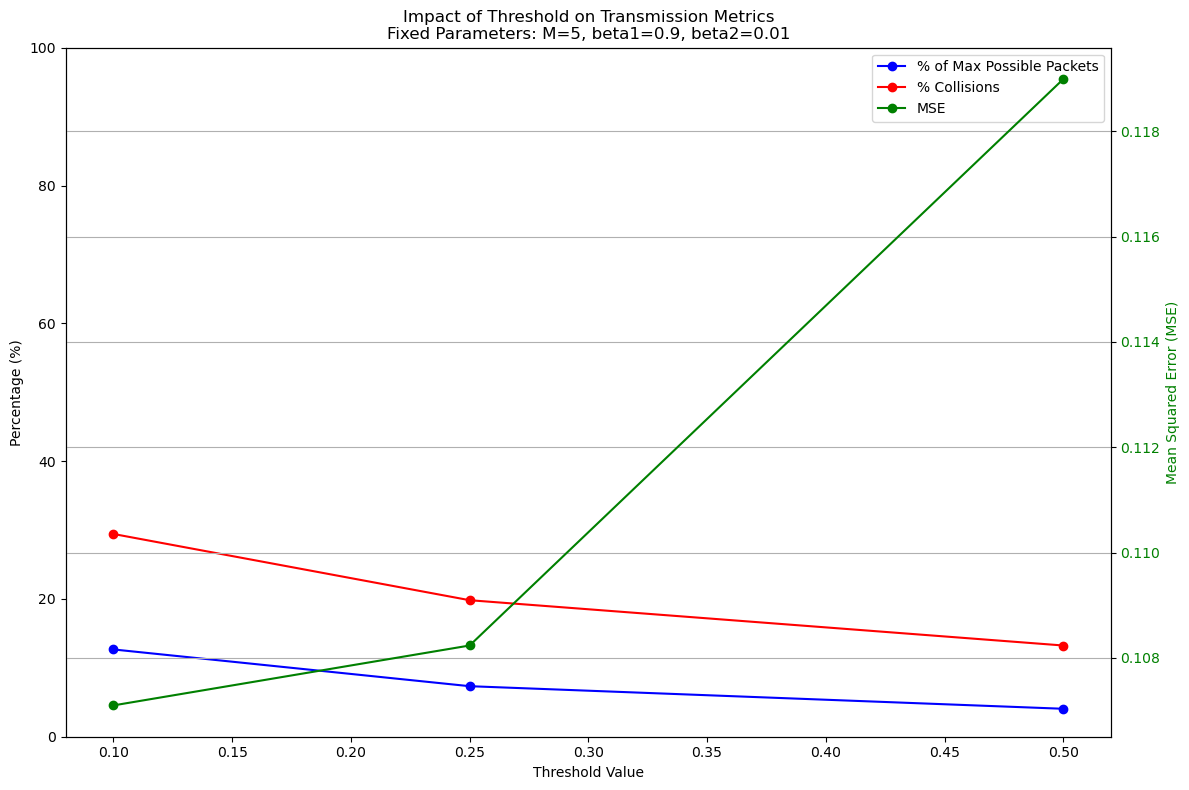

In [106]:
import numpy as np
import random
import matplotlib.pyplot as plt

def multi_node_push_based_system(N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_readings):
    """
    Simulates N nodes with M available channels using actual temperature readings.
    Implements a simple backoff mechanism for handling channel collisions.
    
    Args:
        N: Number of nodes
        M: Number of available channels
        time_steps: Total simulation time steps
        threshold: Threshold for determining when to transmit
        beta_1, beta_2: DEWMA parameters
        delta_t: Time difference between measurements
        temperature_readings: List of N arrays containing actual temperature readings for each node
        
    Returns:
        Dictionary with transmission statistics and node states
    """
    # Initialize nodes with starting values
    nodes = [{
        'last_state_value': temperature_readings[i][0],  # Start with first reading
        'last_rate_of_change': 0.0,
        'last_update_time': 0,
        'backoff_counter': 0,  # Initialize backoff counter
        'true_values': temperature_readings[i],  # Store true temperature values
        'transmitted_values': [temperature_readings[i][0]],  # Values that were transmitted
        'transmission_times': [0],  # Times when transmissions occurred
        'all_x1_values': [temperature_readings[i][0]]  # Store all x1 values calculated at each time step
    } for i in range(N)]
    
    # Track statistics
    total_transmissions = 0
    failed_transmissions = 0
    channel_collisions = {m: 0 for m in range(M)}
    
    for t in range(1, time_steps):
        # Track which channels are successfully used in this time step
        channel_usage = set()
        
        for node_id in range(N):
            node = nodes[node_id]
            
            # Skip if node is in backoff period
            if node['backoff_counter'] > 0:
                node['backoff_counter'] -= 1
                
                # Even during backoff, we still calculate x1 (but don't use it for transmission)
                measured_value = temperature_readings[node_id][t]
                x1, _ = update_node_state_dewma(
                    measured_value, 
                    node['last_state_value'], 
                    node['last_rate_of_change'], 
                    delta_t, 
                    beta_1, 
                    beta_2
                )
                # Store x1 value regardless of transmission
                node['all_x1_values'].append(x1)
                continue
                
            # Get current temperature reading for this node
            measured_value = temperature_readings[node_id][t]
            
            # Update node state using DEWMA - this happens at every time step
            x1, x2 = update_node_state_dewma(
                measured_value, 
                node['last_state_value'], 
                node['last_rate_of_change'], 
                delta_t, 
                beta_1, 
                beta_2
            )
            
            # Store x1 value regardless of transmission
            node['all_x1_values'].append(x1)
            
            # Calculate time since last update
            delta = t - node['last_update_time']
            
            # Determine if transmission is needed based on threshold
            if np.abs(x2 * delta) > threshold:
                # Attempt to transmit - randomly choose a channel
                chosen_channel = random.randint(0, M - 1)
                
                # Check for collision
                if chosen_channel in channel_usage:
                    # Collision occurred
                    failed_transmissions += 1
                    channel_collisions[chosen_channel] += 1
                    
                    # Apply backoff - random period between 1 and node_id+3
                    # This gives different backoff strategies to different nodes
                    node['backoff_counter'] = random.randint(1, node_id + 3)
                else:
                    # Successful transmission
                    channel_usage.add(chosen_channel)
                    total_transmissions += 1
                    
                    # Update node state
                    node['last_update_time'] = t
                    node['last_state_value'] = x1
                    node['last_rate_of_change'] = x2
                    
                    # Record transmitted value and time
                    node['transmitted_values'].append(x1)
                    node['transmission_times'].append(t)
    
    # Calculate transmission efficiency
    transmission_efficiency = total_transmissions / (total_transmissions + failed_transmissions) if (total_transmissions + failed_transmissions) > 0 else 0
    
    # Calculate MSE between true temperature values and x1 values for each node
    mse_values = []
    for node_id in range(N):
        node = nodes[node_id]
        true_values = node['true_values'][1:time_steps]  # Skip first value as it's the initial state
        x1_values = node['all_x1_values']  # All x1 values calculated at each time step
        
        # Ensure arrays are of the same length before calculating MSE
        if len(true_values) != len(x1_values):
            # Debug information
            print(f"Array length mismatch for node {node_id}: true_values={len(true_values)}, x1_values={len(x1_values)}")
            # Use the minimum length to avoid broadcasting errors
            min_length = min(len(true_values), len(x1_values))
            true_values = true_values[:min_length]
            x1_values = x1_values[:min_length]
        
        # Calculate MSE for this node - comparing true values with x1 at each time step
        error = np.mean((true_values - x1_values) ** 2)
        mse_values.append(error)
    
    # Return comprehensive results
    return {
        'total_transmissions': total_transmissions,
        'failed_transmissions': failed_transmissions,
        'transmission_efficiency': transmission_efficiency,
        'avg_mse': np.mean(mse_values),
        'mse_per_node': mse_values,
        'channel_collisions': channel_collisions,
        'nodes': nodes
    }

def update_node_state_dewma(measured_value, last_state_value, last_rate_of_change, delta_t, beta_1, beta_2):
    """
    Updates node state using Double Exponentially Weighted Moving Average (DEWMA).
    
    Args:
        measured_value: Current temperature reading
        last_state_value: Previous state value
        last_rate_of_change: Previous rate of change
        delta_t: Time difference
        beta_1, beta_2: DEWMA parameters
        
    Returns:
        Updated state value and rate of change
    """
    x1 = beta_1 * measured_value + (1 - beta_1) * (last_state_value + last_rate_of_change * delta_t)
    x2 = beta_2 * (x1 - last_state_value) / delta_t + (1 - beta_2) * last_rate_of_change
    return x1, x2

def run_system_analysis(temperature_data, varying_m_values, time_steps=1000, threshold=0.5, beta_1=0.3, beta_2=0.1, delta_t=1.0):
    """
    Runs system analysis with varying numbers of channels.
    
    Args:
        temperature_data: Temperature readings for each node
        varying_m_values: List of M values to test
        time_steps, threshold, beta_1, beta_2, delta_t: Simulation parameters
        
    Returns:
        Results for each M value
    """
    N = len(temperature_data)  # Number of nodes is determined by temperature data
    results = {}
    
    for M in varying_m_values:
        result = multi_node_push_based_system(
            N, M, time_steps, threshold, beta_1, beta_2, delta_t, temperature_data
        )
        results[M] = result
        
    return results

def plot_system_performance(results, varying_m_values):
    """
    Plots system performance metrics for different M values.
    
    Args:
        results: Dictionary of results from run_system_analysis
        varying_m_values: List of M values tested
    """
    # Extract performance metrics
    transmission_efficiencies = [results[M]['transmission_efficiency'] * 100 for M in varying_m_values]
    avg_mse = [results[M]['avg_mse'] for M in varying_m_values]
    total_transmissions = [results[M]['total_transmissions'] for M in varying_m_values]
    failed_transmissions = [results[M]['failed_transmissions'] for M in varying_m_values]
    
    # Calculate collision ratio
    collision_ratios = [results[M]['failed_transmissions'] / 
                       (results[M]['total_transmissions'] + results[M]['failed_transmissions']) * 100 
                       if (results[M]['total_transmissions'] + results[M]['failed_transmissions']) > 0 
                       else 0 
                       for M in varying_m_values]
    
    # Create figure with subplots
    fig, axs = plt.subplots(3, 2, figsize=(14, 15))
    
    # Plot transmission efficiency
    axs[0, 0].plot(varying_m_values, transmission_efficiencies, 'o-', color='blue')
    axs[0, 0].set_xlabel('Number of Channels (M)')
    axs[0, 0].set_ylabel('Transmission Efficiency (%)')
    axs[0, 0].set_title('Transmission Efficiency vs. Number of Channels')
    axs[0, 0].grid(True)
    
    # Plot MSE
    axs[0, 1].plot(varying_m_values, avg_mse, 'o-', color='red')
    axs[0, 1].set_xlabel('Number of Channels (M)')
    axs[0, 1].set_ylabel('Average MSE')
    axs[0, 1].set_title('Average MSE vs. Number of Channels')
    axs[0, 1].grid(True)
    
    # Plot successful transmissions
    axs[1, 0].plot(varying_m_values, total_transmissions, 'o-', color='green')
    axs[1, 0].set_xlabel('Number of Channels (M)')
    axs[1, 0].set_ylabel('Successful Transmissions')
    axs[1, 0].set_title('Successful Transmissions vs. Number of Channels')
    axs[1, 0].grid(True)
    
    # Plot failed transmissions
    axs[1, 1].plot(varying_m_values, failed_transmissions, 'o-', color='orange')
    axs[1, 1].set_xlabel('Number of Channels (M)')
    axs[1, 1].set_ylabel('Failed Transmissions')
    axs[1, 1].set_title('Failed Transmissions vs. Number of Channels')
    axs[1, 1].grid(True)
    
    # Plot collision ratio
    axs[2, 0].plot(varying_m_values, collision_ratios, 'o-', color='purple')
    axs[2, 0].set_xlabel('Number of Channels (M)')
    axs[2, 0].set_ylabel('Collision Ratio (%)')
    axs[2, 0].set_title('Collision Ratio vs. Number of Channels')
    axs[2, 0].grid(True)
    
    # Plot MSE vs Transmission Efficiency (trade-off)
    axs[2, 1].scatter(transmission_efficiencies, avg_mse, c=varying_m_values, cmap='viridis', s=100)
    for i, M in enumerate(varying_m_values):
        axs[2, 1].annotate(f'M={M}', 
                         (transmission_efficiencies[i], avg_mse[i]),
                         textcoords="offset points", 
                         xytext=(0,10), 
                         ha='center')
    axs[2, 1].set_xlabel('Transmission Efficiency (%)')
    axs[2, 1].set_ylabel('Average MSE')
    axs[2, 1].set_title('Trade-off: MSE vs. Transmission Efficiency')
    axs[2, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage:
if __name__ == "__main__":
    import pandas as pd
    
    # Load the specific dataset
    pivot_df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")
    
    # Extract temperature data for each node
    temperature_data = []
    for node_col in node_columns:
        temperature_data.append(pivot_df[node_col].values)
    
    # Get time steps from dataset
    time_steps = len(pivot_df)
    N = len(node_columns)  # Number of nodes
    
    # Use fixed M and beta values as requested
    fixed_M = 5  # Fixed number of channels
    fixed_beta_1 = 0.9
    fixed_beta_2 = 0.01
    delta_t = 1.0
    
    # Vary threshold values
    varying_thresholds = [0.1, 0.25, 0.5]
    
    # Dictionary to store results
    results = {}
    
    # Run simulations for each threshold value
    print("\nRunning simulations with fixed M=5 and varying threshold values...")
    for threshold in varying_thresholds:
        result = multi_node_push_based_system(
            N=N,
            M=fixed_M,
            time_steps=time_steps,
            threshold=threshold,
            beta_1=fixed_beta_1,
            beta_2=fixed_beta_2,
            delta_t=delta_t,
            temperature_readings=temperature_data
        )
        results[threshold] = result
        
    # Calculate the theoretical maximum number of packets if all nodes sent data at every timestep
    max_possible_packets = N * time_steps
    
    # Print results in a detailed table format with collision statistics
    print("\nResults Summary with Fixed M=5 and Varying Threshold:")
    print("-" * 120)
    print(f"{'Threshold':^10} | {'Successful':^12} | {'Failed':^12} | {'Total Attempts':^15} | {'% of Max Possible':^18} | {'% Collisions':^14} | {'MSE':^10}")
    print("-" * 120)
    
    for threshold in varying_thresholds:
        r = results[threshold]
        successful = r['total_transmissions']
        failed = r['failed_transmissions']
        total_attempts = successful + failed
        
        # Calculate percentages
        percentage_of_max = (total_attempts / max_possible_packets) * 100
        percentage_collisions = (failed / total_attempts) * 100 if total_attempts > 0 else 0
        mse = r['avg_mse']
        
        print(f"{threshold:^10.2f} | {successful:^12} | {failed:^12} | {total_attempts:^15} | {percentage_of_max:^18.2f} | {percentage_collisions:^14.2f} | {mse:^10.4f}")
    
    print("-" * 120)
    print(f"Fixed parameters: M={fixed_M}, beta_1={fixed_beta_1}, beta_2={fixed_beta_2}")
    print(f"Maximum possible packets: {max_possible_packets} (N nodes × time steps)")
    
    # Create a plot showing the metrics
    plt.figure(figsize=(12, 8))
    
    # Primary y-axis for percentages
    ax1 = plt.gca()
    ax1.set_xlabel('Threshold Value')
    ax1.set_ylabel('Percentage (%)', color='black')
    
    # Plot percentage of maximum possible packets (total attempts)
    percentages_of_max = [(results[t]['total_transmissions'] + results[t]['failed_transmissions']) / max_possible_packets * 100 
                         for t in varying_thresholds]
    ax1.plot(varying_thresholds, percentages_of_max, 'o-', color='blue', label='% of Max Possible Packets')
    
    # Plot collision percentages
    collision_percentages = [results[t]['failed_transmissions'] / 
                            (results[t]['total_transmissions'] + results[t]['failed_transmissions']) * 100 
                            if (results[t]['total_transmissions'] + results[t]['failed_transmissions']) > 0 
                            else 0 
                            for t in varying_thresholds]
    ax1.plot(varying_thresholds, collision_percentages, 'o-', color='red', label='% Collisions')
    
    # Set y-axis limits for percentages
    ax1.set_ylim(0, 100)
    ax1.tick_params(axis='y')
    
    # Secondary y-axis for MSE
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Squared Error (MSE)', color='green')
    
    # Plot MSE
    mse_values = [results[t]['avg_mse'] for t in varying_thresholds]
    ax2.plot(varying_thresholds, mse_values, 'o-', color='green', label='MSE')
    ax2.tick_params(axis='y', labelcolor='green')
    
    # Set title
    plt.title(f'Impact of Threshold on Transmission Metrics\nFixed Parameters: M={fixed_M}, beta1={fixed_beta_1}, beta2={fixed_beta_2}')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [ ]:
import pandas as pd

# Define the temperature state bins
# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

def main():
    # Load the dataset
    pivot_df = pd.read_csv("temp_state.csv")
    print(f"Dataset loaded with shape: {pivot_df.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in pivot_df.columns if col.startswith('node')]
    print(f"Found {len(node_columns)} node columns")

    # Track state changes and transmissions
    transmissions = []
    
    # Initialize state dictionary for all nodes
    node_states = {node: None for node in node_columns}
    
    # Process each row (time step)
    for idx, row in pivot_df.iterrows():
        timestamp = row[time_column]
        
        for node in node_columns:
            temp = row[node]
            current_state = get_state(temp)
            
            # Transmit only if state changes or first reading
            if node_states[node] is None or current_state != node_states[node]:
                transmissions.append({
                    'timestamp': timestamp,
                    'node': node,
                    'temperature': temp,
                    'previous_state': node_states[node],
                    'current_state': current_state
                })
                
                # Update the node's state
                node_states[node] = current_state
    
    # Create transmissions dataframe
    transmissions_df = pd.DataFrame(transmissions)
    
    # Save transmissions to CSV
    transmissions_df.to_csv("node_transmissions.csv", index=False)
    print(f"Saved {len(transmissions_df)} transmissions to node_transmissions.csv")

    
    # Calculate efficiency metrics
    total_possible_transmissions = len(pivot_df) * len(node_columns)
    actual_transmissions = len(transmissions_df)
    efficiency = (actual_transmissions / total_possible_transmissions) * 100
    
    print("\nTransmission Efficiency:")
    print(f"Total possible transmissions: {total_possible_transmissions}")
    print(f"Actual transmissions (state changes only): {actual_transmissions}")
    print(f"Data transmission reduction: {efficiency:.2f}%")
    
    # Count transmissions by node
    node_transmissions = transmissions_df['node'].value_counts()
    
    print("\nTransmissions by Node:")
    for node, count in node_transmissions.sort_index().items():
        print(f"{node}: {count} transmissions")
        
    # Count state changes by type
    print("\nState Change Distribution:")
    state_changes = transmissions_df[transmissions_df['previous_state'].notna()]
    if not state_changes.empty:
        transitions = state_changes.groupby(['previous_state', 'current_state']).size()
        for (old_state, new_state), count in transitions.items():
            print(f"From {old_state} to {new_state}: {count} transmissions")

if __name__ == "__main__":
    main()

Dataset loaded with shape: (50000, 31)
Found 30 node columns
Saved 26636 transmissions to node_transmissions.csv

Transmission Efficiency:
Total possible transmissions: 1500000
Actual transmissions (state changes only): 26636
Data transmission reduction: 1.78%

Transmissions by Node:
node1: 497 transmissions
node10: 503 transmissions
node11: 871 transmissions
node12: 837 transmissions
node13: 891 transmissions
node14: 865 transmissions
node15: 893 transmissions
node16: 867 transmissions
node17: 861 transmissions
node18: 867 transmissions
node19: 853 transmissions
node2: 499 transmissions
node20: 839 transmissions
node21: 1316 transmissions
node22: 1300 transmissions
node23: 1326 transmissions
node24: 1314 transmissions
node25: 1318 transmissions
node26: 1240 transmissions
node27: 1254 transmissions
node28: 1278 transmissions
node29: 1280 transmissions
node3: 529 transmissions
node30: 1306 transmissions
node4: 519 transmissions
node5: 519 transmissions
node6: 493 transmissions
node7: 48

Dataset loaded with shape: (10000, 51)
Found 50 node columns
Running simulation with M = 1...
Running simulation with M = 2...
Running simulation with M = 5...
Running simulation with M = 10...
Running simulation with M = 20...

Results Summary:
------------------------------------------------------------------------------------------------------------------------
  M   |  Successful  |    Failed    | Total Attempts  | Efficiency (%)  | Collision Rate (%) | Data Reduction (%)
------------------------------------------------------------------------------------------------------------------------
  1   |     5308     |     2115     |      7423       |      71.51      |       28.49        |        1.06       
  2   |     6398     |     1443     |      7841       |      81.60      |       18.40        |        1.28       
  5   |     7559     |     788      |      8347       |      90.56      |        9.44        |        1.51       
 10   |     8048     |     453      |      8501       | 

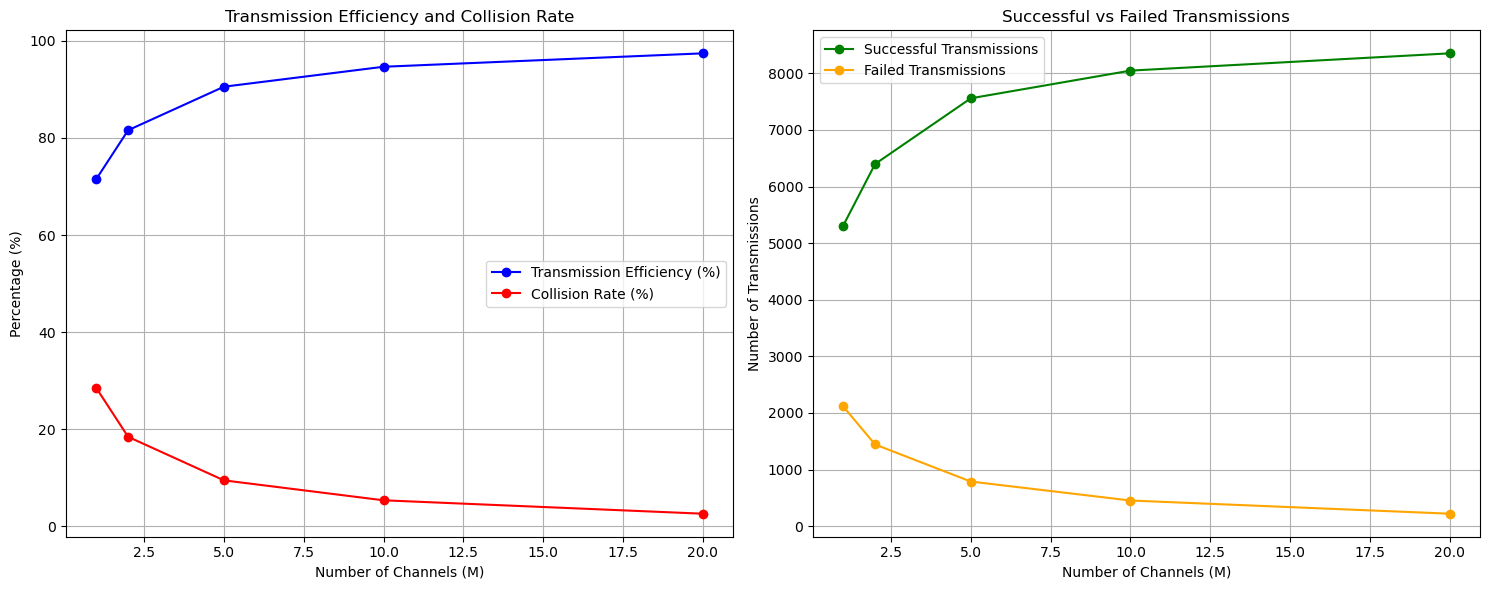

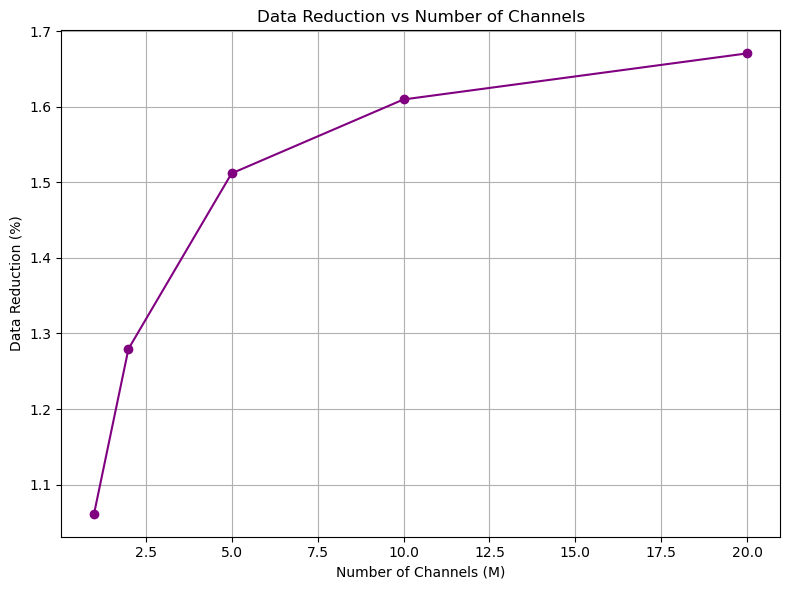


State Transition Analysis (M = 5):
--------------------------------------------------
From Warm to Hot: 2614 transmissions (34.58%)
From Hot to Warm: 2595 transmissions (34.33%)
From Cold to Warm: 543 transmissions (7.18%)
From Warm to Cold: 538 transmissions (7.12%)
From Hot to Cold: 338 transmissions (4.47%)
From Cold to Hot: 333 transmissions (4.41%)
From Warm to OutOfRange: 162 transmissions (2.14%)
From OutOfRange to Warm: 162 transmissions (2.14%)
From Hot to OutOfRange: 61 transmissions (0.81%)
From OutOfRange to Hot: 61 transmissions (0.81%)
From Cold to OutOfRange: 51 transmissions (0.67%)
From OutOfRange to Cold: 51 transmissions (0.67%)


In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

# Define the temperature state bins
# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

def multi_node_state_based_system(node_columns, temperature_data, time_steps, M):
    """
    Simulates N nodes with M available channels using state-based transmission.
    Implements a backoff mechanism for handling channel collisions.
    
    Args:
        node_columns: List of node column names
        temperature_data: DataFrame containing temperature readings for each node
        time_steps: Total simulation time steps
        M: Number of available channels
        
    Returns:
        Dictionary with transmission statistics and node states
    """
    N = len(node_columns)  # Number of nodes
    
    # Initialize node states and backoff counters
    node_states = {node: None for node in node_columns}
    node_backoff = {node: 0 for node in node_columns}
    
    # Track statistics
    successful_transmissions = 0
    failed_transmissions = 0
    state_transitions = {}
    node_transmission_times = {node: [] for node in node_columns}
    node_transmission_values = {node: [] for node in node_columns}
    
    # Track transmissions by time step for analysis
    transmissions_log = []
    
    # Process each time step
    for t in range(time_steps):
        # Track which channels are used in this time step
        channel_usage = set()
        
        # Randomly shuffle node order to avoid bias
        shuffled_nodes = list(node_columns)
        random.shuffle(shuffled_nodes)
        
        for node in shuffled_nodes:
            # Skip if node is in backoff period
            if node_backoff[node] > 0:
                node_backoff[node] -= 1
                continue
                
            # Get current temperature reading
            temp = temperature_data.iloc[t][node]
            current_state = get_state(temp)
            
            # Determine if transmission is needed based on state change
            if node_states[node] is None or current_state != node_states[node]:
                # Need to transmit - randomly choose a channel
                chosen_channel = random.randint(0, M - 1)
                
                # Check for collision
                if chosen_channel in channel_usage:
                    # Collision occurred
                    failed_transmissions += 1
                    
                    # Apply exponential backoff (more sophisticated than original)
                    # Random backoff between 1 and 2^(retry) where retry increments with each collision
                    retry_count = node_backoff.get(f"{node}_retry", 0) + 1
                    node_backoff[f"{node}_retry"] = retry_count
                    max_backoff = min(64, 2**retry_count)  # Cap at reasonable value
                    node_backoff[node] = random.randint(1, max_backoff)
                else:
                    # Successful transmission
                    channel_usage.add(chosen_channel)
                    successful_transmissions += 1
                    
                    # Record the state transition
                    transition = (node_states[node], current_state)
                    state_transitions[transition] = state_transitions.get(transition, 0) + 1
                    
                    # Update the node's state
                    node_states[node] = current_state
                    
                    # Reset retry counter on successful transmission
                    node_backoff[f"{node}_retry"] = 0
                    
                    # Record transmission details
                    node_transmission_times[node].append(t)
                    node_transmission_values[node].append(temp)
                    
                    # Log transmission for analysis
                    transmissions_log.append({
                        'timestamp': t,
                        'node': node,
                        'temperature': temp,
                        'previous_state': transition[0],
                        'current_state': transition[1],
                        'channel': chosen_channel
                    })
    
    # Calculate transmission efficiency
    total_possible_transmissions = time_steps * N
    total_attempted_transmissions = successful_transmissions + failed_transmissions
    
    transmission_efficiency = successful_transmissions / total_attempted_transmissions if total_attempted_transmissions > 0 else 0
    data_reduction = (successful_transmissions / total_possible_transmissions) * 100
    collision_rate = (failed_transmissions / total_attempted_transmissions) * 100 if total_attempted_transmissions > 0 else 0
    
    # Create DataFrame from log
    transmissions_df = pd.DataFrame(transmissions_log)
    
    # Return comprehensive results
    return {
        'successful_transmissions': successful_transmissions,
        'failed_transmissions': failed_transmissions,
        'total_attempted': total_attempted_transmissions,
        'transmission_efficiency': transmission_efficiency,
        'data_reduction': data_reduction,
        'collision_rate': collision_rate,
        'state_transitions': state_transitions,
        'node_transmission_times': node_transmission_times,
        'node_transmission_values': node_transmission_values,
        'transmissions_df': transmissions_df if not transmissions_log else pd.DataFrame(transmissions_log)
    }

def run_simulation_with_varying_M(temperature_data, node_columns, m_values):
    """
    Runs the state-based simulation for different M values
    
    Args:
        temperature_data: DataFrame containing temperature data
        node_columns: List of node column names
        m_values: List of M values to test
        
    Returns:
        Dictionary of results for each M value
    """
    time_steps = len(temperature_data)
    results = {}
    
    for M in m_values:
        print(f"Running simulation with M = {M}...")
        result = multi_node_state_based_system(
            node_columns=node_columns,
            temperature_data=temperature_data,
            time_steps=time_steps,
            M=M
        )
        results[M] = result
    
    return results

def plot_results(results, m_values):
    """
    Plots the results of the simulations
    
    Args:
        results: Dictionary of simulation results
        m_values: List of M values tested
    """
    # Extract metrics
    transmission_efficiencies = [results[M]['transmission_efficiency'] * 100 for M in m_values]
    data_reductions = [results[M]['data_reduction'] for M in m_values]
    collision_rates = [results[M]['collision_rate'] for M in m_values]
    successful_transmissions = [results[M]['successful_transmissions'] for M in m_values]
    failed_transmissions = [results[M]['failed_transmissions'] for M in m_values]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Efficiency and Collision Rate
    ax1.plot(m_values, transmission_efficiencies, 'o-', color='blue', label='Transmission Efficiency (%)')
    ax1.plot(m_values, collision_rates, 'o-', color='red', label='Collision Rate (%)')
    ax1.set_xlabel('Number of Channels (M)')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_title('Transmission Efficiency and Collision Rate')
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Successful vs Failed Transmissions
    ax2.plot(m_values, successful_transmissions, 'o-', color='green', label='Successful Transmissions')
    ax2.plot(m_values, failed_transmissions, 'o-', color='orange', label='Failed Transmissions')
    ax2.set_xlabel('Number of Channels (M)')
    ax2.set_ylabel('Number of Transmissions')
    ax2.set_title('Successful vs Failed Transmissions')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    
    # Create a third plot for data reduction
    plt.figure(figsize=(8, 6))
    plt.plot(m_values, data_reductions, 'o-', color='purple')
    plt.xlabel('Number of Channels (M)')
    plt.ylabel('Data Reduction (%)')
    plt.title('Data Reduction vs Number of Channels')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def main():
    # Load the dataset
    pivot_df = pd.read_csv("top_fifty_motes_temperatures.csv")
    pivot_df = pivot_df.apply(lambda x: x.fillna(x.mean()), axis=0)  # Fill missing values
    pivot_df = pivot_df.head(10000) 
    temperature_data = pivot_df
    #temperature_data = pd.read_csv("temp_state_2.csv").head(10000)
    print(f"Dataset loaded with shape: {temperature_data.shape}")

    # Identify time and node columns
    time_column = 'SN'
    node_columns = [col for col in temperature_data.columns if col.startswith('mote')]
    print(f"Found {len(node_columns)} node columns")
    
    # Varying M values to test
    m_values = [1, 2,  5, 10,  20]
    
    # Run simulations
    results = run_simulation_with_varying_M(
        temperature_data=temperature_data, 
        node_columns=node_columns,
        m_values=m_values
    )
    
    # Calculate the theoretical maximum transmissions if all nodes sent at every time step
    total_possible_transmissions = len(temperature_data) * len(node_columns)
    
    # Print results in a detailed table format
    print("\nResults Summary:")
    print("-" * 120)
    print(f"{'M':^5} | {'Successful':^12} | {'Failed':^12} | {'Total Attempts':^15} | {'Efficiency (%)':^15} | {'Collision Rate (%)':^18} | {'Data Reduction (%)':^18}")
    print("-" * 120)
    
    for M in m_values:
        r = results[M]
        successful = r['successful_transmissions']
        failed = r['failed_transmissions']
        total = r['total_attempted']
        efficiency = r['transmission_efficiency'] * 100
        collision_rate = r['collision_rate']
        data_reduction = r['data_reduction']
        
        print(f"{M:^5} | {successful:^12} | {failed:^12} | {total:^15} | {efficiency:^15.2f} | {collision_rate:^18.2f} | {data_reduction:^18.2f}")
    
    print("-" * 120)
    print(f"Total possible transmissions (all time steps): {total_possible_transmissions}")
    
    # Plot the results
    plot_results(results, m_values)
    
    # Analyze state transitions for a specific M (using middle value)
    middle_m = m_values[len(m_values)//2]
    state_transitions = results[middle_m]['state_transitions']
    
    print(f"\nState Transition Analysis (M = {middle_m}):")
    print("-" * 50)
    total_transitions = sum(state_transitions.values())
    
    # Filter out None transitions and sort
    valid_transitions = {k: v for k, v in state_transitions.items() if k[0] is not None}
    
    for (old_state, new_state), count in sorted(valid_transitions.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / total_transitions) * 100
        print(f"From {old_state} to {new_state}: {count} transmissions ({percentage:.2f}%)")

if __name__ == "__main__":
    main()

In [20]:
import pandas as pd
import numpy as np

# Parameters
M = 5  # Number of nodes to pull at each time step
alpha = 0.3  # Smoothing factor
initial_delta_t = 10  # Initial average interval between state changes
initial_rate = 0.1  # Initial rate of change

# Define temperature-to-state mapping
def get_state(temp):
    temp = round(temp)
    if 6 <= temp <= 16:
        return "Cold"
    elif 17 <= temp <= 24:
        return "Warm"
    elif 25 <= temp <= 34:
        return "Hot"
    else:
        return "Out of Range"

# Load dataset
df = pd.read_csv("temp_state.csv")
time_column = 'SN'
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df[time_column].values

# Initialise tracking dictionaries
last_polled_state = {node: None for node in node_columns}
last_polled_value = {node: None for node in node_columns}
last_polled_time = {node: None for node in node_columns}
avg_rate_change = {node: initial_rate for node in node_columns}
avg_state_interval = {node: initial_delta_t for node in node_columns}

# Evaluation stats
total_polls = 0
poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}

# Main scheduler loop
for t_idx, t in enumerate(time_steps):
    P = {}

    for node in node_columns:
        current_value = df.loc[t_idx, node]
        current_state = get_state(current_value)

        if last_polled_state[node] is None:
            # Bootstrap: prioritise unpolled nodes
            P[node] = 1.0
            continue

        # Estimate time since last poll
        delta_t = t - last_polled_time[node]
        delta_val = abs(current_value - last_polled_value[node])

        # Update smoothed rate of change
        rate = delta_val / delta_t if delta_t > 0 else 0
        avg_rate_change[node] = alpha * rate + (1 - alpha) * avg_rate_change[node]

        # If state has changed since last poll, update average change interval
        if current_state != last_polled_state[node]:
            avg_state_interval[node] = alpha * delta_t + (1 - alpha) * avg_state_interval[node]

        # Estimate probability of state change
        P[node] = min(1.0, (delta_t / avg_state_interval[node]) * avg_rate_change[node])

    # Select top M nodes to poll
    top_nodes = sorted(P.items(), key=lambda x: x[1], reverse=True)[:M]
    total_polls += len(top_nodes)

    for node, _ in top_nodes:
        current_value = df.loc[t_idx, node]
        current_state = get_state(current_value)

        # Count if state remained the same as last time this node was polled
        if last_polled_state[node] is not None and current_state == last_polled_state[node]:
            same_state_counts[node] += 1

        poll_counts[node] += 1

        # Update values after polling
        last_polled_state[node] = current_state
        last_polled_value[node] = current_value
        last_polled_time[node] = t

# Summary
print(f"\nTotal polling attempts: {total_polls}")
print("Polling summary per node (polled, same state count):\n")
for node in node_columns:
    print(f"{node}: polled {poll_counts[node]} times, same state {same_state_counts[node]} times")




Total polling attempts: 250000
Polling summary per node (polled, same state count):

node1: polled 21 times, same state 18 times
node2: polled 18 times, same state 16 times
node3: polled 13 times, same state 11 times
node4: polled 13 times, same state 11 times
node5: polled 16 times, same state 14 times
node6: polled 21 times, same state 18 times
node7: polled 15 times, same state 13 times
node8: polled 18 times, same state 16 times
node9: polled 13 times, same state 11 times
node10: polled 15 times, same state 13 times
node11: polled 12 times, same state 9 times
node12: polled 15 times, same state 12 times
node13: polled 33 times, same state 28 times
node14: polled 12 times, same state 9 times
node15: polled 58 times, same state 53 times
node16: polled 15 times, same state 12 times
node17: polled 23 times, same state 18 times
node18: polled 12 times, same state 9 times
node19: polled 30 times, same state 23 times
node20: polled 17 times, same state 13 times
node21: polled 2819 times,

In [31]:
import pandas as pd

# ==== Configurable Parameters ====
M = 2                 # Number of nodes to poll per time step
initial_tau = 15      # Initial polling interval (time steps)
tau_max = 500         # Maximum allowable interval (fits within ~500 steps)
growth_factor = 4    # Geometric multiplier for backoff


# ==== Define the binning function ====
def get_state(temp):
    temp = round(temp)
    if 6 <= temp <= 16:
        return "Cold"
    elif 17 <= temp <= 24:
        return "Warm"
    elif 25 <= temp <= 34:
        return "Hot"
    else:
        return "Out of Range"

# ==== Load the dataset ====
df = pd.read_csv("temp_state.csv")
time_column = 'SN'
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df[time_column].values
num_nodes = len(node_columns)

# ==== Initialise tracking ====
last_state = {node: None for node in node_columns}
next_poll_time = {node: 0 for node in node_columns}
tau = {node: initial_tau for node in node_columns}
poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}

poll_log = []
rr_index = 0  # round-robin index

# ==== Main loop over time ====
for t_idx, t in enumerate(time_steps):
    polled = 0
    nodes_checked = 0

    while polled < M and nodes_checked < num_nodes:
        node = node_columns[rr_index % num_nodes]
        rr_index += 1
        nodes_checked += 1

        # Poll if it's due
        if t >= next_poll_time[node]:
            value = df.loc[t_idx, node]
            state = get_state(value)

            # Check if state has changed
            if last_state[node] is not None:
                if state == last_state[node]:
                    same_state_counts[node] += 1
                    tau[node] = min(tau[node] * growth_factor, tau_max)
                else:
                    tau[node] = initial_tau  # reset on change
            # Update state tracking
            last_state[node] = state
            next_poll_time[node] = t + tau[node]
            poll_counts[node] += 1
            polled += 1
            poll_log.append((t, node, state, tau[node]))

# ==== Output summary ====
summary = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns],
    'Final_Interval': [tau[n] for n in node_columns]
})

print("\n==== Geometric Backoff Polling Summary ====\n")
print(summary)

# Optionally save the summary to CSV
summary.to_csv("geometric_backoff_polling_summary.csv", index=False)
print("\nSummary saved to 'geometric_backoff_polling_summary.csv'")




==== Geometric Backoff Polling Summary ====

      Node  Polled  Same_State  Final_Interval
0    node1     637         369             240
1    node2     637         369             240
2    node3     637         369             240
3    node4     634         368             240
4    node5     637         369             240
5    node6     634         368             240
6    node7     636         369             240
7    node8     638         370              60
8    node9     638         370              60
9   node10     636         369             240
10  node11     708         375              15
11  node12     708         376              60
12  node13     708         376              60
13  node14     708         376              60
14  node15     708         376              60
15  node16     708         376              60
16  node17     708         376              60
17  node18     708         376              60
18  node19     707         375              15
19  node20    

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict

# ==== Configuration Parameters ====
rate_bins = [0.0, 0.3, 0.6, 1.0]  # Define rate categories (low, medium, high)
bin_labels = ["low", "medium", "high"]
M = 2  # Max nodes to poll at a time step

# ==== Define state binning ====
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return "Cold"
    elif 17 <= temp <= 23:
        return "Warm"
    elif 24 <= temp <= 32:
        return "Hot"
    else:
        return "OutOfRange"

def get_rate_bin(rate):
    for i in range(len(rate_bins) - 1):
        if rate_bins[i] <= rate < rate_bins[i+1]:
            return bin_labels[i]
    return bin_labels[-1]

# ==== Load dataset ====
df = pd.read_csv("synthetic_scenario_30_nodes_2.csv")
time_column = 'SN'
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df[time_column].values
num_steps = len(time_steps)
half_index = num_steps // 2

# ==== Phase 1: Learning (first half of the data) ====
state_duration_data = defaultdict(list)  # {(state, rate_bin): [durations]}

# For each node, track entry time, previous state and value
entry_time = {}
prev_state = {}
prev_value = {}

for t_idx in range(1, half_index):
    t = time_steps[t_idx]
    t_prev = time_steps[t_idx - 1]

    for node in node_columns:
        current_value = df.loc[t_idx, node]
        current_state = get_state(current_value)
        previous_value = df.loc[t_idx - 1, node]
        rate = abs(current_value - previous_value) / (t - t_prev)
        rate_bin = get_rate_bin(rate)

        if node not in entry_time:
            entry_time[node] = t_prev
            prev_state[node] = get_state(previous_value)
            prev_value[node] = previous_value
            continue

        # Detect state change
        if current_state != prev_state[node]:
            duration = t - entry_time[node]
            state_duration_data[(prev_state[node], rate_bin)].append(duration)
            entry_time[node] = t
            prev_state[node] = current_state
            prev_value[node] = current_value

# Compute average durations
avg_durations = {}
for key, durations in state_duration_data.items():
    avg_durations[key] = np.mean(durations)

print("\n==== Learned Average Durations by (State, Rate Bin) ====\n")
for key, val in avg_durations.items():
    print(f"{key}: {val:.2f} steps")

# ==== Phase 2: Application (second half of the data) ====
# Tracking
last_poll_time = {node: None for node in node_columns}
last_poll_state = {node: None for node in node_columns}
last_poll_value = {node: None for node in node_columns}
next_poll_time = {node: half_index for node in node_columns}  # all ready at first application step

poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}

poll_log = []

# Main polling loop for second half
for t_idx in range(half_index, num_steps):
    t = time_steps[t_idx]
    due_nodes = [node for node in node_columns if t >= next_poll_time[node]]
    polled_nodes = due_nodes[:M]

    for node in polled_nodes:
        current_value = df.loc[t_idx, node]
        current_state = get_state(current_value)

        # Estimate rate of change using last polled value
        if last_poll_value[node] is not None:
            time_diff = t - last_poll_time[node]
            rate = abs(current_value - last_poll_value[node]) / time_diff if time_diff > 0 else 0
            rate_bin = get_rate_bin(rate)
        else:
            rate_bin = "medium"  # default if not known

        poll_counts[node] += 1
        if last_poll_state[node] == current_state:
            same_state_counts[node] += 1

        # Schedule next poll using learned duration
        key = (current_state, rate_bin)
        predicted_duration = avg_durations.get(key, 30)  # default fallback
        next_poll_time[node] = t + predicted_duration

        # Update state
        last_poll_state[node] = current_state
        last_poll_value[node] = current_value
        last_poll_time[node] = t

        poll_log.append((t, node, current_state, rate_bin, predicted_duration))

# ==== Summary ====
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns]
})

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df)

# Save summary
summary_df.to_csv("learn_apply_polling_summary.csv", index=False)
print("\nSaved polling summary to 'learn_apply_polling_summary.csv'")



==== Learned Average Durations by (State, Rate Bin) ====

('Warm', 'high'): 443.57 steps
('Warm', 'low'): 525.20 steps
('Cold', 'high'): 1.04 steps
('Cold', 'low'): 1.03 steps
('Cold', 'medium'): 1.05 steps
('Warm', 'medium'): 461.37 steps

==== Polling Summary for Application Phase ====

      Node  Polled  Same_State
0    node1      48          47
1    node2      48          47
2    node3      48          47
3    node4      48          47
4    node5      48          47
5    node6      48          47
6    node7      48          47
7    node8      48          47
8    node9      48          47
9   node10      48          47
10  node11      48          47
11  node12      48          47
12  node13      48          47
13  node14      48          47
14  node15      48          47
15  node16      48          47
16  node17      48          47
17  node18      48          47
18  node19      48          47
19  node20      48          47
20  node21      48          47
21  node22      48         

In [35]:
import pandas as pd
import numpy as np
from collections import defaultdict

# ==== Configuration ====
M = 2  # Max nodes to sample per time step
time_column = 'SN'
state_labels = ['Cold', 'Warm', 'Hot']

# ==== Define state classification ====
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 32:
        return 'Hot'
    else:
        return 'OutOfRange'

# ==== Load dataset ====
df = pd.read_csv("temp_state.csv")
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df[time_column].values
num_nodes = len(node_columns)

# ==== Initialise tracking ====
last_state = {node: None for node in node_columns}
state_entry_time = {node: None for node in node_columns}
state_durations = defaultdict(list)  # state: list of durations

# Round-robin index
rr_index = 0

# ==== Training Loop ====
for t_idx in range(len(time_steps)):
    t = time_steps[t_idx]
    sampled = 0
    nodes_checked = 0

    while sampled < M and nodes_checked < num_nodes:
        node = node_columns[rr_index % num_nodes]
        rr_index += 1
        nodes_checked += 1

        # Get current state
        temp = df.loc[t_idx, node]
        state = get_state(temp)

        if state == 'OutOfRange':
            continue

        if last_state[node] is None:
            last_state[node] = state
            state_entry_time[node] = t
            continue

        # State changed
        if state != last_state[node]:
            duration = t - state_entry_time[node]
            state_durations[last_state[node]].append(duration)

            # Update tracking
            last_state[node] = state
            state_entry_time[node] = t

        sampled += 1

# ==== Output Summary ====
print("\n==== Average Time Spent in Each State ====\n")
for state in state_labels:
    durations = state_durations[state]
    if durations:
        mean_dur = np.mean(durations)
        median_dur = np.median(durations)
        print(f"{state}: Mean = {mean_dur:.2f}, Median = {median_dur:.2f}, Count = {len(durations)}")
    else:
        print(f"{state}: No transitions observed.")

# Optionally: Save results
summary_df = pd.DataFrame({
    'State': state_labels,
    'Mean_Duration': [np.mean(state_durations[s]) if state_durations[s] else None for s in state_labels],
    'Median_Duration': [np.median(state_durations[s]) if state_durations[s] else None for s in state_labels],
    'Count': [len(state_durations[s]) for s in state_labels]
})
summary_df.to_csv("state_duration_summary.csv", index=False)
print("\nSummary saved to 'state_duration_summary.csv'")



==== Average Time Spent in Each State ====

Cold: Mean = 146.61, Median = 150.00, Count = 3910
Warm: Mean = 44.86, Median = 45.00, Count = 7840
Hot: Mean = 146.57, Median = 150.00, Count = 3920

Summary saved to 'state_duration_summary.csv'


In [37]:
import pandas as pd
import numpy as np
from collections import defaultdict

# ==== Configuration ====
M = 2  # Max nodes to poll per timestep
time_column = 'SN'
state_labels = ['Cold', 'Warm', 'Hot']

def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 32:
        return 'Hot'
    else:
        return 'OutOfRange'

# ==== Load dataset ====
df = pd.read_csv("temp_state.csv")
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df[time_column].values
num_nodes = len(node_columns)
half_index = len(time_steps) // 2

# ==== Training Phase ====
last_state = {node: None for node in node_columns}
state_entry_time = {node: None for node in node_columns}
state_durations = defaultdict(list)
rr_index = 0

for t_idx in range(half_index):
    t = time_steps[t_idx]
    sampled = 0
    nodes_checked = 0

    while sampled < M and nodes_checked < num_nodes:
        node = node_columns[rr_index % num_nodes]
        rr_index += 1
        nodes_checked += 1

        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue

        if last_state[node] is None:
            last_state[node] = state
            state_entry_time[node] = t
            continue

        if state != last_state[node]:
            duration = t - state_entry_time[node]
            state_durations[last_state[node]].append(duration)
            last_state[node] = state
            state_entry_time[node] = t

        sampled += 1

# ==== Compute Mean Duration Per State ====
mean_duration = {}
for state in state_labels:
    durations = state_durations[state]
    mean_duration[state] = np.mean(durations) if durations else 30  # default fallback

print("\n==== Learned Mean Durations per State ====")
for state in state_labels:
    print(f"{state}: {mean_duration[state]:.2f} steps")

# ==== Application Phase ====
poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
last_known_state = {node: None for node in node_columns}
last_polled_time = {node: half_index for node in node_columns}
next_poll_time = {node: half_index for node in node_columns}
poll_log = []

for t_idx in range(half_index, len(time_steps)):
    t = time_steps[t_idx]
    due_nodes = [node for node in node_columns if t >= next_poll_time[node]]
    polled_nodes = due_nodes[:M]

    for node in polled_nodes:
        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue

        poll_counts[node] += 1
        if last_known_state[node] is not None and state == last_known_state[node]:
            same_state_counts[node] += 1

        duration = mean_duration.get(state, 30)
        next_poll_time[node] = t + duration
        last_known_state[node] = state
        last_polled_time[node] = t
        poll_log.append((t, node, state, duration))

# ==== Summary Output ====
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns],
})

summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df)

# Save outputs
summary_df.to_csv("application_phase_summary.csv", index=False)
pd.DataFrame(poll_log, columns=["Time", "Node", "State", "Next_Interval"]).to_csv("application_phase_polling.csv", index=False)
print("\nSaved:")
print("- Summary to 'application_phase_summary.csv'")
print("- Poll log to 'application_phase_polling.csv'")



==== Learned Mean Durations per State ====
Cold: 146.58 steps
Warm: 44.83 steps
Hot: 146.60 steps

==== Polling Summary for Application Phase ====

      Node  Polled  Same_State  State_Changed
0    node1     212          63            149
1    node2     212          63            149
2    node3     213          64            149
3    node4     214          64            150
4    node5     213          64            149
5    node6     211          63            148
6    node7     214          64            150
7    node8     214          64            150
8    node9     214          64            150
9   node10     215          65            150
10  node11     241          18            223
11  node12     241          18            223
12  node13     239          18            221
13  node14     239          18            221
14  node15     239          18            221
15  node16     235          18            217
16  node17     235          18            217
17  node18     236     

In [38]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# ==== Configuration ====
M = 2  # Number of nodes to poll per timestep
time_column = 'SN'  # Time column in your CSV
state_labels = ['Cold', 'Warm', 'Hot']
convergence_threshold = 6.0
rolling_window_size = 5
min_samples_to_check = 5

# ==== Load your dataset ====
df = pd.read_csv("temp_state.csv")  # <-- Make sure the CSV file is in the same directory
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df[time_column].values

# ==== State binning function ====
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 32:
        return 'Hot'
    else:
        return 'OutOfRange'

# ==== Training Phase with Early Convergence ====
last_state = {node: None for node in node_columns}
state_entry_time = {node: None for node in node_columns}
state_durations = defaultdict(list)
rolling_means = {state: deque(maxlen=rolling_window_size) for state in state_labels}
converged = {state: False for state in state_labels}

rr_index = 0
t_idx = 0
training_end_index = len(time_steps)  # Fallback in case no convergence

while t_idx < len(time_steps):
    t = time_steps[t_idx]
    sampled = 0
    nodes_checked = 0

    while sampled < M and nodes_checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        nodes_checked += 1

        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue

        if last_state[node] is None:
            last_state[node] = state
            state_entry_time[node] = t
            continue

        if state != last_state[node]:
            duration = t - state_entry_time[node]
            state_durations[last_state[node]].append(duration)

            # Check for convergence
            if len(state_durations[last_state[node]]) >= min_samples_to_check:
                mean_dur = np.mean(state_durations[last_state[node]])
                rolling_means[last_state[node]].append(mean_dur)
                if len(rolling_means[last_state[node]]) == rolling_window_size:
                    std = np.std(rolling_means[last_state[node]])
                    if std < convergence_threshold:
                        converged[last_state[node]] = True

            last_state[node] = state
            state_entry_time[node] = t

        sampled += 1

    if all(converged.values()):
        training_end_index = t_idx
        print(f"\nConvergence achieved at timestep {t}")
        break

    t_idx += 1

# ==== Compute mean duration per state ====
mean_duration = {
    state: np.mean(state_durations[state]) if state_durations[state] else 30
    for state in state_labels
}

print("\nMean durations learned per state:")
for state, dur in mean_duration.items():
    print(f"{state}: {dur:.2f}")

# ==== Application Phase ====
poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
last_known_state = {node: None for node in node_columns}
next_poll_time = {node: training_end_index for node in node_columns}

poll_log = []

for t_idx in range(training_end_index, len(time_steps)):
    t = time_steps[t_idx]
    due_nodes = [node for node in node_columns if t >= next_poll_time[node]]
    polled_nodes = due_nodes[:M]

    for node in polled_nodes:
        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue

        poll_counts[node] += 1
        if last_known_state[node] is not None and state == last_known_state[node]:
            same_state_counts[node] += 1

        duration = mean_duration[state]
        next_poll_time[node] = t + duration
        last_known_state[node] = state

        poll_log.append((t, node, state, duration))

# ==== Summary Output ====
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns],
})
summary_df['State_Changed'] = summary_df['Polled'] - summary_df['Same_State']

print("\n==== Polling Summary (Application Phase) ====\n")
print(summary_df)

# Optional: Save to file
summary_df.to_csv("application_phase_summary.csv", index=False)
pd.DataFrame(poll_log, columns=["Time", "Node", "State", "Next_Interval"]).to_csv("application_phase_polling.csv", index=False)



Convergence achieved at timestep 299

Mean durations learned per state:
Cold: 111.67
Warm: 39.00
Hot: 155.00

==== Polling Summary (Application Phase) ====

      Node  Polled  Same_State  State_Changed
0    node1     497         198            299
1    node2     497         198            299
2    node3     497         198            299
3    node4     497         198            299
4    node5     497         198            299
5    node6     498         198            300
6    node7     498         198            300
7    node8     498         198            300
8    node9     503         198            305
9   node10     499         197            302
10  node11     440         124            316
11  node12     440         124            316
12  node13     440         124            316
13  node14     440         124            316
14  node15     440         124            316
15  node16     440         124            316
16  node17     440         124            316
17  node18    

In [39]:
import pandas as pd

# ==== Load your dataset ====
df = pd.read_csv("temp_state.csv")  # Replace with your path if needed
node_columns = [col for col in df.columns if col.startswith('node')]
time_steps = df['SN'].values
num_nodes = len(node_columns)

# ==== Configuration ====
M = 2  # Number of nodes to poll per timestep

# ==== Define the state mapping function ====
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 32:
        return 'Hot'
    else:
        return 'OutOfRange'

# ==== Tracking structures ====
poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
last_seen_state = {node: None for node in node_columns}

rr_index = 0  # round-robin index

# ==== Round-robin polling loop ====
for t_idx in range(len(time_steps)):
    t = time_steps[t_idx]
    sampled = 0
    nodes_checked = 0

    while sampled < M and nodes_checked < num_nodes:
        node = node_columns[rr_index % num_nodes]
        rr_index += 1
        nodes_checked += 1

        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue

        poll_counts[node] += 1
        if last_seen_state[node] is not None:
            if state == last_seen_state[node]:
                same_state_counts[node] += 1
        last_seen_state[node] = state
        sampled += 1

# ==== Create result summary ====
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns]
})
summary_df['State_Changed'] = summary_df['Polled'] - summary_df['Same_State']

# ==== Print and save ====
print("\n==== Round-Robin Polling Summary ====\n")
print(summary_df)

summary_df.to_csv("round_robin_baseline_summary.csv", index=False)



==== Round-Robin Polling Summary ====

      Node  Polled  Same_State  State_Changed
0    node1    3334        2933            401
1    node2    3334        2933            401
2    node3    3334        2933            401
3    node4    3334        2933            401
4    node5    3334        2933            401
5    node6    3334        2933            401
6    node7    3334        2933            401
7    node8    3334        2933            401
8    node9    3334        2933            401
9   node10    3334        2933            401
10  node11    3333        2832            501
11  node12    3333        2832            501
12  node13    3333        2832            501
13  node14    3333        2832            501
14  node15    3333        2832            501
15  node16    3333        2832            501
16  node17    3333        2832            501
17  node18    3333        2832            501
18  node19    3333        2832            501
19  node20    3333        2832          

In [43]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIGURATION ===
M = 2  # Number of nodes to poll at each timestep
time_column = 'SN'
state_labels = ['Cold', 'Warm', 'Hot']
convergence_threshold = 6.0  # Std. dev. threshold to detect convergence
rolling_window_size = 5
min_samples_to_check = 5

# === Load dataset ===
df = pd.read_csv("temp_state.csv")  # Make sure this file is in the same folder
node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df[time_column].values

# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 32:
        return 'Hot'
    return 'OutOfRange'

# === Initialise tracking structures ===
last_state = {node: None for node in node_columns}
state_entry_time = {node: None for node in node_columns}
state_durations = defaultdict(lambda: defaultdict(list))
rolling_means = defaultdict(lambda: defaultdict(lambda: deque(maxlen=rolling_window_size)))
converged = defaultdict(lambda: defaultdict(lambda: False))
avg_duration = defaultdict(dict)

poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
last_known_state = {node: None for node in node_columns}
last_polled_time = {node: 0 for node in node_columns}
next_poll_time = {node: 0 for node in node_columns}

poll_log = []
rr_index = 0

# === Hybrid Polling Loop ===
for t_idx in range(len(time_steps)):
    t = time_steps[t_idx]
    sampled_nodes = set()
    due_nodes = []

    # Step 1: Find converged nodes due for polling
    for node in node_columns:
        state = last_known_state[node]
        if state and converged[node][state] and t >= next_poll_time[node]:
            due_nodes.append((node, avg_duration[node].get(state, 30)))

    due_nodes.sort(key=lambda x: x[1])  # Sort by expected wait duration

    # Step 2: Poll converged nodes that are due
    for node, _ in due_nodes:
        if len(sampled_nodes) >= M:
            break
        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue
        poll_counts[node] += 1
        if last_known_state[node] == state:
            same_state_counts[node] += 1

        last_known_state[node] = state
        last_polled_time[node] = t
        next_poll_time[node] = t + avg_duration[node].get(state, 30)
        poll_log.append((t, node, state, avg_duration[node].get(state, 30)))
        sampled_nodes.add(node)

    # Step 3: Round-robin sampling for unconverged nodes
    nodes_checked = 0
    while len(sampled_nodes) < M and nodes_checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        nodes_checked += 1
        if node in sampled_nodes:
            continue

        temp = df.loc[t_idx, node]
        state = get_state(temp)
        if state == 'OutOfRange':
            continue

        poll_counts[node] += 1
        if last_known_state[node] == state:
            same_state_counts[node] += 1

        # Training: update state durations and check convergence
        if last_state[node] is None:
            last_state[node] = state
            state_entry_time[node] = t
        elif state != last_state[node]:
            duration = t - state_entry_time[node]
            prev_state = last_state[node]
            state_durations[node][prev_state].append(duration)

            if len(state_durations[node][prev_state]) >= min_samples_to_check:
                mean_val = np.mean(state_durations[node][prev_state])
                rolling_means[node][prev_state].append(mean_val)
                if len(rolling_means[node][prev_state]) == rolling_window_size:
                    std = np.std(rolling_means[node][prev_state])
                    if std < convergence_threshold:
                        converged[node][prev_state] = True
                        avg_duration[node][prev_state] = mean_val

            last_state[node] = state
            state_entry_time[node] = t

        last_known_state[node] = state
        last_polled_time[node] = t
        poll_log.append((t, node, state, avg_duration[node].get(state, 30)))
        sampled_nodes.add(node)

# === Summary Output ===
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns],
})
summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]

# === Print final results ===
print("\n==== Polling Summary (Application Phase) ====\n")
print(summary_df.to_string(index=False))

# === Save Outputs ===
summary_df.to_csv("hybrid_polling_summary.csv", index=False)
pd.DataFrame(poll_log, columns=["Time", "Node", "State", "Next_Interval"]).to_csv("hybrid_polling_log.csv", index=False)

print("\n✅ Results saved to:")
print(" - hybrid_polling_summary.csv")
print(" - hybrid_polling_log.csv")



==== Polling Summary (Application Phase) ====

  Node  Polled  Same_State  State_Changed
 node1    3219        2818            401
 node2    3220        2817            403
 node3    3214        2813            401
 node4    3210        2807            403
 node5    3223        2822            401
 node6    3222        2821            401
 node7    3219        2818            401
 node8    3225        2822            403
 node9    3220        2819            401
node10    3223        2822            401
node11    3304        2803            501
node12    3315        2814            501
node13    3309        2806            503
node14    3310        2809            501
node15    3319        2814            505
node16    3309        2808            501
node17    3309        2806            503
node18    3317        2814            503
node19    3314        2813            501
node20    3305        2804            501
node21    3467        2797            670
node22    3481        2807  

In [44]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIGURATION ===
min_samples_required = 20        # Minimum number of rate samples before checking for convergence
alpha = 0.2                      # Smoothing factor for EWMA
rolling_window_size = 5          # Number of samples used to compute rolling std
convergence_std_threshold = 0.05 # Convergence threshold for smoothed rate

# === LOAD LOCAL DATA ===
df = pd.read_csv("temp_state.csv")  # CSV file must be in the same folder
node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df['SN'].values        # Assumes 'SN' is the time column

# === STATE BINNING FUNCTION ===
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 32:
        return 'Hot'
    return 'OutOfRange'

# === INITIALISATION ===
last_value = {node: None for node in node_columns}
last_time = {node: None for node in node_columns}
rate_estimates = defaultdict(list)                       # node → list of raw rate estimates
smoothed_rate = {node: None for node in node_columns}    # node → current smoothed rate
smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))  # for std tracking
converged_nodes = set()                                  # nodes whose rates are stable

# Round-robin setup
M = 2                      # Number of nodes sampled per time step
rr_index = 0
poll_log = []              # Save (time, node, value, raw rate, smoothed rate)

# === MAIN LOOP: ROUND-ROBIN SAMPLING TO ESTIMATE RATE ===
for t_idx in range(len(time_steps)):
    t = time_steps[t_idx]
    sampled = 0
    checked = 0

    while sampled < M and checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        checked += 1

        temp = df.loc[t_idx, node]
        if temp < 0 or temp > 100:
            continue  # skip out-of-range values

        if node in converged_nodes:
            continue  # skip node if already converged

        # First sample: store and skip rate calculation
        if last_value[node] is None:
            last_value[node] = temp
            last_time[node] = t
            continue

        dt = t - last_time[node]
        dz = temp - last_value[node]

        if dt == 0:
            continue  # avoid division by zero

        # Calculate rate and update
        rate = dz / dt
        rate_estimates[node].append(rate)

        # Apply EWMA smoothing
        if smoothed_rate[node] is None:
            smoothed_rate[node] = rate
        else:
            smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]

        smoothed_history[node].append(smoothed_rate[node])
        last_value[node] = temp
        last_time[node] = t
        poll_log.append((t, node, temp, rate, smoothed_rate[node]))

        # Check convergence
        if len(rate_estimates[node]) >= min_samples_required:
            if len(smoothed_history[node]) == rolling_window_size:
                std = np.std(smoothed_history[node])
                if std < convergence_std_threshold:
                    converged_nodes.add(node)

        sampled += 1

# === SUMMARY OUTPUT ===
summary_data = []
for node in node_columns:
    n_samples = len(rate_estimates[node])
    status = "Converged" if node in converged_nodes else "Not Converged"
    mean_rate = np.mean(rate_estimates[node]) if rate_estimates[node] else None
    summary_data.append((node, n_samples, mean_rate, status))

summary_df = pd.DataFrame(summary_data, columns=["Node", "Samples", "Mean Rate", "Status"])

print("\n==== Phase One: Rate Estimation Summary ====\n")
print(summary_df.to_string(index=False))

# === SAVE RESULTS ===
summary_df.to_csv("phase1_rate_summary.csv", index=False)
pd.DataFrame(poll_log, columns=["Time", "Node", "Value", "Raw_Rate", "Smoothed_Rate"]).to_csv("phase1_poll_log.csv", index=False)

print("\n✅ Results saved to:")
print(" - phase1_rate_summary.csv")
print(" - phase1_poll_log.csv")



==== Phase One: Rate Estimation Summary ====

  Node  Samples  Mean Rate    Status
 node1       20  -0.015165 Converged
 node2       20  -0.014232 Converged
 node3       20  -0.007972 Converged
 node4       20  -0.007432 Converged
 node5       20  -0.005401 Converged
 node6       20  -0.009627 Converged
 node7       20  -0.011256 Converged
 node8       20  -0.010883 Converged
 node9       20  -0.011243 Converged
node10       20  -0.011269 Converged
node11       20  -0.029329 Converged
node12       20  -0.032328 Converged
node13       20  -0.025874 Converged
node14       20  -0.027577 Converged
node15       20  -0.028404 Converged
node16       20  -0.029744 Converged
node17       20  -0.031912 Converged
node18       20  -0.030410 Converged
node19       20  -0.028434 Converged
node20       20  -0.032052 Converged
node21       20  -0.001615 Converged
node22       21   0.006365 Converged
node23       22   0.005746 Converged
node24       20   0.000053 Converged
node25       21   0.007181 C

In [52]:
import pandas as pd
import numpy as np

# === Load previously converged rates from Phase One ===
rate_summary = pd.read_csv("phase1_rate_summary.csv")
poll_log_df = pd.read_csv("phase1_poll_log.csv")
df = pd.read_csv("temp_state_2.csv")

node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df['SN'].values
df.set_index('SN', inplace=True)

# === STATE CLASSIFICATION ===
def get_state(temp):
    temp = round(temp)
    if 8 <= temp <= 15:
        return 'Cold'
    elif 16 <= temp <= 22:
        return 'Warm'
    elif 23 <= temp <= 32:
        return 'Hot'
    return 'OutOfRange'

# === INIT FROM CONVERGED RESULTS ===
converged_nodes = rate_summary[rate_summary['Status'] == 'Converged']['Node'].values
rate_map = dict(zip(rate_summary['Node'], rate_summary['Mean Rate']))

last_known_value = {}
last_known_state = {}
last_update_time = {}

poll_counts = {node: 0 for node in converged_nodes}
same_state_counts = {node: 0 for node in converged_nodes}
poll_log = []

# Initialise with the last value seen during Phase One
last_poll = poll_log_df.groupby("Node").last().reset_index()
for _, row in last_poll.iterrows():
    node = row["Node"]
    last_known_value[node] = row["Value"]
    last_update_time[node] = row["Time"]
    last_known_state[node] = get_state(row["Value"])

# === Main Application Loop ===
for t in df.index:
    polled_this_step = []

    for node in converged_nodes:
        # Predict current value using: z_pred = z_last + r * (t - t_last)
        if node not in last_known_value:
            continue

        dt = t - last_update_time[node]
        rate = rate_map[node]
        z_pred = last_known_value[node] + rate * dt
        predicted_state = get_state(z_pred)

        if predicted_state != last_known_state[node]:
            # Poll the node
            actual_value = df.loc[t, node]
            actual_state = get_state(actual_value)
            if actual_state == 'OutOfRange':
                continue

            poll_counts[node] += 1
            if actual_state == last_known_state[node]:
                same_state_counts[node] += 1

            # Update knowledge
            last_known_value[node] = actual_value
            last_known_state[node] = actual_state
            last_update_time[node] = t

            poll_log.append((t, node, actual_value, actual_state, z_pred, predicted_state))

# === Summary Output ===
summary_df = pd.DataFrame({
    'Node': converged_nodes,
    'Polled': [poll_counts[n] for n in converged_nodes],
    'Same_State': [same_state_counts[n] for n in converged_nodes]
})
summary_df['State_Changed'] = summary_df['Polled'] - summary_df['Same_State']

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df.to_string(index=False))

# === Save outputs ===
summary_df.to_csv("phase2_polling_summary.csv", index=False)
pd.DataFrame(poll_log, columns=["Time", "Node", "Actual_Value", "Actual_State", "Pred_Value", "Pred_State"]).to_csv("phase2_poll_log.csv", index=False)

print("\n✅ Phase Two results saved to:")
print(" - phase2_polling_summary.csv")
print(" - phase2_poll_log.csv")



==== Polling Summary for Application Phase ====

  Node  Polled  Same_State  State_Changed
 node1     144          71             73
 node2     107          95             12
 node3      97          30             67
 node4      81          26             55
 node5      67          28             39
 node6     104          19             85
 node7     123          34             89
 node8     116          40             76
 node9     119          39             80
node10     119          33             86
node11     272         157            115
node12     372         115            257
node13     282         125            157
node14     269         165            104
node15     257         150            107
node16     275         154            121
node17     352         131            221
node18     328         132            196
node19     266         164            102
node20     359         115            244
node21      22           8             14
node22      78          28

In [64]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIGURATION ===
alpha = 0.9 # EWMA smoothing factor
rolling_window_size = 15
convergence_std_threshold = 0.05
min_samples_required = 40  # Can be adjusted to test effect on convergence
M = 3  # Number of nodes to sample per time step

# === Load dataset ===
df = pd.read_csv("temp_state_2.csv")  # Make sure this file is in the same folder
node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df['SN'].values
df.set_index('SN', inplace=True)

# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

# === Phase One: Training & Rate Estimation ===
last_value = {node: None for node in node_columns}
last_time = {node: None for node in node_columns}
rate_estimates = defaultdict(list)
smoothed_rate = {node: None for node in node_columns}
smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
converged_nodes = set()

poll_log_phase1 = []
rr_index = 0
training_end_idx = 0

for t_idx, t in enumerate(time_steps):
    sampled = 0
    checked = 0

    while sampled < M and checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        checked += 1

        temp = df.loc[t, node]
        if temp < 0 or temp > 100 or node in converged_nodes:
            continue

        if last_value[node] is None:
            last_value[node] = temp
            last_time[node] = t
            continue

        dt = t - last_time[node]
        dz = temp - last_value[node]
        if dt == 0:
            continue

        rate = dz / dt
        rate_estimates[node].append(rate)

        # Smooth rate
        if smoothed_rate[node] is None:
            smoothed_rate[node] = rate
        else:
            smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]

        smoothed_history[node].append(smoothed_rate[node])
        last_value[node] = temp
        last_time[node] = t
        poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))

        if len(rate_estimates[node]) >= min_samples_required:
            if len(smoothed_history[node]) == rolling_window_size:
                std = np.std(smoothed_history[node])
                if std < convergence_std_threshold:
                    converged_nodes.add(node)

        sampled += 1

    if len(converged_nodes) == len(node_columns):
        training_end_idx = t_idx
        break

# === Transition to Phase Two ===
last_known_value = last_value.copy()
last_known_state = {node: get_state(val) for node, val in last_value.items()}
last_update_time = last_time.copy()
rate_map = {node: np.mean(rate_estimates[node]) for node in node_columns}

poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
poll_log_phase2 = []

for t in time_steps[training_end_idx + 1:]:
    for node in node_columns:
        if node not in last_known_value or last_known_value[node] is None:
            continue

        dt = t - last_update_time[node]
        rate = rate_map[node]
        z_pred = last_known_value[node] + rate * dt
        predicted_state = get_state(z_pred)

        if predicted_state != last_known_state[node]:
            actual_value = df.loc[t, node]
            actual_state = get_state(actual_value)
            if actual_state == 'OutOfRange':
                continue

            poll_counts[node] += 1
            if actual_state == last_known_state[node]:
                same_state_counts[node] += 1

            last_known_value[node] = actual_value
            last_known_state[node] = actual_state
            last_update_time[node] = t

            poll_log_phase2.append((t, node, actual_value, actual_state, z_pred, predicted_state))

# === Summary Output ===
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns]
})
summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]

# === Display and Save ===
print("\n==== Phase One: Rate Estimation Summary ====")
for node in node_columns:
    sample_count = len(rate_estimates[node])
    mean_rate = np.mean(rate_estimates[node]) if sample_count else 0
    status = "Converged" if node in converged_nodes else "Not Converged"
    print(f"{node:>6}: Samples={sample_count:3}  Mean Rate={mean_rate: .5f}  Status={status}")

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df.to_string(index=False))

# Save CSVs
pd.DataFrame(poll_log_phase1, columns=["Time", "Node", "Value", "Raw_Rate", "Smoothed_Rate"]).to_csv("phase1_poll_log.csv", index=False)
summary_df.to_csv("phase2_polling_summary.csv", index=False)
pd.DataFrame(poll_log_phase2, columns=["Time", "Node", "Actual_Value", "Actual_State", "Pred_Value", "Pred_State"]).to_csv("phase2_poll_log.csv", index=False)

print("\n✅ Results saved to:")
print(" - phase1_poll_log.csv")
print(" - phase2_polling_summary.csv")
print(" - phase2_poll_log.csv")



==== Phase One: Rate Estimation Summary ====
 node1: Samples=7629  Mean Rate= 0.00096  Status=Converged
 node2: Samples= 40  Mean Rate=-0.02401  Status=Converged
 node3: Samples=3021  Mean Rate=-0.00044  Status=Converged
 node4: Samples= 40  Mean Rate=-0.02126  Status=Converged
 node5: Samples= 40  Mean Rate=-0.02354  Status=Converged
 node6: Samples= 40  Mean Rate=-0.02661  Status=Converged
 node7: Samples= 40  Mean Rate=-0.02252  Status=Converged
 node8: Samples= 40  Mean Rate=-0.02090  Status=Converged
 node9: Samples= 40  Mean Rate=-0.02248  Status=Converged
node10: Samples= 40  Mean Rate=-0.02260  Status=Converged
node11: Samples= 40  Mean Rate= 0.01488  Status=Converged
node12: Samples= 40  Mean Rate= 0.01726  Status=Converged
node13: Samples= 40  Mean Rate= 0.01593  Status=Converged
node14: Samples= 40  Mean Rate= 0.01727  Status=Converged
node15: Samples= 40  Mean Rate= 0.01590  Status=Converged
node16: Samples= 40  Mean Rate= 0.01642  Status=Converged
node17: Samples= 40  Mea

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIGURATION ===
alpha = 0.01  # EWMA smoothing factor
rolling_window_size = 12
convergence_std_threshold = 0.05
min_samples_required = 30
M = 3 # Number of nodes to sample per time step

# === Load dataset ===
df = pd.read_csv("temp_state.csv")
node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df['SN'].values
df.set_index('SN', inplace=True)

# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

# === Phase One: Training & Rate Estimation ===
last_value = {node: None for node in node_columns}
last_time = {node: None for node in node_columns}
rate_estimates = defaultdict(list)
smoothed_rate = {node: None for node in node_columns}
smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
converged_nodes = set()

poll_log_phase1 = []
rr_index = 0
training_end_idx = 0

for t_idx, t in enumerate(time_steps):
    sampled = 0
    checked = 0

    while sampled < M and checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        checked += 1

        temp = df.loc[t, node]
        if temp < 0 or temp > 100 or node in converged_nodes:
            continue

        if last_value[node] is None:
            last_value[node] = temp
            last_time[node] = t
            continue

        dt = t - last_time[node]
        dz = temp - last_value[node]
        if dt == 0:
            continue

        rate = dz / dt
        rate_estimates[node].append(rate)

        if smoothed_rate[node] is None:
            smoothed_rate[node] = rate
        else:
            smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]

        smoothed_history[node].append(smoothed_rate[node])
        last_value[node] = temp
        last_time[node] = t
        poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))

        if len(rate_estimates[node]) >= min_samples_required:
            if len(smoothed_history[node]) == rolling_window_size:
                std = np.std(smoothed_history[node])
                if std < convergence_std_threshold:
                    converged_nodes.add(node)

        sampled += 1

    if len(converged_nodes) == len(node_columns):
        training_end_idx = t_idx
        break

# === Phase Two: Application with Online Rate Update ===
last_known_value = last_value.copy()
last_known_state = {node: get_state(val) for node, val in last_value.items()}
last_update_time = last_time.copy()

poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
poll_log_phase2 = []

for t in time_steps[training_end_idx + 1:]:
    for node in node_columns:
        if last_known_value[node] is None or smoothed_rate[node] is None:
            continue

        dt = t - last_update_time[node]
        z_pred = last_known_value[node] + smoothed_rate[node] * dt
        predicted_state = get_state(z_pred)

        if predicted_state != last_known_state[node]:
            actual_value = df.loc[t, node]
            actual_state = get_state(actual_value)
            if actual_state == 'OutOfRange':
                continue

            poll_counts[node] += 1
            if actual_state == last_known_state[node]:
                same_state_counts[node] += 1

            # Update rate estimate in Phase Two
            dz = actual_value - last_known_value[node]
            if dt > 0:
                new_rate = dz / dt
                smoothed_rate[node] = alpha * new_rate + (1 - alpha) * smoothed_rate[node]

            last_known_value[node] = actual_value
            last_known_state[node] = actual_state
            last_update_time[node] = t

            poll_log_phase2.append((t, node, actual_value, actual_state, z_pred, predicted_state, smoothed_rate[node]))

# === Summary Output ===
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns]
})
summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]

# === Display and Save ===
print("\n==== Phase One: Rate Estimation Summary ====")
for node in node_columns:
    sample_count = len(rate_estimates[node])
    mean_rate = np.mean(rate_estimates[node]) if sample_count else 0
    status = "Converged" if node in converged_nodes else "Not Converged"
    print(f"{node:>6}: Samples={sample_count:3}  Mean Rate={mean_rate: .5f}  Status={status}")

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df.to_string(index=False))



print("\n✅ Results saved to:")
print(" - phase1_poll_log.csv")
print(" - phase2_polling_summary.csv")
print(" - phase2_poll_log.csv")

# === AGGREGATE METRICS ===
total_polls = summary_df["Polled"].sum()
total_state_changes = summary_df["State_Changed"].sum()
total_same_state = summary_df["Same_State"].sum()

application_steps = len(time_steps) - (training_end_idx + 1)
theoretical_max_polls = application_steps * M
polling_efficiency = (total_polls / theoretical_max_polls) * 100 if theoretical_max_polls > 0 else 0
detection_accuracy = (total_state_changes / total_polls) * 100 if total_polls > 0 else 0

print("\n==== Aggregate Detection Metrics ====")
print(f"Total Application Time Steps    : {application_steps}")
print(f"Max Possible Polls (Round Robin): {theoretical_max_polls}")
print(f"Total Actual Polls              : {total_polls}")
print(f"Polling Efficiency (%)          : {polling_efficiency:.2f}%")
print(f"Missed Detections (Same State)  : {total_same_state}")
print(f"Detected State Changes          : {total_state_changes}")
print(f"Detection Accuracy (%)          : {detection_accuracy:.2f}%")



==== Phase One: Rate Estimation Summary ====
 node1: Samples= 30  Mean Rate=-0.01328  Status=Converged
 node2: Samples= 30  Mean Rate=-0.01900  Status=Converged
 node3: Samples= 30  Mean Rate=-0.00649  Status=Converged
 node4: Samples= 30  Mean Rate=-0.01441  Status=Converged
 node5: Samples= 30  Mean Rate=-0.01496  Status=Converged
 node6: Samples= 30  Mean Rate=-0.02064  Status=Converged
 node7: Samples= 30  Mean Rate=-0.01355  Status=Converged
 node8: Samples= 30  Mean Rate=-0.01340  Status=Converged
 node9: Samples= 30  Mean Rate=-0.01485  Status=Converged
node10: Samples= 30  Mean Rate=-0.01554  Status=Converged
node11: Samples= 30  Mean Rate=-0.03077  Status=Converged
node12: Samples= 30  Mean Rate=-0.03031  Status=Converged
node13: Samples= 30  Mean Rate=-0.03144  Status=Converged
node14: Samples= 30  Mean Rate=-0.03202  Status=Converged
node15: Samples= 30  Mean Rate=-0.03267  Status=Converged
node16: Samples= 30  Mean Rate=-0.03064  Status=Converged
node17: Samples= 30  Mean 

# Aoii Included


==== Phase One: Rate Estimation Summary ====
 node1: Samples= 30  Mean Rate=-0.01328  Status=Converged
 node2: Samples= 30  Mean Rate=-0.01900  Status=Converged
 node3: Samples= 30  Mean Rate=-0.00649  Status=Converged
 node4: Samples= 30  Mean Rate=-0.01441  Status=Converged
 node5: Samples= 30  Mean Rate=-0.01496  Status=Converged
 node6: Samples= 30  Mean Rate=-0.02064  Status=Converged
 node7: Samples= 30  Mean Rate=-0.01355  Status=Converged
 node8: Samples= 30  Mean Rate=-0.01340  Status=Converged
 node9: Samples= 30  Mean Rate=-0.01485  Status=Converged
node10: Samples= 30  Mean Rate=-0.01554  Status=Converged
node11: Samples= 30  Mean Rate=-0.03077  Status=Converged
node12: Samples= 30  Mean Rate=-0.03031  Status=Converged
node13: Samples= 30  Mean Rate=-0.03144  Status=Converged
node14: Samples= 30  Mean Rate=-0.03202  Status=Converged
node15: Samples= 30  Mean Rate=-0.03267  Status=Converged
node16: Samples= 30  Mean Rate=-0.03064  Status=Converged
node17: Samples= 30  Mean 

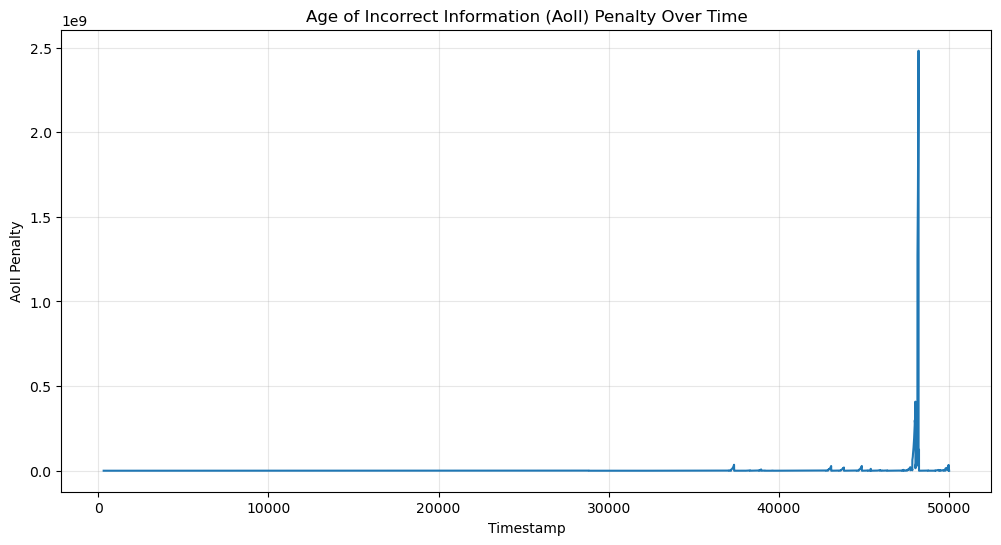

In [3]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIGURATION ===
alpha = 0.01  # EWMA smoothing factor
rolling_window_size = 12
convergence_std_threshold = 0.05
min_samples_required = 30
M = 3 # Number of nodes to sample per time step

# === AoII Configuration ===
aoii_base_penalty = 1.0  # Base penalty for each time step
aoii_exponential_factor = 1.01  # Growth factor for exponential penalty

# === Load dataset ===
df = pd.read_csv("temp_state.csv")
node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df['SN'].values
df.set_index('SN', inplace=True)

# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

# === Phase One: Training & Rate Estimation ===
last_value = {node: None for node in node_columns}
last_time = {node: None for node in node_columns}
rate_estimates = defaultdict(list)
smoothed_rate = {node: None for node in node_columns}
smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
converged_nodes = set()

poll_log_phase1 = []
rr_index = 0
training_end_idx = 0

for t_idx, t in enumerate(time_steps):
    sampled = 0
    checked = 0

    while sampled < M and checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        checked += 1

        temp = df.loc[t, node]
        if temp < 0 or temp > 100 or node in converged_nodes:
            continue

        if last_value[node] is None:
            last_value[node] = temp
            last_time[node] = t
            continue

        dt = t - last_time[node]
        dz = temp - last_value[node]
        if dt == 0:
            continue

        rate = dz / dt
        rate_estimates[node].append(rate)

        if smoothed_rate[node] is None:
            smoothed_rate[node] = rate
        else:
            smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]

        smoothed_history[node].append(smoothed_rate[node])
        last_value[node] = temp
        last_time[node] = t
        poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))

        if len(rate_estimates[node]) >= min_samples_required:
            if len(smoothed_history[node]) == rolling_window_size:
                std = np.std(smoothed_history[node])
                if std < convergence_std_threshold:
                    converged_nodes.add(node)

        sampled += 1

    if len(converged_nodes) == len(node_columns):
        training_end_idx = t_idx
        break

# === Initialize AoII tracking ===
# Time since last poll for each node
time_since_poll = {node: 0 for node in node_columns}
# Last reported state at the sink for each node
sink_state = {node: None for node in node_columns}
# AoII accumulation for each node
aoii_value = {node: 0 for node in node_columns}
# Cumulative AoII for each node
aoii_cumulative = {node: 0 for node in node_columns}
# Log for AoII events
aoii_log = []
# Number of state mismatches detected
state_mismatches = {node: 0 for node in node_columns}

# === Phase Two: Application with Online Rate Update and AoII Tracking ===
last_known_value = last_value.copy()
last_known_state = {node: get_state(val) if val is not None else None for node, val in last_value.items()}
last_update_time = last_time.copy()

# Initialize sink_state from last_known_state
for node in node_columns:
    sink_state[node] = last_known_state[node]

poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
poll_log_phase2 = []

application_time_steps = time_steps[training_end_idx + 1:]
for t_idx, t in enumerate(application_time_steps):
    # For each time step, update AoII for all nodes
    for node in node_columns:
        if sink_state[node] is None:
            continue
            
        # Increment time since last poll
        time_since_poll[node] += 1
        
        # Get actual current state
        actual_temp = df.loc[t, node]
        actual_state = get_state(actual_temp)
        
        if actual_state == 'OutOfRange':
            continue
            
        # Check if actual state differs from sink's state
        if actual_state != sink_state[node]:
            # State mismatch detected
            if aoii_value[node] == 0:
                # First time we've detected this mismatch
                state_mismatches[node] += 1
            
            # Calculate exponential penalty - higher penalties for longer incorrect periods
            aoii_penalty = aoii_base_penalty * (aoii_exponential_factor ** (time_since_poll[node] - 1))
            aoii_value[node] += aoii_penalty
            aoii_cumulative[node] += aoii_penalty
            
            # Log the AoII event
            aoii_log.append((t, node, actual_state, sink_state[node], time_since_poll[node], aoii_penalty, aoii_value[node], aoii_cumulative[node]))
    
    # Polling logic based on state change prediction
    for node in node_columns:
        if last_known_value[node] is None or smoothed_rate[node] is None:
            continue

        dt = t - last_update_time[node]
        z_pred = last_known_value[node] + smoothed_rate[node] * dt
        predicted_state = get_state(z_pred)

        if predicted_state != last_known_state[node]:
            # Poll this node
            actual_value = df.loc[t, node]
            actual_state = get_state(actual_value)
            if actual_state == 'OutOfRange':
                continue

            poll_counts[node] += 1
            if actual_state == last_known_state[node]:
                same_state_counts[node] += 1

            # Update rate estimate in Phase Two
            dz = actual_value - last_known_value[node]
            if dt > 0:
                new_rate = dz / dt
                smoothed_rate[node] = alpha * new_rate + (1 - alpha) * smoothed_rate[node]

            # Update last known values
            last_known_value[node] = actual_value
            last_known_state[node] = actual_state
            last_update_time[node] = t
            
            # Update sink state and reset AoII tracking for this node
            sink_state[node] = actual_state
            time_since_poll[node] = 0
            aoii_value[node] = 0  # Reset current AoII value (cumulative remains)

            poll_log_phase2.append((t, node, actual_value, actual_state, z_pred, predicted_state, smoothed_rate[node]))

# === Summary Output ===
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns],
    'State_Mismatches': [state_mismatches[n] for n in node_columns],
    'Total_AoII': [aoii_cumulative[n] for n in node_columns],
    'Avg_AoII_per_Mismatch': [aoii_cumulative[n] / state_mismatches[n] if state_mismatches[n] > 0 else 0 for n in node_columns]
})
summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]
summary_df["Poll_Efficiency"] = (summary_df["State_Changed"] / summary_df["Polled"] * 100).round(2)
summary_df = summary_df.round(2)

# Create AoII summary dataframe
if aoii_log:
    aoii_df = pd.DataFrame(aoii_log, columns=['Timestamp', 'Node', 'Actual_State', 'Sink_State', 
                                             'Time_Since_Poll', 'Penalty', 'Current_AoII', 'Cumulative_AoII'])
else:
    aoii_df = pd.DataFrame(columns=['Timestamp', 'Node', 'Actual_State', 'Sink_State', 
                                   'Time_Since_Poll', 'Penalty', 'Current_AoII', 'Cumulative_AoII'])

# === Display and Save ===
print("\n==== Phase One: Rate Estimation Summary ====")
for node in node_columns:
    sample_count = len(rate_estimates[node])
    mean_rate = np.mean(rate_estimates[node]) if sample_count else 0
    status = "Converged" if node in converged_nodes else "Not Converged"
    print(f"{node:>6}: Samples={sample_count:3}  Mean Rate={mean_rate: .5f}  Status={status}")

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df.to_string(index=False))

# Save results to CSV
phase1_df = pd.DataFrame(poll_log_phase1, columns=['Timestamp', 'Node', 'Temperature', 'Rate', 'Smoothed_Rate'])
phase1_df.to_csv('phase1_poll_log.csv', index=False)

phase2_df = pd.DataFrame(poll_log_phase2, columns=['Timestamp', 'Node', 'Temperature', 'State', 'Pred_Temp', 'Pred_State', 'Rate'])
phase2_df.to_csv('phase2_poll_log.csv', index=False)

summary_df.to_csv('phase2_polling_summary.csv', index=False)
aoii_df.to_csv('aoii_tracking_log.csv', index=False)

print("\n✅ Results saved to:")
print(" - phase1_poll_log.csv")
print(" - phase2_polling_summary.csv")
print(" - phase2_poll_log.csv")
print(" - aoii_tracking_log.csv")

# === AGGREGATE METRICS ===
total_polls = summary_df["Polled"].sum()
total_state_changes = summary_df["State_Changed"].sum()
total_same_state = summary_df["Same_State"].sum()
total_mismatches = summary_df["State_Mismatches"].sum()
avg_aoii = summary_df["Avg_AoII_per_Mismatch"].mean()
total_aoii = summary_df["Total_AoII"].sum()

application_steps = len(time_steps) - (training_end_idx + 1)
theoretical_max_polls = application_steps * M
polling_efficiency = (total_polls / theoretical_max_polls) * 100 if theoretical_max_polls > 0 else 0
detection_accuracy = (total_state_changes / total_polls) * 100 if total_polls > 0 else 0
overall_efficiency = (total_state_changes / total_mismatches) * 100 if total_mismatches > 0 else 0

print("\n==== Aggregate Detection Metrics ====")
print(f"Total Application Time Steps    : {application_steps}")
print(f"Max Possible Polls (Round Robin): {theoretical_max_polls}")
print(f"Total Actual Polls              : {total_polls}")
print(f"Polling Efficiency (%)          : {polling_efficiency:.2f}%")
print(f"Missed Detections (Same State)  : {total_same_state}")
print(f"Detected State Changes          : {total_state_changes}")
print(f"Total State Mismatches          : {total_mismatches}")
print(f"State Change Detection (%)      : {overall_efficiency:.2f}%")

print("\n==== Age of Incorrect Information Metrics ====")
print(f"Average AoII per Mismatch       : {avg_aoii:.2f}")
print(f"Total AoII penalty accumulated  : {total_aoii:.2f}")
print(f"AoII penalty per time step      : {total_aoii/application_steps:.2f}")

# Optional: Plot AoII over time for visualization
try:
    if not aoii_df.empty:
        import matplotlib.pyplot as plt
        
        # Calculate cumulative AoII across all nodes at each timestamp
        aoii_by_time = aoii_df.groupby('Timestamp')['Penalty'].sum().reset_index()
        
        plt.figure(figsize=(12, 6))
        plt.plot(aoii_by_time['Timestamp'], aoii_by_time['Penalty'])
        plt.title('Age of Incorrect Information (AoII) Penalty Over Time')
        plt.xlabel('Timestamp')
        plt.ylabel('AoII Penalty')
        plt.grid(True, alpha=0.3)
        plt.savefig('aoii_over_time.png')
        print(" - aoii_over_time.png (visualization)")
except Exception as e:
    print(f"Note: Could not create visualization: {e}")


==== Phase One: Rate Estimation Summary ====
 node1: Samples= 30  Mean Rate=-0.01328  Status=Converged
 node2: Samples= 30  Mean Rate=-0.01900  Status=Converged
 node3: Samples= 30  Mean Rate=-0.00649  Status=Converged
 node4: Samples= 30  Mean Rate=-0.01441  Status=Converged
 node5: Samples= 30  Mean Rate=-0.01496  Status=Converged
 node6: Samples= 30  Mean Rate=-0.02064  Status=Converged
 node7: Samples= 30  Mean Rate=-0.01355  Status=Converged
 node8: Samples= 30  Mean Rate=-0.01340  Status=Converged
 node9: Samples= 30  Mean Rate=-0.01485  Status=Converged
node10: Samples= 30  Mean Rate=-0.01554  Status=Converged
node11: Samples= 30  Mean Rate=-0.03077  Status=Converged
node12: Samples= 30  Mean Rate=-0.03031  Status=Converged
node13: Samples= 30  Mean Rate=-0.03144  Status=Converged
node14: Samples= 30  Mean Rate=-0.03202  Status=Converged
node15: Samples= 30  Mean Rate=-0.03267  Status=Converged
node16: Samples= 30  Mean Rate=-0.03064  Status=Converged
node17: Samples= 30  Mean 

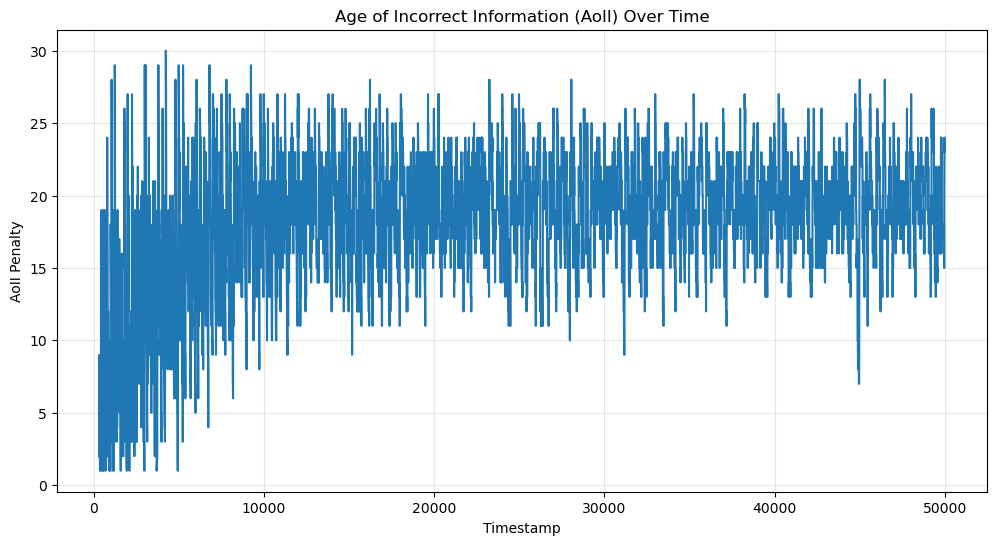

In [4]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque

# === CONFIGURATION ===
alpha = 0.01  # EWMA smoothing factor
rolling_window_size = 12
convergence_std_threshold = 0.05
min_samples_required = 30
M = 3 # Number of nodes to sample per time step

# === AoII Configuration ===
aoii_penalty_per_timestep = 1.0  # Linear penalty for each time step

# === Load dataset ===
df = pd.read_csv("temp_state.csv")
node_columns = [col for col in df.columns if col.startswith("node")]
time_steps = df['SN'].values
df.set_index('SN', inplace=True)

# === State classification ===
def get_state(temp):
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

# === Phase One: Training & Rate Estimation ===
last_value = {node: None for node in node_columns}
last_time = {node: None for node in node_columns}
rate_estimates = defaultdict(list)
smoothed_rate = {node: None for node in node_columns}
smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
converged_nodes = set()

poll_log_phase1 = []
rr_index = 0
training_end_idx = 0

for t_idx, t in enumerate(time_steps):
    sampled = 0
    checked = 0

    while sampled < M and checked < len(node_columns):
        node = node_columns[rr_index % len(node_columns)]
        rr_index += 1
        checked += 1

        temp = df.loc[t, node]
        if temp < 0 or temp > 100 or node in converged_nodes:
            continue

        if last_value[node] is None:
            last_value[node] = temp
            last_time[node] = t
            continue

        dt = t - last_time[node]
        dz = temp - last_value[node]
        if dt == 0:
            continue

        rate = dz / dt
        rate_estimates[node].append(rate)

        if smoothed_rate[node] is None:
            smoothed_rate[node] = rate
        else:
            smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]

        smoothed_history[node].append(smoothed_rate[node])
        last_value[node] = temp
        last_time[node] = t
        poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))

        if len(rate_estimates[node]) >= min_samples_required:
            if len(smoothed_history[node]) == rolling_window_size:
                std = np.std(smoothed_history[node])
                if std < convergence_std_threshold:
                    converged_nodes.add(node)

        sampled += 1

    if len(converged_nodes) == len(node_columns):
        training_end_idx = t_idx
        break

# === Initialize AoII tracking ===
# Time since last poll for each node
time_since_poll = {node: 0 for node in node_columns}
# Last reported state at the sink for each node
sink_state = {node: None for node in node_columns}
# Current AoII accumulation for each node
aoii_value = {node: 0 for node in node_columns}
# Cumulative AoII for each node
aoii_cumulative = {node: 0 for node in node_columns}
# Log for AoII events
aoii_log = []
# Number of state mismatches detected
state_mismatches = {node: 0 for node in node_columns}
# Total time spent in incorrect state
incorrect_time = {node: 0 for node in node_columns}

# === Phase Two: Application with Online Rate Update and AoII Tracking ===
last_known_value = last_value.copy()
last_known_state = {node: get_state(val) if val is not None else None for node, val in last_value.items()}
last_update_time = last_time.copy()

# Initialize sink_state from last_known_state
for node in node_columns:
    sink_state[node] = last_known_state[node]

poll_counts = {node: 0 for node in node_columns}
same_state_counts = {node: 0 for node in node_columns}
poll_log_phase2 = []

application_time_steps = time_steps[training_end_idx + 1:]
for t_idx, t in enumerate(application_time_steps):
    # For each time step, update AoII for all nodes
    for node in node_columns:
        if sink_state[node] is None:
            continue
            
        # Increment time since last poll
        time_since_poll[node] += 1
        
        # Get actual current state
        actual_temp = df.loc[t, node]
        actual_state = get_state(actual_temp)
        
        if actual_state == 'OutOfRange':
            continue
            
        # Check if actual state differs from sink's state
        if actual_state != sink_state[node]:
            # State mismatch detected
            if aoii_value[node] == 0:
                # First time we've detected this mismatch
                state_mismatches[node] += 1
            
            # Apply linear penalty - simply add one unit per time step
            aoii_value[node] += aoii_penalty_per_timestep
            aoii_cumulative[node] += aoii_penalty_per_timestep
            incorrect_time[node] += 1
            
            # Log the AoII event
            aoii_log.append((t, node, actual_state, sink_state[node], time_since_poll[node], 
                           aoii_penalty_per_timestep, aoii_value[node], aoii_cumulative[node]))
    
    # Polling logic based on state change prediction
    for node in node_columns:
        if last_known_value[node] is None or smoothed_rate[node] is None:
            continue

        dt = t - last_update_time[node]
        z_pred = last_known_value[node] + smoothed_rate[node] * dt
        predicted_state = get_state(z_pred)

        if predicted_state != last_known_state[node]:
            # Poll this node
            actual_value = df.loc[t, node]
            actual_state = get_state(actual_value)
            if actual_state == 'OutOfRange':
                continue

            poll_counts[node] += 1
            if actual_state == last_known_state[node]:
                same_state_counts[node] += 1

            # Update rate estimate in Phase Two
            dz = actual_value - last_known_value[node]
            if dt > 0:
                new_rate = dz / dt
                smoothed_rate[node] = alpha * new_rate + (1 - alpha) * smoothed_rate[node]

            # Update last known values
            last_known_value[node] = actual_value
            last_known_state[node] = actual_state
            last_update_time[node] = t
            
            # Update sink state and reset AoII tracking for this node
            sink_state[node] = actual_state
            time_since_poll[node] = 0
            aoii_value[node] = 0  # Reset current AoII value (cumulative remains)

            poll_log_phase2.append((t, node, actual_value, actual_state, z_pred, predicted_state, smoothed_rate[node]))

# === Summary Output ===
summary_df = pd.DataFrame({
    'Node': node_columns,
    'Polled': [poll_counts[n] for n in node_columns],
    'Same_State': [same_state_counts[n] for n in node_columns],
    'State_Mismatches': [state_mismatches[n] for n in node_columns],
    'Time_Incorrect': [incorrect_time[n] for n in node_columns],
    'Total_AoII': [aoii_cumulative[n] for n in node_columns],
    'Avg_AoII_per_Mismatch': [aoii_cumulative[n] / state_mismatches[n] if state_mismatches[n] > 0 else 0 for n in node_columns]
})
summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]
summary_df["Poll_Efficiency"] = (summary_df["State_Changed"] / summary_df["Polled"] * 100).round(2)
summary_df = summary_df.round(2)

# Create AoII summary dataframe
if aoii_log:
    aoii_df = pd.DataFrame(aoii_log, columns=['Timestamp', 'Node', 'Actual_State', 'Sink_State', 
                                             'Time_Since_Poll', 'Penalty', 'Current_AoII', 'Cumulative_AoII'])
else:
    aoii_df = pd.DataFrame(columns=['Timestamp', 'Node', 'Actual_State', 'Sink_State', 
                                   'Time_Since_Poll', 'Penalty', 'Current_AoII', 'Cumulative_AoII'])

# === Display and Save ===
print("\n==== Phase One: Rate Estimation Summary ====")
for node in node_columns:
    sample_count = len(rate_estimates[node])
    mean_rate = np.mean(rate_estimates[node]) if sample_count else 0
    status = "Converged" if node in converged_nodes else "Not Converged"
    print(f"{node:>6}: Samples={sample_count:3}  Mean Rate={mean_rate: .5f}  Status={status}")

print("\n==== Polling Summary for Application Phase ====\n")
print(summary_df.to_string(index=False))

# Save results to CSV
phase1_df = pd.DataFrame(poll_log_phase1, columns=['Timestamp', 'Node', 'Temperature', 'Rate', 'Smoothed_Rate'])
phase1_df.to_csv('phase1_poll_log.csv', index=False)

phase2_df = pd.DataFrame(poll_log_phase2, columns=['Timestamp', 'Node', 'Temperature', 'State', 'Pred_Temp', 'Pred_State', 'Rate'])
phase2_df.to_csv('phase2_poll_log.csv', index=False)

summary_df.to_csv('phase2_polling_summary.csv', index=False)
aoii_df.to_csv('aoii_tracking_log.csv', index=False)

print("\n✅ Results saved to:")
print(" - phase1_poll_log.csv")
print(" - phase2_polling_summary.csv")
print(" - phase2_poll_log.csv")
print(" - aoii_tracking_log.csv")

# === AGGREGATE METRICS ===
total_polls = summary_df["Polled"].sum()
total_state_changes = summary_df["State_Changed"].sum()
total_same_state = summary_df["Same_State"].sum()
total_mismatches = summary_df["State_Mismatches"].sum()
total_incorrect_time = summary_df["Time_Incorrect"].sum()
avg_aoii = summary_df["Avg_AoII_per_Mismatch"].mean()
total_aoii = summary_df["Total_AoII"].sum()

application_steps = len(time_steps) - (training_end_idx + 1)
theoretical_max_polls = application_steps * M
polling_efficiency = (total_polls / theoretical_max_polls) * 100 if theoretical_max_polls > 0 else 0
detection_accuracy = (total_state_changes / total_polls) * 100 if total_polls > 0 else 0
overall_efficiency = (total_state_changes / total_mismatches) * 100 if total_mismatches > 0 else 0

print("\n==== Aggregate Detection Metrics ====")
print(f"Total Application Time Steps    : {application_steps}")
print(f"Max Possible Polls (Round Robin): {theoretical_max_polls}")
print(f"Total Actual Polls              : {total_polls}")
print(f"Polling Efficiency (%)          : {polling_efficiency:.2f}%")
print(f"Missed Detections (Same State)  : {total_same_state}")
print(f"Detected State Changes          : {total_state_changes}")
print(f"Total State Mismatches          : {total_mismatches}")
print(f"State Change Detection (%)      : {overall_efficiency:.2f}%")

print("\n==== Age of Incorrect Information Metrics ====")
print(f"Total time spent in incorrect state: {total_incorrect_time}")
print(f"Average AoII per Mismatch       : {avg_aoii:.2f}")
print(f"Total AoII accumulated          : {total_aoii:.2f}")
print(f"AoII per time step              : {total_aoii/application_steps:.2f}")
print(f"Average time per incorrect state: {total_incorrect_time/total_mismatches:.2f} time steps")

# Optional: Plot AoII over time for visualization
try:
    if not aoii_df.empty:
        import matplotlib.pyplot as plt
        
        # Calculate AoII across all nodes at each timestamp
        aoii_by_time = aoii_df.groupby('Timestamp')['Penalty'].sum().reset_index()
        
        plt.figure(figsize=(12, 6))
        plt.plot(aoii_by_time['Timestamp'], aoii_by_time['Penalty'])
        plt.title('Age of Incorrect Information (AoII) Over Time')
        plt.xlabel('Timestamp')
        plt.ylabel('AoII Penalty')
        plt.grid(True, alpha=0.3)
        plt.savefig('aoii_over_time.png')
        print(" - aoii_over_time.png (visualization)")
except Exception as e:
    print(f"Note: Could not create visualization: {e}")

Running simulations for different M values...
  Running with M = 1...
  Completed in 9.63 seconds
  Running with M = 2...
  Completed in 10.00 seconds
  Running with M = 3...
  Completed in 10.25 seconds
  Running with M = 5...
  Completed in 10.03 seconds
  Running with M = 10...
  Completed in 10.01 seconds
  Running with M = 15...
  Completed in 10.04 seconds
  Running with M = 20...
  Completed in 9.81 seconds
  Running with M = 25...
  Completed in 9.92 seconds
  Running with M = 30...
  Completed in 10.00 seconds

=== AoII Metrics for Different M Values ===

M = 1
  Total time spent in incorrect state: 945423
  Average AoII per Mismatch          : 2955.83
  Total AoII accumulated             : 945423.00
  AoII per time step                 : 19.49
  Average time per incorrect state   : 2375.43

M = 2
  Total time spent in incorrect state: 941574
  Average AoII per Mismatch          : 2361.44
  Total AoII accumulated             : 941574.00
  AoII per time step                 : 1

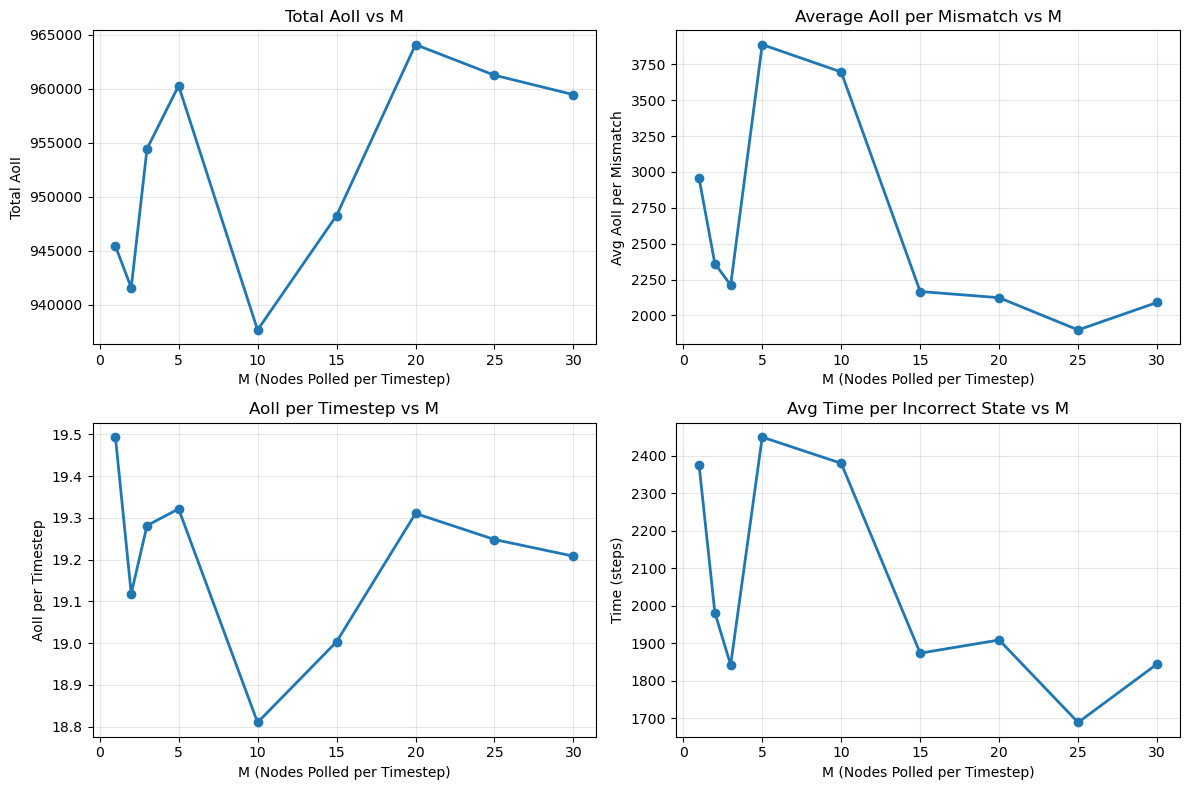

In [12]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
import time

def run_simulation(M_value):
    """Run the full simulation with the specified M value and return AoII metrics"""
    
    # === CONFIGURATION ===
    alpha = 0.1  # EWMA smoothing factor
    rolling_window_size = 12
    convergence_std_threshold = 0.05
    min_samples_required = 50
    M = M_value  # Number of nodes to sample per time step
    
    # === AoII Configuration ===
    aoii_penalty_per_timestep = 1.0  # Linear penalty for each time step
    
    # === Load dataset ===
    df = pd.read_csv("temp_state_2.csv")
    node_columns = [col for col in df.columns if col.startswith("node")]
    time_steps = df['SN'].values
    df.set_index('SN', inplace=True)
    
    # === State classification ===
    def get_state(temp):
        temp = round(temp)
        if 9 <= temp <= 16:
            return 'Cold'
        elif 17 <= temp <= 23:
            return 'Warm'
        elif 24 <= temp <= 31:
            return 'Hot'
        return 'OutOfRange'
    
    # === Phase One: Training & Rate Estimation ===
    last_value = {node: None for node in node_columns}
    last_time = {node: None for node in node_columns}
    rate_estimates = defaultdict(list)
    smoothed_rate = {node: None for node in node_columns}
    smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
    converged_nodes = set()
    
    poll_log_phase1 = []
    rr_index = 0
    training_end_idx = 0
    
    for t_idx, t in enumerate(time_steps):
        sampled = 0
        checked = 0
    
        while sampled < M and checked < len(node_columns):
            node = node_columns[rr_index % len(node_columns)]
            rr_index += 1
            checked += 1
    
            temp = df.loc[t, node]
            if temp < 0 or temp > 100 or node in converged_nodes:
                continue
    
            if last_value[node] is None:
                last_value[node] = temp
                last_time[node] = t
                continue
    
            dt = t - last_time[node]
            dz = temp - last_value[node]
            if dt == 0:
                continue
    
            rate = dz / dt
            rate_estimates[node].append(rate)
    
            if smoothed_rate[node] is None:
                smoothed_rate[node] = rate
            else:
                smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]
    
            smoothed_history[node].append(smoothed_rate[node])
            last_value[node] = temp
            last_time[node] = t
            poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))
    
            if len(rate_estimates[node]) >= min_samples_required:
                if len(smoothed_history[node]) == rolling_window_size:
                    std = np.std(smoothed_history[node])
                    if std < convergence_std_threshold:
                        converged_nodes.add(node)
    
            sampled += 1
    
        if len(converged_nodes) == len(node_columns):
            training_end_idx = t_idx
            break
    
    # === Initialize AoII tracking ===
    time_since_poll = {node: 0 for node in node_columns}
    sink_state = {node: None for node in node_columns}
    aoii_value = {node: 0 for node in node_columns}
    aoii_cumulative = {node: 0 for node in node_columns}
    state_mismatches = {node: 0 for node in node_columns}
    incorrect_time = {node: 0 for node in node_columns}
    
    # === Phase Two: Application ===
    last_known_value = last_value.copy()
    last_known_state = {node: get_state(val) if val is not None else None for node, val in last_value.items()}
    last_update_time = last_time.copy()
    
    # Initialize sink_state from last_known_state
    for node in node_columns:
        sink_state[node] = last_known_state[node]
    
    poll_counts = {node: 0 for node in node_columns}
    same_state_counts = {node: 0 for node in node_columns}
    
    application_time_steps = time_steps[training_end_idx + 1:]
    for t_idx, t in enumerate(application_time_steps):
        # For each time step, update AoII for all nodes
        for node in node_columns:
            if sink_state[node] is None:
                continue
                
            # Increment time since last poll
            time_since_poll[node] += 1
            
            # Get actual current state
            actual_temp = df.loc[t, node]
            actual_state = get_state(actual_temp)
            
            if actual_state == 'OutOfRange':
                continue
                
            # Check if actual state differs from sink's state
            if actual_state != sink_state[node]:
                # State mismatch detected
                if aoii_value[node] == 0:
                    # First time we've detected this mismatch
                    state_mismatches[node] += 1
                
                # Apply linear penalty
                aoii_value[node] += aoii_penalty_per_timestep
                aoii_cumulative[node] += aoii_penalty_per_timestep
                incorrect_time[node] += 1
        
        # Polling based on state change prediction
        nodes_to_poll = []
        for node in node_columns:
            if last_known_value[node] is None or smoothed_rate[node] is None:
                continue
    
            dt = t - last_update_time[node]
            z_pred = last_known_value[node] + smoothed_rate[node] * dt
            predicted_state = get_state(z_pred)
    
            if predicted_state != last_known_state[node]:
                nodes_to_poll.append(node)
        
        # Limit to M polls per timestep
        nodes_polled = 0
        for node in nodes_to_poll:
            if nodes_polled >= M:
                break
                
            actual_value = df.loc[t, node]
            actual_state = get_state(actual_value)
            if actual_state == 'OutOfRange':
                continue
    
            poll_counts[node] += 1
            if actual_state == last_known_state[node]:
                same_state_counts[node] += 1
    
            # Update rate estimate
            dt = t - last_update_time[node]
            dz = actual_value - last_known_value[node]
            if dt > 0:
                new_rate = dz / dt
                smoothed_rate[node] = alpha * new_rate + (1 - alpha) * smoothed_rate[node]
    
            # Update known values
            last_known_value[node] = actual_value
            last_known_state[node] = actual_state
            last_update_time[node] = t
            
            # Update sink state and reset AoII
            sink_state[node] = actual_state
            time_since_poll[node] = 0
            aoii_value[node] = 0  # Reset current AoII
    
            nodes_polled += 1
    
    # === Calculate AoII Metrics ===
    total_mismatches = sum(state_mismatches.values())
    total_incorrect_time = sum(incorrect_time.values())
    avg_aoii = np.mean([aoii_cumulative[n] / state_mismatches[n] if state_mismatches[n] > 0 else 0 for n in node_columns])
    total_aoii = sum(aoii_cumulative.values())
    application_steps = len(application_time_steps)
    
    # Return metrics as a dictionary
    return {
        "M": M_value,
        "Total_Incorrect_Time": total_incorrect_time,
        "Average_AoII_per_Mismatch": avg_aoii,
        "Total_AoII": total_aoii,
        "AoII_per_Timestep": total_aoii / application_steps if application_steps > 0 else 0,
        "Average_Time_per_Incorrect_State": total_incorrect_time / total_mismatches if total_mismatches > 0 else 0,
        "Total_Polls": sum(poll_counts.values()),
        "State_Mismatches": total_mismatches,
        "Application_Steps": application_steps
    }

def main():
    # Values of M to test
    m_values = [1, 2, 3, 5, 10, 15, 20, 25, 30]
    
    results = []
    
    print("Running simulations for different M values...")
    for m in m_values:
        print(f"  Running with M = {m}...")
        start_time = time.time()
        metrics = run_simulation(m)
        elapsed = time.time() - start_time
        print(f"  Completed in {elapsed:.2f} seconds")
        results.append(metrics)
    
    # Create results dataframe
    results_df = pd.DataFrame(results)
    results_df = results_df.set_index('M')
    
    # Save to CSV
    results_df.to_csv('aoii_vs_m_results.csv')
    
    # Display results
    print("\n=== AoII Metrics for Different M Values ===\n")
    
    for m in m_values:
        metrics = results_df.loc[m]
        print(f"M = {m}")
        print(f"  Total time spent in incorrect state: {metrics['Total_Incorrect_Time']:.0f}")
        print(f"  Average AoII per Mismatch          : {metrics['Average_AoII_per_Mismatch']:.2f}")
        print(f"  Total AoII accumulated             : {metrics['Total_AoII']:.2f}")
        print(f"  AoII per time step                 : {metrics['AoII_per_Timestep']:.2f}")
        print(f"  Average time per incorrect state   : {metrics['Average_Time_per_Incorrect_State']:.2f}")
        print()
    
    print(f"Results saved to 'aoii_vs_m_results.csv'")
    
    # Try to generate a plot if matplotlib is available
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(12, 8))
        
        plt.subplot(2, 2, 1)
        plt.plot(results_df.index, results_df['Total_AoII'], 'o-', linewidth=2)
        plt.title('Total AoII vs M')
        plt.xlabel('M (Nodes Polled per Timestep)')
        plt.ylabel('Total AoII')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 2)
        plt.plot(results_df.index, results_df['Average_AoII_per_Mismatch'], 'o-', linewidth=2)
        plt.title('Average AoII per Mismatch vs M')
        plt.xlabel('M (Nodes Polled per Timestep)')
        plt.ylabel('Avg AoII per Mismatch')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 3)
        plt.plot(results_df.index, results_df['AoII_per_Timestep'], 'o-', linewidth=2)
        plt.title('AoII per Timestep vs M')
        plt.xlabel('M (Nodes Polled per Timestep)')
        plt.ylabel('AoII per Timestep')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 4)
        plt.plot(results_df.index, results_df['Average_Time_per_Incorrect_State'], 'o-', linewidth=2)
        plt.title('Avg Time per Incorrect State vs M')
        plt.xlabel('M (Nodes Polled per Timestep)')
        plt.ylabel('Time (steps)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('aoii_vs_m_plot.png')
        print("Plot saved to 'aoii_vs_m_plot.png'")
    except Exception as e:
        print(f"Could not generate plot: {e}")

if __name__ == "__main__":
    main()

Dataset loaded with shape: (50000, 31)
Found 30 node columns

Running simulations with varying M values: [1, 2, 3, 5, 8, 10, 15]

Simulating with M = 1...

==== Summary for M = 1 ====
Training ended at step: 929/50000
Nodes converged: 30/30
Application phase steps: 49070
Polling efficiency: 11.41%
Detection accuracy: 61.38%
Collision rate: 4.70%

Simulating with M = 2...

==== Summary for M = 2 ====
Training ended at step: 471/50000
Nodes converged: 30/30
Application phase steps: 49528
Polling efficiency: 5.98%
Detection accuracy: 58.80%
Collision rate: 13.62%

Simulating with M = 3...

==== Summary for M = 3 ====
Training ended at step: 317/50000
Nodes converged: 30/30
Application phase steps: 49682
Polling efficiency: 4.04%
Detection accuracy: 60.00%
Collision rate: 12.86%

Simulating with M = 5...

==== Summary for M = 5 ====
Training ended at step: 220/50000
Nodes converged: 30/30
Application phase steps: 49779
Polling efficiency: 2.69%
Detection accuracy: 57.45%
Collision rate: 13

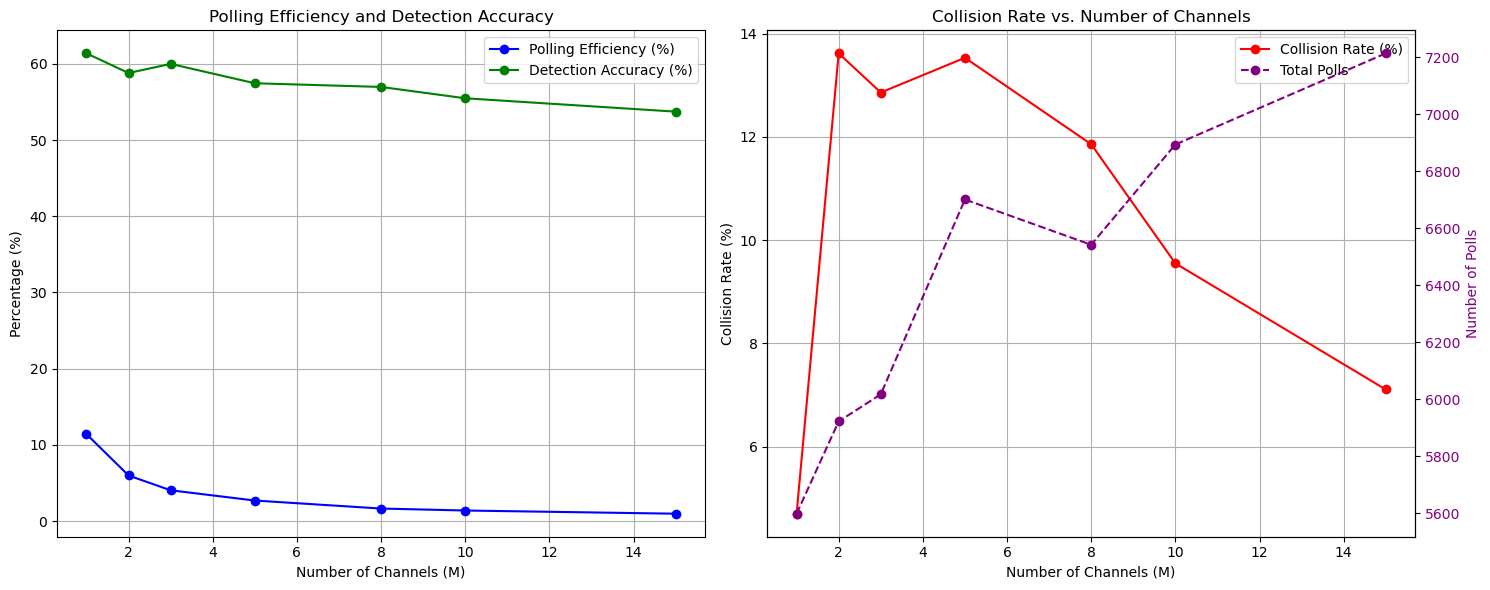


Best overall M value: 1
With detection accuracy of 61.38% and polling efficiency of 11.41%

Saved detailed results for M=1 to:
 - node_summary_M1.csv
 - poll_log_M1.csv


In [4]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, deque

def simulate_rate_based_system(M_values, temperature_data):
    """
    Simulate rate-based system with channel constraints for various M values.
    
    Args:
        M_values: List of M values to test (number of allowed pulls per time step)
        temperature_data: DataFrame containing temperature data
        
    Returns:
        Dictionary of results for each M value
    """
    results = {}
    node_columns = [col for col in temperature_data.columns if col.startswith("node")]
    time_steps = temperature_data['SN'].values
    
    # Create a copy of dataframe with SN as index
    df = temperature_data.copy()
    df.set_index('SN', inplace=True)
    
    # Configuration parameters
    alpha = 0.01  # EWMA smoothing factor
    rolling_window_size = 12
    convergence_std_threshold = 0.05
    min_samples_required = 30
    
    print(f"\nRunning simulations with varying M values: {M_values}")
    
    for M in M_values:
        print(f"\nSimulating with M = {M}...")
        
        # === Initialize tracking variables ===
        last_value = {node: None for node in node_columns}
        last_time = {node: None for node in node_columns}
        rate_estimates = defaultdict(list)
        smoothed_rate = {node: None for node in node_columns}
        smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
        converged_nodes = set()
        
        poll_log_phase1 = []
        training_end_idx = 0
        
        # === Initialize collision tracking ===
        successful_polls = 0
        failed_polls = 0
        backoff_counters = {node: 0 for node in node_columns}
        
        # === Phase One: Training & Rate Estimation ===
        for t_idx, t in enumerate(time_steps):
            # Track channel usage for this time step
            channel_usage = set()
            sampled_nodes = 0
            
            # Randomize node order for fairness
            shuffled_nodes = list(node_columns)
            random.shuffle(shuffled_nodes)
            
            for node in shuffled_nodes:
                # Skip nodes in backoff period
                if backoff_counters[node] > 0:
                    backoff_counters[node] -= 1
                    continue
                    
                # Skip already converged nodes
                if node in converged_nodes:
                    continue
                
                temp = df.loc[t, node]
                if temp < 0 or temp > 100:
                    continue
                
                # Try to acquire a channel
                chosen_channel = random.randint(0, M - 1)
                
                if chosen_channel in channel_usage:
                    # Collision occurred
                    failed_polls += 1
                    
                    # Apply exponential backoff
                    retry_count = backoff_counters.get(f"{node}_retry", 0) + 1
                    backoff_counters[f"{node}_retry"] = retry_count
                    max_backoff = min(10, 2**retry_count)
                    backoff_counters[node] = random.randint(1, max_backoff)
                    continue
                
                # Successful poll
                successful_polls += 1
                channel_usage.add(chosen_channel)
                sampled_nodes += 1
                
                # Reset retry counter
                backoff_counters[f"{node}_retry"] = 0
                
                # Process data for rate estimation
                if last_value[node] is None:
                    last_value[node] = temp
                    last_time[node] = t
                    continue
                
                dt = t - last_time[node]
                dz = temp - last_value[node]
                if dt == 0:
                    continue
                
                rate = dz / dt
                rate_estimates[node].append(rate)
                
                if smoothed_rate[node] is None:
                    smoothed_rate[node] = rate
                else:
                    smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]
                
                smoothed_history[node].append(smoothed_rate[node])
                last_value[node] = temp
                last_time[node] = t
                poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))
                
                if len(rate_estimates[node]) >= min_samples_required:
                    if len(smoothed_history[node]) == rolling_window_size:
                        std = np.std(smoothed_history[node])
                        if std < convergence_std_threshold:
                            converged_nodes.add(node)
                
                # Limit polls per time step based on M
                if sampled_nodes >= M:
                    break
            
            # End training if all nodes have converged
            if len(converged_nodes) == len(node_columns):
                training_end_idx = t_idx
                break
        
        # === Phase Two: Application with Online Rate Update ===
        last_known_value = last_value.copy()
        last_known_state = {node: get_state(val) if val is not None else None for node, val in last_value.items()}
        last_update_time = last_time.copy()
        
        poll_counts = {node: 0 for node in node_columns}
        same_state_counts = {node: 0 for node in node_columns}
        poll_log_phase2 = []
        
        # Reset collision tracking for phase 2
        phase2_successful_polls = 0
        phase2_failed_polls = 0
        backoff_counters = {node: 0 for node in node_columns}
        
        for t in time_steps[training_end_idx + 1:]:
            # Track channel usage for this time step
            channel_usage = set()
            
            # Create a list of nodes that need polling (predicted state change)
            nodes_to_poll = []
            for node in node_columns:
                if last_known_value[node] is None or smoothed_rate[node] is None:
                    continue
                
                dt = t - last_update_time[node]
                z_pred = last_known_value[node] + smoothed_rate[node] * dt
                predicted_state = get_state(z_pred)
                
                if predicted_state != last_known_state[node]:
                    nodes_to_poll.append((node, z_pred, predicted_state))
            
            # Randomize polling order for fairness
            random.shuffle(nodes_to_poll)
            
            # Try to poll nodes with predicted state changes
            for node, z_pred, predicted_state in nodes_to_poll:
                # Skip if in backoff period
                if backoff_counters[node] > 0:
                    backoff_counters[node] -= 1
                    continue
                
                # Try to acquire a channel
                chosen_channel = random.randint(0, M - 1)
                
                if chosen_channel in channel_usage:
                    # Collision occurred
                    phase2_failed_polls += 1
                    
                    # Apply exponential backoff
                    retry_count = backoff_counters.get(f"{node}_retry", 0) + 1
                    backoff_counters[f"{node}_retry"] = retry_count
                    max_backoff = min(10, 2**retry_count)
                    backoff_counters[node] = random.randint(1, max_backoff)
                    continue
                
                # Successful poll
                phase2_successful_polls += 1
                channel_usage.add(chosen_channel)
                
                # Reset retry counter
                backoff_counters[f"{node}_retry"] = 0
                
                # Get actual value and state
                actual_value = df.loc[t, node]
                actual_state = get_state(actual_value)
                
                if actual_state == 'OutOfRange':
                    continue
                
                poll_counts[node] += 1
                if actual_state == last_known_state[node]:
                    same_state_counts[node] += 1
                
                # Update rate estimate in Phase Two
                dt = t - last_update_time[node]
                dz = actual_value - last_known_value[node]
                if dt > 0:
                    new_rate = dz / dt
                    smoothed_rate[node] = alpha * new_rate + (1 - alpha) * smoothed_rate[node]
                
                last_known_value[node] = actual_value
                last_known_state[node] = actual_state
                last_update_time[node] = t
                
                poll_log_phase2.append((t, node, actual_value, actual_state, z_pred, predicted_state, smoothed_rate[node]))
                
                # Limit polls per time step based on M
                if len(channel_usage) >= M:
                    break
        
        # === Calculate metrics ===
        summary_df = pd.DataFrame({
            'Node': node_columns,
            'Polled': [poll_counts[n] for n in node_columns],
            'Same_State': [same_state_counts[n] for n in node_columns]
        })
        summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]
        
        total_polls = summary_df["Polled"].sum()
        total_state_changes = summary_df["State_Changed"].sum()
        total_same_state = summary_df["Same_State"].sum()
        
        application_steps = len(time_steps) - (training_end_idx + 1)
        theoretical_max_polls = application_steps * M
        polling_efficiency = (total_polls / theoretical_max_polls) * 100 if theoretical_max_polls > 0 else 0
        detection_accuracy = (total_state_changes / total_polls) * 100 if total_polls > 0 else 0
        
        # Total collision metrics
        total_successful = successful_polls + phase2_successful_polls
        total_failed = failed_polls + phase2_failed_polls
        total_attempts = total_successful + total_failed
        collision_rate = (total_failed / total_attempts) * 100 if total_attempts > 0 else 0
        
        # Store results
        results[M] = {
            'training_end_idx': training_end_idx,
            'application_steps': application_steps,
            'theoretical_max_polls': theoretical_max_polls,
            'total_polls': total_polls,
            'total_state_changes': total_state_changes,
            'total_same_state': total_same_state,
            'polling_efficiency': polling_efficiency,
            'detection_accuracy': detection_accuracy,
            'successful_polls': total_successful,
            'failed_polls': total_failed,
            'collision_rate': collision_rate,
            'summary_df': summary_df,
            'poll_log_phase1': poll_log_phase1,
            'poll_log_phase2': poll_log_phase2,
            'converged_nodes': len(converged_nodes)
        }
        
        # Print summary for this M value
        print(f"\n==== Summary for M = {M} ====")
        print(f"Training ended at step: {training_end_idx}/{len(time_steps)}")
        print(f"Nodes converged: {len(converged_nodes)}/{len(node_columns)}")
        print(f"Application phase steps: {application_steps}")
        print(f"Polling efficiency: {polling_efficiency:.2f}%")
        print(f"Detection accuracy: {detection_accuracy:.2f}%")
        print(f"Collision rate: {collision_rate:.2f}%")
    
    return results

def get_state(temp):
    """
    Determine temperature state based on value
    """
    if temp is None:
        return None
        
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

def plot_results(results, M_values):
    """
    Plot the results of the simulations
    """
    # Extract metrics
    polling_efficiencies = [results[M]['polling_efficiency'] for M in M_values]
    detection_accuracies = [results[M]['detection_accuracy'] for M in M_values]
    collision_rates = [results[M]['collision_rate'] for M in M_values]
    total_polls = [results[M]['total_polls'] for M in M_values]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Efficiency and accuracy
    ax1.plot(M_values, polling_efficiencies, 'o-', color='blue', label='Polling Efficiency (%)')
    ax1.plot(M_values, detection_accuracies, 'o-', color='green', label='Detection Accuracy (%)')
    ax1.set_xlabel('Number of Channels (M)')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_title('Polling Efficiency and Detection Accuracy')
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Collision rate
    ax2.plot(M_values, collision_rates, 'o-', color='red', label='Collision Rate (%)')
    ax2.set_xlabel('Number of Channels (M)')
    ax2.set_ylabel('Collision Rate (%)')
    ax2.set_title('Collision Rate vs. Number of Channels')
    ax2.grid(True)
    
    # Add secondary y-axis for total polls
    ax3 = ax2.twinx()
    ax3.plot(M_values, total_polls, 'o--', color='purple', label='Total Polls')
    ax3.set_ylabel('Number of Polls', color='purple')
    ax3.tick_params(axis='y', labelcolor='purple')
    
    # Combine legends for second plot
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax3.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()

def main():
    # Load the dataset
    try:
        temperature_data = pd.read_csv("temp_state.csv")
        print(f"Dataset loaded with shape: {temperature_data.shape}")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return
    
    # Verify the dataset has the expected columns
    if 'SN' not in temperature_data.columns:
        print("Error: Dataset must contain 'SN' column for time steps")
        return
    
    node_columns = [col for col in temperature_data.columns if col.startswith("node")]
    if not node_columns:
        print("Error: No node columns found (columns should start with 'node')")
        return
    
    print(f"Found {len(node_columns)} node columns")
    
    # Varying M values to test
    M_values = [1, 2, 3, 5, 8, 10, 15]
    
    # Run simulations
    results = simulate_rate_based_system(
        M_values=M_values,
        temperature_data=temperature_data
    )
    
    # Print comparative results table
    print("\nComparative Results Summary:")
    print("-" * 130)
    print(f"{'M':^5} | {'Poll Efficiency (%)':^18} | {'Detection Accuracy (%)':^22} | {'Collision Rate (%)':^18} | {'Total Polls':^12} | {'Converged Nodes':^15}")
    print("-" * 130)
    
    for M in M_values:
        r = results[M]
        print(f"{M:^5} | {r['polling_efficiency']:^18.2f} | {r['detection_accuracy']:^22.2f} | {r['collision_rate']:^18.2f} | {r['total_polls']:^12} | {r['converged_nodes']:^15}")
    
    print("-" * 130)
    
    # Plot results
    plot_results(results, M_values)
    
    # Get most efficient M value
    best_M = max(M_values, key=lambda M: (results[M]['detection_accuracy'] + results[M]['polling_efficiency']) / 2)
    print(f"\nBest overall M value: {best_M}")
    print(f"With detection accuracy of {results[best_M]['detection_accuracy']:.2f}% and polling efficiency of {results[best_M]['polling_efficiency']:.2f}%")
    
    # Save detailed results for best M
    best_result = results[best_M]
    best_result['summary_df'].to_csv(f"node_summary_M{best_M}.csv", index=False)
    pd.DataFrame(best_result['poll_log_phase2'], 
                 columns=["Time", "Node", "Actual_Value", "Actual_State", "Pred_Value", "Pred_State", "Updated_Rate"]
                ).to_csv(f"poll_log_M{best_M}.csv", index=False)
    
    print(f"\nSaved detailed results for M={best_M} to:")
    print(f" - node_summary_M{best_M}.csv")
    print(f" - poll_log_M{best_M}.csv")

if __name__ == "__main__":
    main()

Dataset loaded with shape: (50000, 31)
Found 30 node columns

Running simulations with varying M values: [1, 2, 5, 10, 20]

Simulating with M = 1...

==== Summary for M = 1 ====
Training ended at step: 929/50000
Nodes converged: 30/30
Application phase steps: 49070
Polling efficiency: 12.58%
Detection accuracy: 61.41%
Poll deferral rate: 25.46%

Simulating with M = 2...

==== Summary for M = 2 ====
Training ended at step: 464/50000
Nodes converged: 30/30
Application phase steps: 49535
Polling efficiency: 6.57%
Detection accuracy: 59.78%
Poll deferral rate: 3.50%

Simulating with M = 5...

==== Summary for M = 5 ====
Training ended at step: 185/50000
Nodes converged: 30/30
Application phase steps: 49814
Polling efficiency: 2.52%
Detection accuracy: 59.94%
Poll deferral rate: 0.00%

Simulating with M = 10...

==== Summary for M = 10 ====
Training ended at step: 92/50000
Nodes converged: 30/30
Application phase steps: 49907
Polling efficiency: 1.41%
Detection accuracy: 57.18%
Poll deferra

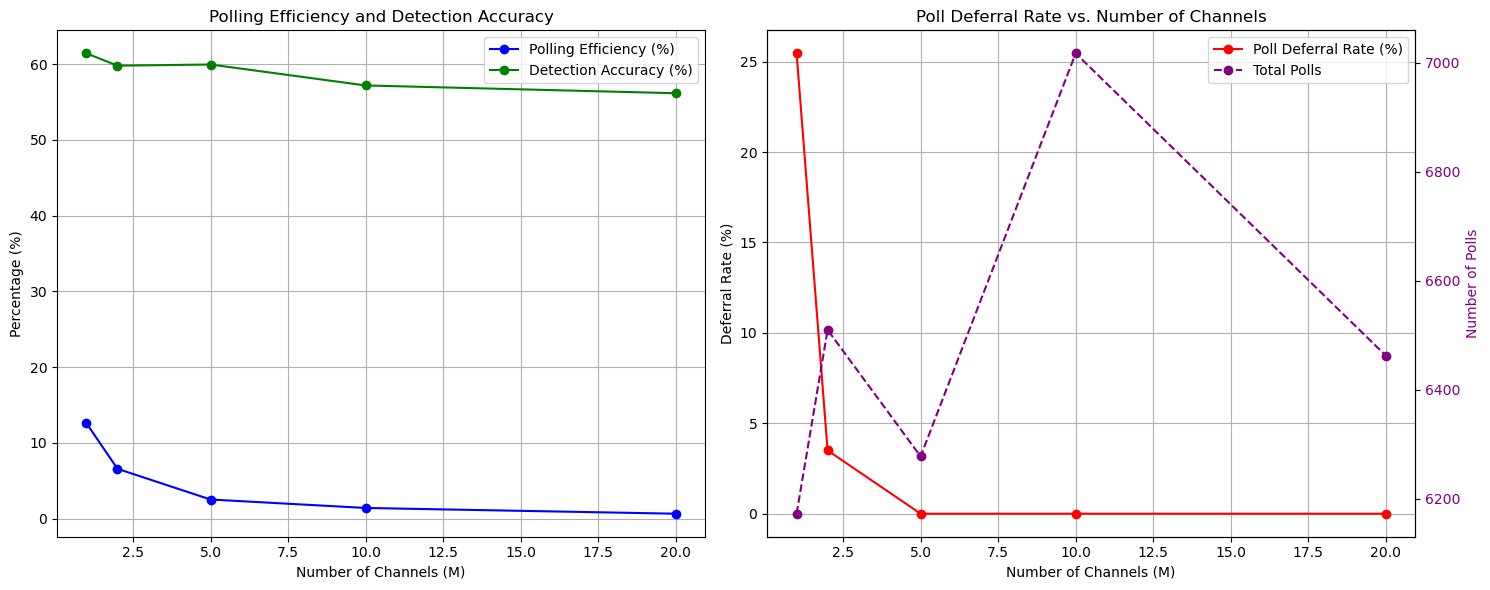


Best overall M value: 2
With detection accuracy of 59.78%, polling efficiency of 6.57%, and deferral rate of 3.50%

Saved detailed results for M=2 to:
 - node_summary_M2.csv
 - poll_log_M2.csv

State Prediction Analysis for M=2:
Total predictions: 6510
Correct predictions: 1239 (19.03%)

Predicted vs Actual State Transitions:
Predicted: OutOfRange, Actual: Hot: 1322 (20.31%)
Predicted: Warm, Actual: Cold: 1006 (15.45%)
Predicted: OutOfRange, Actual: Cold: 851 (13.07%)
Predicted: Warm, Actual: Hot: 755 (11.60%)
Predicted: Hot, Actual: Hot: 632 (9.71%)
Predicted: Warm, Actual: Warm: 607 (9.32%)
Predicted: OutOfRange, Actual: Warm: 533 (8.19%)
Predicted: Hot, Actual: Cold: 514 (7.90%)
Predicted: Hot, Actual: Warm: 290 (4.45%)
Found 30 node columns

Running simulations with varying M values: [1, 2, 5, 10, 20]

Simulating with M = 1...

==== Summary for M = 1 ====
Training ended at step: 929/50000
Nodes converged: 30/30
Application phase steps: 49070
Polling efficiency: 12.58%
Detection ac

KeyError: 'collision_rate'

In [12]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, deque

def simulate_rate_based_system(M_values, temperature_data):
    """
    Simulate rate-based system with staggered polling for various M values.
    The sink coordinates polling to eliminate collisions.
    
    Args:
        M_values: List of M values to test (number of allowed polls per time step)
        temperature_data: DataFrame containing temperature data
        
    Returns:
        Dictionary of results for each M value
    """
    results = {}
    node_columns = [col for col in temperature_data.columns if col.startswith("node")]
    time_steps = temperature_data['SN'].values
    
    # Create a copy of dataframe with SN as index
    df = temperature_data.copy()
    df.set_index('SN', inplace=True)
    
    # Configuration parameters
    alpha = 0.01  # EWMA smoothing factor
    rolling_window_size = 12
    convergence_std_threshold = 0.05
    min_samples_required = 30
    
    print(f"\nRunning simulations with varying M values: {M_values}")
    
    for M in M_values:
        print(f"\nSimulating with M = {M}...")
        
        # === Initialize tracking variables ===
        last_value = {node: None for node in node_columns}
        last_time = {node: None for node in node_columns}
        rate_estimates = defaultdict(list)
        smoothed_rate = {node: None for node in node_columns}
        smoothed_history = defaultdict(lambda: deque(maxlen=rolling_window_size))
        converged_nodes = set()
        
        poll_log_phase1 = []
        training_end_idx = 0
        
        # === Phase One: Training & Rate Estimation with Staggered Polling ===
        # Use round-robin for training phase
        rr_index = 0
        
        for t_idx, t in enumerate(time_steps):
            # Determine which nodes to poll this time step (up to M)
            nodes_to_poll = []
            
            # Build priority list - in training, prioritize nodes that haven't converged
            priority_nodes = [node for node in node_columns if node not in converged_nodes]
            
            # If we need more nodes, add converged ones too (though they're lower priority)
            if len(priority_nodes) < M:
                additional_nodes = [node for node in node_columns if node in converged_nodes]
                priority_nodes.extend(additional_nodes[:M - len(priority_nodes)])
            
            # Use round-robin within priority groups to ensure fairness
            if priority_nodes:
                # Sort remaining slots using round-robin
                start_idx = rr_index % len(priority_nodes)
                ordered_nodes = priority_nodes[start_idx:] + priority_nodes[:start_idx]
                nodes_to_poll = ordered_nodes[:M]  # Take up to M nodes
                rr_index += M  # Move round-robin pointer
            
            # Poll the selected nodes
            for node in nodes_to_poll:
                temp = df.loc[t, node]
                if temp < 0 or temp > 100:
                    continue
                
                # Process data for rate estimation
                if last_value[node] is None:
                    last_value[node] = temp
                    last_time[node] = t
                    continue
                
                dt = t - last_time[node]
                dz = temp - last_value[node]
                if dt == 0:
                    continue
                
                rate = dz / dt
                rate_estimates[node].append(rate)
                
                if smoothed_rate[node] is None:
                    smoothed_rate[node] = rate
                else:
                    smoothed_rate[node] = alpha * rate + (1 - alpha) * smoothed_rate[node]
                
                smoothed_history[node].append(smoothed_rate[node])
                last_value[node] = temp
                last_time[node] = t
                poll_log_phase1.append((t, node, temp, rate, smoothed_rate[node]))
                
                if len(rate_estimates[node]) >= min_samples_required:
                    if len(smoothed_history[node]) == rolling_window_size:
                        std = np.std(smoothed_history[node])
                        if std < convergence_std_threshold:
                            converged_nodes.add(node)
            
            # End training if all nodes have converged
            if len(converged_nodes) == len(node_columns):
                training_end_idx = t_idx
                break
        
        # === Phase Two: Application with Staggered Polling ===
        last_known_value = last_value.copy()
        last_known_state = {node: get_state(val) if val is not None else None for node, val in last_value.items()}
        last_update_time = last_time.copy()
        
        poll_counts = {node: 0 for node in node_columns}
        same_state_counts = {node: 0 for node in node_columns}
        poll_log_phase2 = []
        
        # Track total polls attempted and succeeded
        total_attempted_polls = 0
        successful_polls = 0
        
        for t in time_steps[training_end_idx + 1:]:
            # Create a priority list of nodes that need polling (predicted state change)
            nodes_to_poll = []
            
            for node in node_columns:
                if last_known_value[node] is None or smoothed_rate[node] is None:
                    continue
                
                dt = t - last_update_time[node]
                z_pred = last_known_value[node] + smoothed_rate[node] * dt
                predicted_state = get_state(z_pred)
                
                if predicted_state != last_known_state[node]:
                    # Add to priority list with prediction info
                    nodes_to_poll.append((node, z_pred, predicted_state))
                    total_attempted_polls += 1
            
            # Sort by time since last poll to prioritize nodes waiting longest
            nodes_to_poll.sort(key=lambda x: t - last_update_time[x[0]], reverse=True)
            
            # Select up to M nodes to poll this time step
            for node, z_pred, predicted_state in nodes_to_poll[:M]:  # Limit to M polls
                successful_polls += 1
                
                # Get actual value and state
                actual_value = df.loc[t, node]
                actual_state = get_state(actual_value)
                
                if actual_state == 'OutOfRange':
                    continue
                
                poll_counts[node] += 1
                if actual_state == last_known_state[node]:
                    same_state_counts[node] += 1
                
                # Update rate estimate in Phase Two
                dt = t - last_update_time[node]
                dz = actual_value - last_known_value[node]
                if dt > 0:
                    new_rate = dz / dt
                    smoothed_rate[node] = alpha * new_rate + (1 - alpha) * smoothed_rate[node]
                
                last_known_value[node] = actual_value
                last_known_state[node] = actual_state
                last_update_time[node] = t
                
                poll_log_phase2.append((t, node, actual_value, actual_state, z_pred, predicted_state, smoothed_rate[node]))
        
        # === Calculate metrics ===
        summary_df = pd.DataFrame({
            'Node': node_columns,
            'Polled': [poll_counts[n] for n in node_columns],
            'Same_State': [same_state_counts[n] for n in node_columns]
        })
        summary_df["State_Changed"] = summary_df["Polled"] - summary_df["Same_State"]
        
        total_polls = summary_df["Polled"].sum()
        total_state_changes = summary_df["State_Changed"].sum()
        total_same_state = summary_df["Same_State"].sum()
        
        application_steps = len(time_steps) - (training_end_idx + 1)
        theoretical_max_polls = application_steps * M
        polling_efficiency = (total_polls / theoretical_max_polls) * 100 if theoretical_max_polls > 0 else 0
        detection_accuracy = (total_state_changes / total_polls) * 100 if total_polls > 0 else 0
        
        # Calculate waiting metrics - if more nodes needed polling than available channels
        deferred_polls = total_attempted_polls - successful_polls
        deferral_rate = (deferred_polls / total_attempted_polls) * 100 if total_attempted_polls > 0 else 0
        
        # Store results
        results[M] = {
            'training_end_idx': training_end_idx,
            'application_steps': application_steps,
            'theoretical_max_polls': theoretical_max_polls,
            'total_polls': total_polls,
            'total_state_changes': total_state_changes,
            'total_same_state': total_same_state,
            'polling_efficiency': polling_efficiency,
            'detection_accuracy': detection_accuracy,
            'total_attempted_polls': total_attempted_polls,
            'successful_polls': successful_polls,
            'deferred_polls': deferred_polls,
            'deferral_rate': deferral_rate,
            'summary_df': summary_df,
            'poll_log_phase1': poll_log_phase1,
            'poll_log_phase2': poll_log_phase2,
            'converged_nodes': len(converged_nodes)
        }
        
        # Print summary for this M value
        print(f"\n==== Summary for M = {M} ====")
        print(f"Training ended at step: {training_end_idx}/{len(time_steps)}")
        print(f"Nodes converged: {len(converged_nodes)}/{len(node_columns)}")
        print(f"Application phase steps: {application_steps}")
        print(f"Polling efficiency: {polling_efficiency:.2f}%")
        print(f"Detection accuracy: {detection_accuracy:.2f}%")
        print(f"Poll deferral rate: {deferral_rate:.2f}%")
    
    return results

def get_state(temp):
    """
    Determine temperature state based on value
    """
    if temp is None:
        return None
        
    temp = round(temp)
    if 9 <= temp <= 16:
        return 'Cold'
    elif 17 <= temp <= 23:
        return 'Warm'
    elif 24 <= temp <= 31:
        return 'Hot'
    return 'OutOfRange'

def plot_results(results, M_values):
    """
    Plot the results of the simulations
    """
    # Extract metrics
    polling_efficiencies = [results[M]['polling_efficiency'] for M in M_values]
    detection_accuracies = [results[M]['detection_accuracy'] for M in M_values]
    deferral_rates = [results[M]['deferral_rate'] for M in M_values]
    total_polls = [results[M]['total_polls'] for M in M_values]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Efficiency and accuracy
    ax1.plot(M_values, polling_efficiencies, 'o-', color='blue', label='Polling Efficiency (%)')
    ax1.plot(M_values, detection_accuracies, 'o-', color='green', label='Detection Accuracy (%)')
    ax1.set_xlabel('Number of Channels (M)')
    ax1.set_ylabel('Percentage (%)')
    ax1.set_title('Polling Efficiency and Detection Accuracy')
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Deferral rate
    ax2.plot(M_values, deferral_rates, 'o-', color='red', label='Poll Deferral Rate (%)')
    ax2.set_xlabel('Number of Channels (M)')
    ax2.set_ylabel('Deferral Rate (%)')
    ax2.set_title('Poll Deferral Rate vs. Number of Channels')
    ax2.grid(True)
    
    # Add secondary y-axis for total polls
    ax3 = ax2.twinx()
    ax3.plot(M_values, total_polls, 'o--', color='purple', label='Total Polls')
    ax3.set_ylabel('Number of Polls', color='purple')
    ax3.tick_params(axis='y', labelcolor='purple')
    
    # Combine legends for second plot
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax3.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()

def main():
    # Load the dataset
    try:
                
    
        temperature_data = pd.read_csv("temp_state.csv")
        print(f"Dataset loaded with shape: {temperature_data.shape}")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return
    
    # Verify the dataset has the expected columns
    if 'SN' not in temperature_data.columns:
        print("Error: Dataset must contain 'SN' column for time steps")
        return
    
    node_columns = [col for col in temperature_data.columns if col.startswith("node")]
    if not node_columns:
        print("Error: No node columns found (columns should start with 'node')")
        return
    
    print(f"Found {len(node_columns)} node columns")
    
    # Varying M values to test
    M_values = [1, 2,  5,  10, 20]
    
    # Run simulations
    results = simulate_rate_based_system(
        M_values=M_values,
        temperature_data=temperature_data
    )
    
    # Print comparative results table
    print("\nComparative Results Summary:")
    print("-" * 130)
    print(f"{'M':^5} | {'Poll Efficiency (%)':^18} | {'Detection Accuracy (%)':^22} | {'Deferral Rate (%)':^18} | {'Total Polls':^12} | {'Converged Nodes':^15}")
    print("-" * 130)
    
    for M in M_values:
        r = results[M]
        print(f"{M:^5} | {r['polling_efficiency']:^18.2f} | {r['detection_accuracy']:^22.2f} | {r['deferral_rate']:^18.2f} | {r['total_polls']:^12} | {r['converged_nodes']:^15}")
    
    print("-" * 130)
    
    # Plot results
    plot_results(results, M_values)
    
    # Get most efficient M value (balancing detection accuracy, polling efficiency and low deferral)
    best_M = max(M_values, key=lambda M: (
        results[M]['detection_accuracy'] * 0.4 +  # Weight accuracy higher
        results[M]['polling_efficiency'] * 0.3 + 
        (100 - results[M]['deferral_rate']) * 0.3  # Lower deferral is better
    ))
    
    print(f"\nBest overall M value: {best_M}")
    print(f"With detection accuracy of {results[best_M]['detection_accuracy']:.2f}%, " 
          f"polling efficiency of {results[best_M]['polling_efficiency']:.2f}%, and "
          f"deferral rate of {results[best_M]['deferral_rate']:.2f}%")
    
    # Save detailed results for best M
    best_result = results[best_M]
    best_result['summary_df'].to_csv(f"node_summary_M{best_M}.csv", index=False)
    pd.DataFrame(best_result['poll_log_phase2'], 
                 columns=["Time", "Node", "Actual_Value", "Actual_State", "Pred_Value", "Pred_State", "Updated_Rate"]
                ).to_csv(f"poll_log_M{best_M}.csv", index=False)
    
    print(f"\nSaved detailed results for M={best_M} to:")
    print(f" - node_summary_M{best_M}.csv")
    print(f" - poll_log_M{best_M}.csv")
    
    # Additional analysis: State transition effectiveness
    if best_result['poll_log_phase2']:
        log_df = pd.DataFrame(best_result['poll_log_phase2'], 
                            columns=["Time", "Node", "Actual_Value", "Actual_State", 
                                    "Pred_Value", "Pred_State", "Updated_Rate"])
        
        # Calculate prediction accuracy
        prediction_matches = (log_df['Actual_State'] == log_df['Pred_State']).sum()
        prediction_accuracy = (prediction_matches / len(log_df)) * 100
        
        print(f"\nState Prediction Analysis for M={best_M}:")
        print(f"Total predictions: {len(log_df)}")
        print(f"Correct predictions: {prediction_matches} ({prediction_accuracy:.2f}%)")
        
        # Analyze by state transition type
        if len(log_df) > 0:
            transitions = log_df.groupby(['Pred_State', 'Actual_State']).size().reset_index(name='Count')
            transitions['Percentage'] = (transitions['Count'] / len(log_df)) * 100
            
            print("\nPredicted vs Actual State Transitions:")
            for _, row in transitions.sort_values('Count', ascending=False).iterrows():
                print(f"Predicted: {row['Pred_State']}, Actual: {row['Actual_State']}: "
                    f"{row['Count']} ({row['Percentage']:.2f}%)")


    
    print(f"Found {len(node_columns)} node columns")
    
    # Varying M values to test
    M_values = [1, 2, 5, 10, 20]
    
    # Run simulations
    results = simulate_rate_based_system(
        M_values=M_values,
        temperature_data=temperature_data
    )
    
    # Print comparative results table
    print("\nComparative Results Summary:")
    print("-" * 130)
    print(f"{'M':^5} | {'Poll Efficiency (%)':^18} | {'Detection Accuracy (%)':^22} | {'Collision Rate (%)':^18} | {'Total Polls':^12} | {'Converged Nodes':^15}")
    print("-" * 130)
    
    for M in M_values:
        r = results[M]
        print(f"{M:^5} | {r['polling_efficiency']:^18.2f} | {r['detection_accuracy']:^22.2f} | {r['collision_rate']:^18.2f} | {r['total_polls']:^12} | {r['converged_nodes']:^15}")
    
    print("-" * 130)
    
    # Plot results
    plot_results(results, M_values)
    
    # Get most efficient M value
    best_M = max(M_values, key=lambda M: (results[M]['detection_accuracy'] + results[M]['polling_efficiency']) / 2)
    print(f"\nBest overall M value: {best_M}")
    print(f"With detection accuracy of {results[best_M]['detection_accuracy']:.2f}% and polling efficiency of {results[best_M]['polling_efficiency']:.2f}%")
    
    # Save detailed results for best M
    best_result = results[best_M]
    best_result['summary_df'].to_csv(f"node_summary_M{best_M}.csv", index=False)
    pd.DataFrame(best_result['poll_log_phase2'], 
                 columns=["Time", "Node", "Actual_Value", "Actual_State", "Pred_Value", "Pred_State", "Updated_Rate"]
                ).to_csv(f"poll_log_M{best_M}.csv", index=False)
    
    print(f"\nSaved detailed results for M={best_M} to:")
    print(f" - node_summary_M{best_M}.csv")
    print(f" - poll_log_M{best_M}.csv")

if __name__ == "__main__":
    main()